# DysCalc ML Component Pre-Processing, Training, and Evaluation

Using FUNA-DB Dataset and C4.5 Decision Tree Algorithm

## A & B. Data Preprocessing, Feature Preparation, and Label Construction
These sections cover the labeling of the dataset using the RMAT screening threshold, handling of missing values, and EDA.


In [2]:
# Convert the raw FUNA_DB dataset to a dataset for supervised learning

import os
from pathlib import Path
import pandas as pd
import numpy as np

## Configs
BASE_DIR = Path().resolve().parent / 'scripts'
DATASET_DIR = BASE_DIR.parent / 'datasets'
os.makedirs(DATASET_DIR, exist_ok=True)
RAW_DATASET = DATASET_DIR / 'raw' / 'FUNADB_rawdata_SUPPL.csv'
LABELED_DATASET = DATASET_DIR / 'processed' / 'FUNADB_labled.csv'
KEEP_COLUMNS = ["NC_t1", "DM_t1", "NS_t1", "ADD_t1", "SUB_t1", "CA_t1", "RMAT"]

## Read and Drop Unusable Columns
df = pd.read_csv(RAW_DATASET, index_col=False)
df = df[KEEP_COLUMNS]
df = df.rename(columns=lambda c: c.removesuffix("_t1") if c != "RMAT" else c)   # remove the _t1 in the column names

## Label with 1 ("At-Risk") or 0 ("Typical") based on RMAT score
RMAT_scores = df['RMAT'].to_numpy()

### Compute population mean and std for RMAT scores
RMAT_mean = np.mean(RMAT_scores)
RMAT_std = np.std(RMAT_scores)

### Normalize scores
RMAT_normalized = []
for score in RMAT_scores:
    RMAT_normalized.append((score - RMAT_mean) / RMAT_std)

### Labeling, with 35th percentile as threshold
RMAT_labels = []
threshold = np.percentile(RMAT_normalized, 35)
for normalized in RMAT_normalized:
    RMAT_labels.append(1 if normalized <= threshold else 0)

## Add the "Label" to the dataframe then drop RMAT since it will not be used 
df['Label'] = np.array(RMAT_labels)
df = df.drop(columns=['RMAT'])

df.to_csv(LABELED_DATASET, index=False)


## Dataset Analysis

### Feature Reference Guide (FUNA-DB)
Based on Räsänen et al. (2021) and Hakkarainen et al. (2025).

| Column | Full Name | Factor | Score Type | Direction |
|--------|-----------|--------|------------|-----------|
| NC | Number Comparison | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| DM | Digit-Dot Matching | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| NS | Number Series | Arithmetic Fluency | # correct items (3 min) | Higher = better |
| ADD | Single-Digit Addition | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| SUB | Single-Digit Subtraction | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| CA | Multi-Digit Calculations | Arithmetic Fluency | # correct items (3 min) | Higher = better |

**Important notes for interpretation:**
- NC and DM are efficiency scores — a student with dyscalculia will score *higher* on these (slow + inaccurate)
- NS, ADD, SUB, CA are speed-accuracy counts — a student with dyscalculia will score *lower* on these
- This means NC/DM correlate *negatively* with ADD/SUB/CA — this is **expected and correct**, not a data error
- NC and DM are **not inverted** here because C4.5 Decision Tree is direction-agnostic — it will learn the correct split thresholds regardless
- The two-factor structure (Number Processing vs Arithmetic Fluency) is validated across 18,405 students (Hellstrand et al., 2024)
- Missing values for students or scores would be -99

## Imports and Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
from pathlib import Path
from scipy.stats import gaussian_kde, pearsonr
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'

# Directories
ROOT_DIR = Path("..")
DATASETS_DIR = ROOT_DIR / "datasets" / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs" / "logs_and_metrics"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(DATASETS_DIR, exist_ok=True)

## Helper Functions

In [4]:
def add_class_specific_corr(g, df, features, class_col="Class"):
    """
    Adds class-specific Pearson r values to the lower triangle of a seaborn pairplot.
    """

    for i, y_var in enumerate(features):
        for j, x_var in enumerate(features):

            # Only annotate lower triangle
            if i > j:
                ax = g.axes[i, j]

                lines = []

                for class_name, group_df in df.groupby(class_col):
                    x = group_df[x_var]
                    y = group_df[y_var]

                    valid = x.notna() & y.notna()
                    x_valid = x[valid]
                    y_valid = y[valid]

                    if len(x_valid) > 2:
                        r, p = pearsonr(x_valid, y_valid)
                        lines.append(f"{class_name}: r = {r:.2f}")
                    else:
                        lines.append(f"{class_name}: r = NA")

                ax.annotate(
                    "\n".join(lines),
                    xy=(0.05, 0.95),
                    xycoords="axes fraction",
                    ha="left",
                    va="top",
                    fontsize=6.5,
                    fontweight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",
                        facecolor="white",
                        edgecolor="gray",
                        alpha=0.75
                    )
                )

## 1. Exploratory Data Analysis — Before Cleaning

### 1.1 Initial View of the Dataset

In this section, the raw labeled dataset (`FUNADB_labled.csv`) is loaded to establish a foundational understanding of the data prior to preprocessing. The objective is to conduct an initial Exploratory Data Analysis (EDA) by examining the structural schema, including data types and record counts. Summary statistics are generated to identify preliminary boundaries, and the prevalence of sentinel values (specifically `-99`, used to denote missing or incomplete data) is directly quantified. Establishing this baseline context is critical for designing the subsequent data cleaning, missing value imputation, and predictive modeling pipelines.

In [5]:
df_raw = pd.read_csv(DATASETS_DIR / "FUNADB_labled.csv")

print("=== Dataset Info ===")
print(df_raw.info())
FEATURE_COLUMNS = [c for c in df_raw.columns if c != 'Label']

print("\n=== Dataset Head ===")
print(df_raw.head())

print("\n=== Summary Statistics (raw) ===")
print(df_raw.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
DEFAULT_MISSING_VALUES = [-99]
sentinel_mask = df_raw.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_raw['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NC      358 non-null    float64
 1   DM      358 non-null    float64
 2   NS      358 non-null    int64  
 3   ADD     358 non-null    int64  
 4   SUB     358 non-null    int64  
 5   CA      358 non-null    int64  
 6   Label   358 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 19.7 KB
None

=== Dataset Head ===
            NC           DM  NS  ADD  SUB  CA  Label
0  1248.000000  2903.384615   5   23   17   8      1
1   921.142857  2212.000000  21   48   22  29      0
2   902.720000  1943.846154  14   28   26  18      1
3  1334.297872  3707.268293   9   17   10 -99      1
4  1274.509804  2384.918919  16   34   37  16      0

=== Summary Statistics (raw) ===
       count     mean     std   min      25%      50%      75%      max
NC     358.0   993.86  329.90 -99.0   75

### 1.2 Label Distribution

This cell visualizes the distribution of the target variable to evaluate the class balance between the 'Typical' (Class 0) and 'At-Risk' (Class 1) observations. Given the clinical nature of this educational dataset, an inherent class imbalance is expected, with the 'At-Risk' cohort representing the minority distribution. Documenting this raw baseline is a necessary computational step; explicitly identifying the degree of imbalance informs whether compensatory methods—such as the Synthetic Minority Over-sampling Technique (SMOTE) or algorithmic class weighting—will be required during model training to mitigate bias toward the majority class.

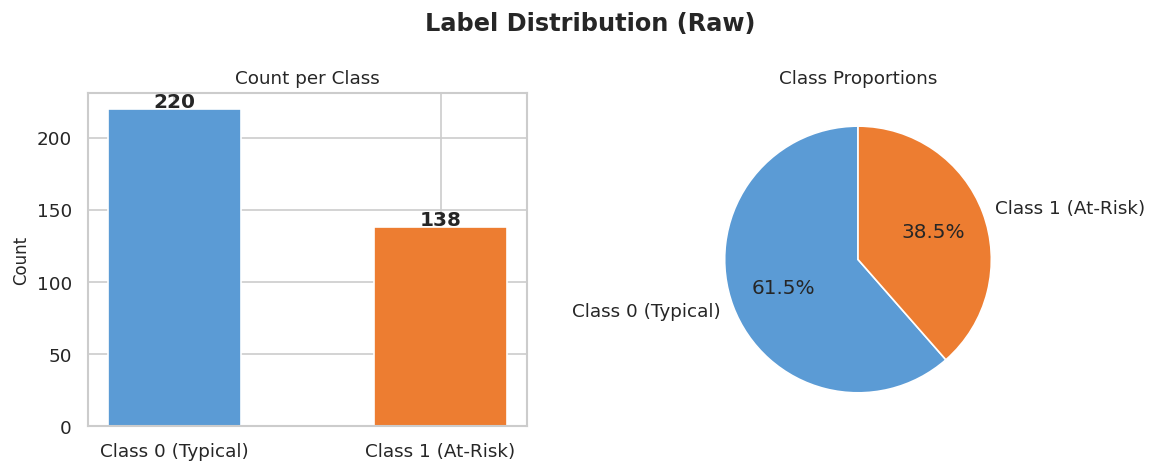

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Label Distribution (Raw)', fontweight='bold')

counts = df_raw['Label'].value_counts().sort_index()
labels = ['Class 0 (Typical)', 'Class 1 (At-Risk)']
colors = [TYPICAL_COLOR, AT_RIST_COLOR]

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Count per Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

### 1.3 Feature Distribution

To analyze the underlying distribution of the independent variables, a grid of overlapping histograms overlaid with Kernel Density Estimate (KDE) curves is generated, stratified by class. A specific technical consideration in this visualization involves the handling of the `[-99]` sentinel values: they are purposefully retained in the histograms to visually represent the scope of missing data, but are dynamically excluded from the KDE calculations to prevent significant distortion of the probability density curves. This approach ensures an accurate visual assessment of feature separability, class overlap, and the presence of distribution outliers prior to formal dataset normalization.

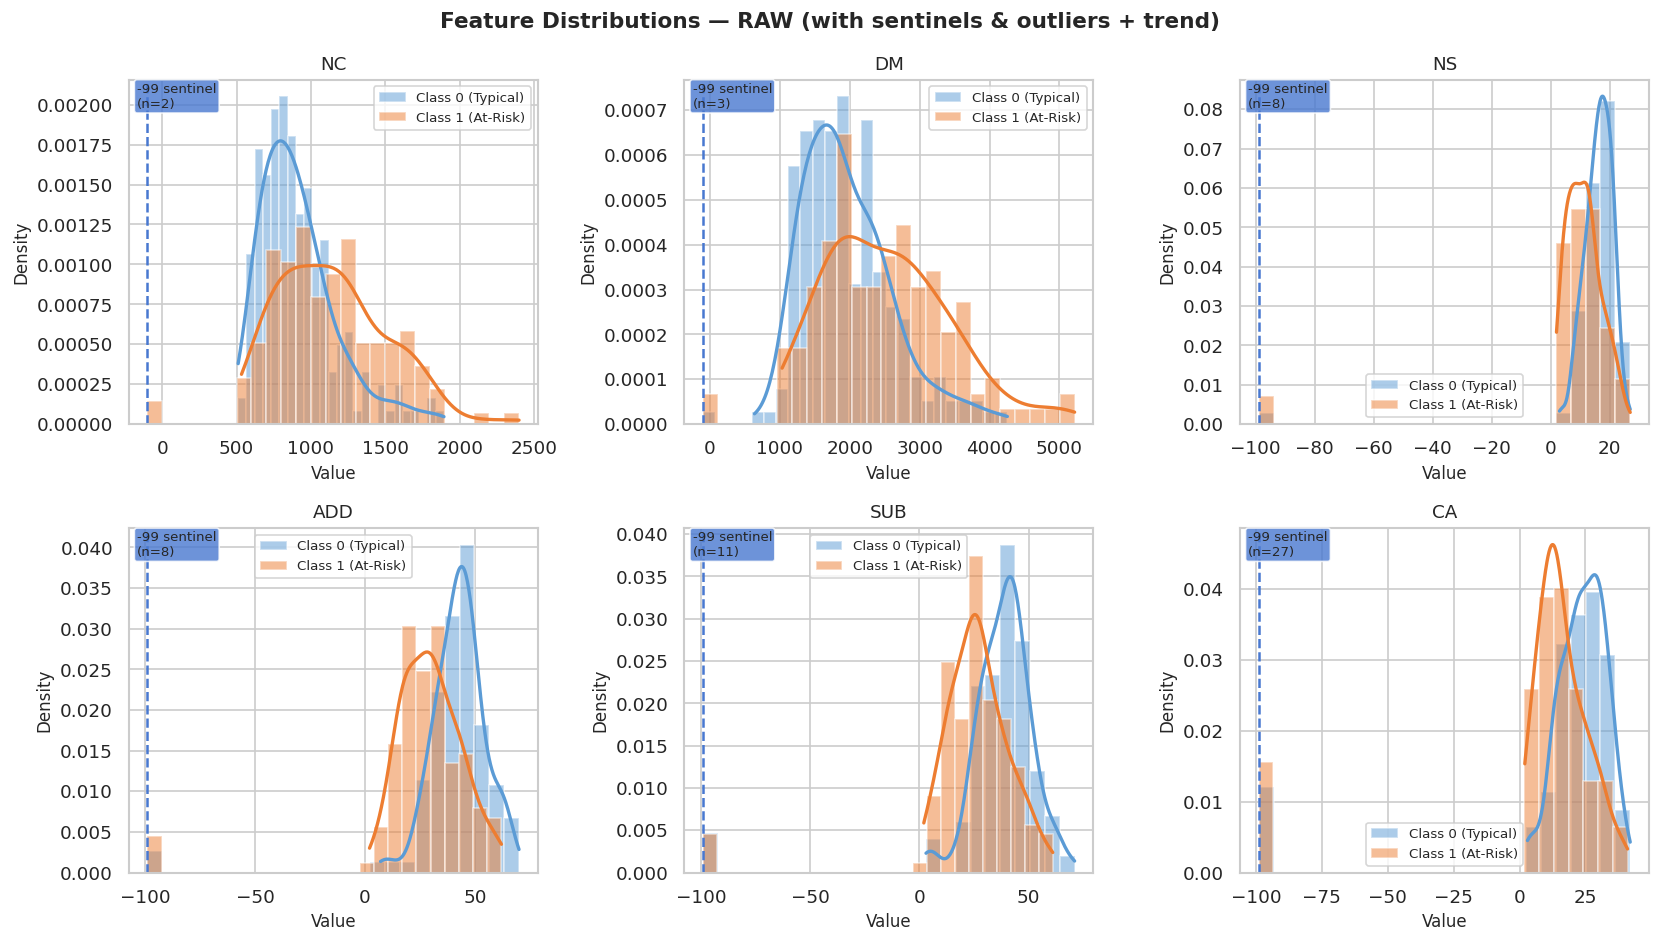

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — RAW (with sentinels & outliers + trend)', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]

    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_raw[df_raw['Label'] == label][col]

        # Histogram (keep sentinels visible)
        ax.hist(
            data, bins=25, alpha=0.5, color=color,
            label=f'Class {label} ({["Typical","At-Risk"][label]})',
            edgecolor='white', density=True
        )

        # ---- KDE trend (EXCLUDE sentinel values) ----
        # Use ~isin() to filter out all items in the list
        data_no_sentinel = data[~data.isin(DEFAULT_MISSING_VALUES)].dropna()

        if len(data_no_sentinel) > 1:
            kde = gaussian_kde(data_no_sentinel)
            x_vals = np.linspace(data_no_sentinel.min(), data_no_sentinel.max(), 200)
            y_vals = kde(x_vals)
            ax.plot(x_vals, y_vals, color=color, linewidth=2)

    # ---- Sentinel annotation + vertical line ----
    # Loop over the list of default missing values
    for idx, sentinel in enumerate(DEFAULT_MISSING_VALUES):
        n_sentinel = (df_raw[col] == sentinel).sum()
        
        if n_sentinel > 0:
            ax.axvline(sentinel, linestyle='--', linewidth=1.5)
            
            # Shift the text box down slightly if there are multiple sentinel types
            y_pos = 0.92 - (idx * 0.15)
            
            ax.annotate(
                f'{sentinel} sentinel\n(n={n_sentinel})',
                xy=(0.02, y_pos),
                xycoords='axes fraction',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', alpha=0.8)
            )

    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')  
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 1.4 Feature x Class Outliers

This section utilizes boxplots to conduct a class-stratified analysis of feature dispersion and central tendencies. By partitioning the underlying data by the target label, we can visually assess the interquartile ranges (IQR) and reliably identify extreme outliers specific to each cohort. This stratified inspection is computationally crucial: because 'At-Risk' students intrinsically exhibit atypical scoring patterns, what might appear as a severe outlier on a global scale could actually represent a valid diagnostic signal within the minority class. Understanding these class-specific variances directly informs the localized, per-class IQR clipping strategy that will be implemented during the subsequent data cleaning phase.

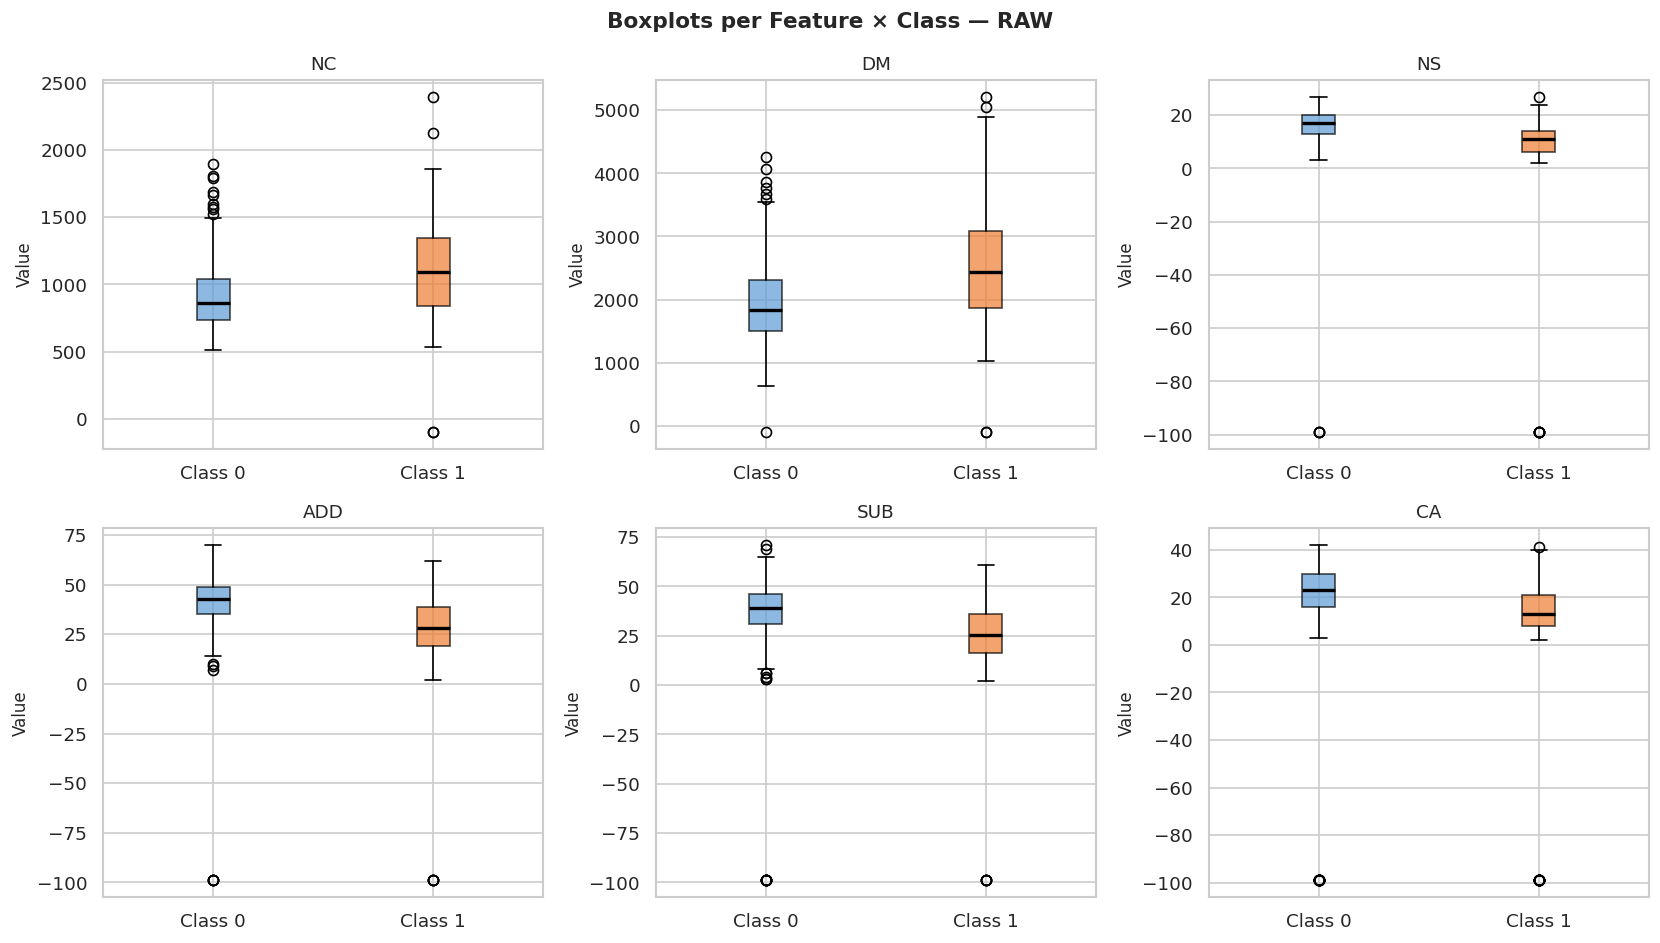

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — RAW', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    data_to_plot = [df_raw[df_raw['Label'] == lbl][col].dropna() for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix

In this section, a pairwise Pearson correlation matrix is generated to quantify the collinearity and linear relationships among the independent features. To contextualize these interactions within the dataset's domain, the matrix is visually partitioned to highlight two validated theoretical constructs: Number Processing (`NC`, `DM`) and Arithmetic Fluency (`NS`, `ADD`, `SUB`, `CA`). 

A critical technical observation during this stage of the EDA is the presence of strong negative correlations crossing between these two feature groups. While computationally this might initially suggest a data inversion error or scaling anomaly, it is absolutely structurally sound. The Number Processing variables act as efficiency indices (reaction time divided by accuracy, meaning a higher score indicates worse performance), whereas the Arithmetic Fluency variables are raw correct counts (where a higher score indicates better performance). Explicitly mapping and verifying this expected inverse relationship serves as a crucial sanity check, confirming the structural integrity of our diagnostic metrics before applying any predictive algorithms.

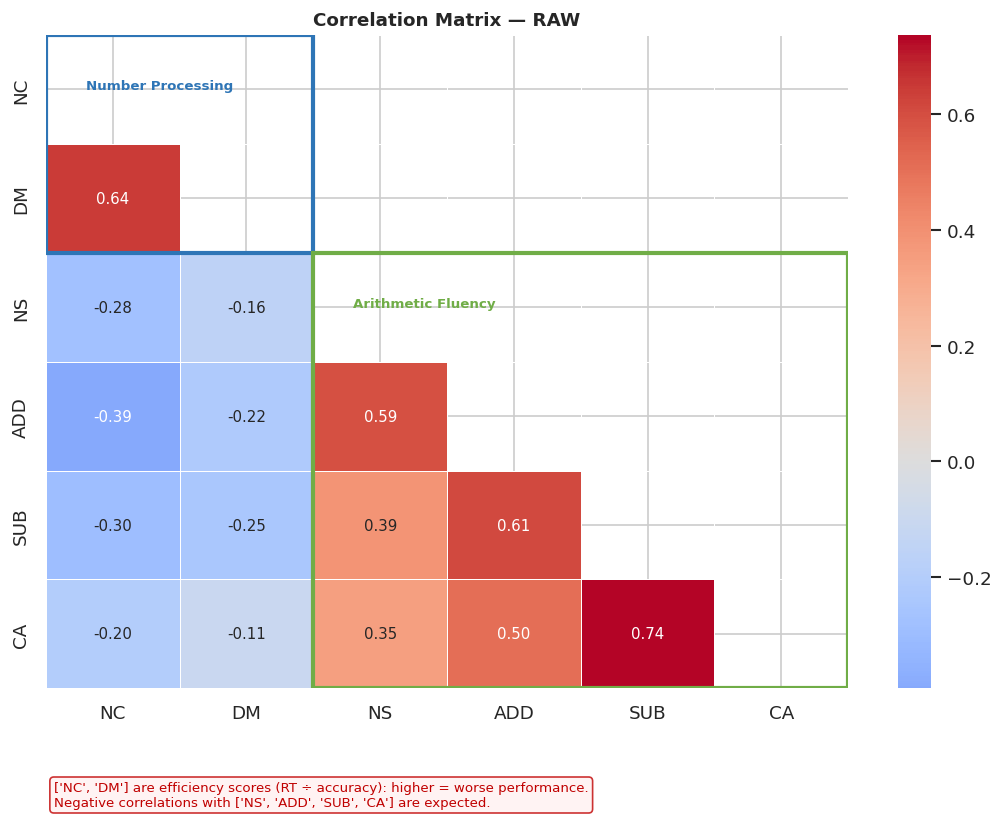

In [9]:
# Two-factor grouping
NUMBER_PROCESSING = ['NC', 'DM']
ARITHMETIC_FLUENCY = ['NS', 'ADD', 'SUB', 'CA']

# Correlation
corr_raw = df_raw[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_raw, dtype=bool))

sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — RAW', fontweight='bold')

# --- Dynamic mapping ---
col_index = {col: i for i, col in enumerate(corr_raw.columns)}

# Number Processing
np_idx = [col_index[c] for c in NUMBER_PROCESSING if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in ARITHMETIC_FLUENCY if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation ---
ax.text(
    0.01, -0.18,
    f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    f'Negative correlations with {ARITHMETIC_FLUENCY} are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 1.6 Pairplot

To further investigate the multidimensional feature space prior to dataset normalization, this cell generates a pairwise scatter plot matrix overlaid with class-specific color mappings. This visualization provides a comprehensive view of both univariate distributions—via Kernel Density Estimates on the principal diagonal—and bivariate relationships across all independent variables. 

The variables are intentionally ordered to group the Number Processing metrics (`NC`, `DM`) alongside the Arithmetic Fluency metrics (`NS`, `ADD`, `SUB`, `CA`). By organizing the grid according to this theoretical two-factor structure, we can visually validate the clustering behaviors and inverse scaling relationships identified in the correlation matrix. From a machine learning perspective, examining these 2D projections is highly valuable; it helps identify localized regions of class separability, multivariate outliers, and non-linear feature interactions that decision tree algorithms, such as C4.5, are specifically optimized to exploit.

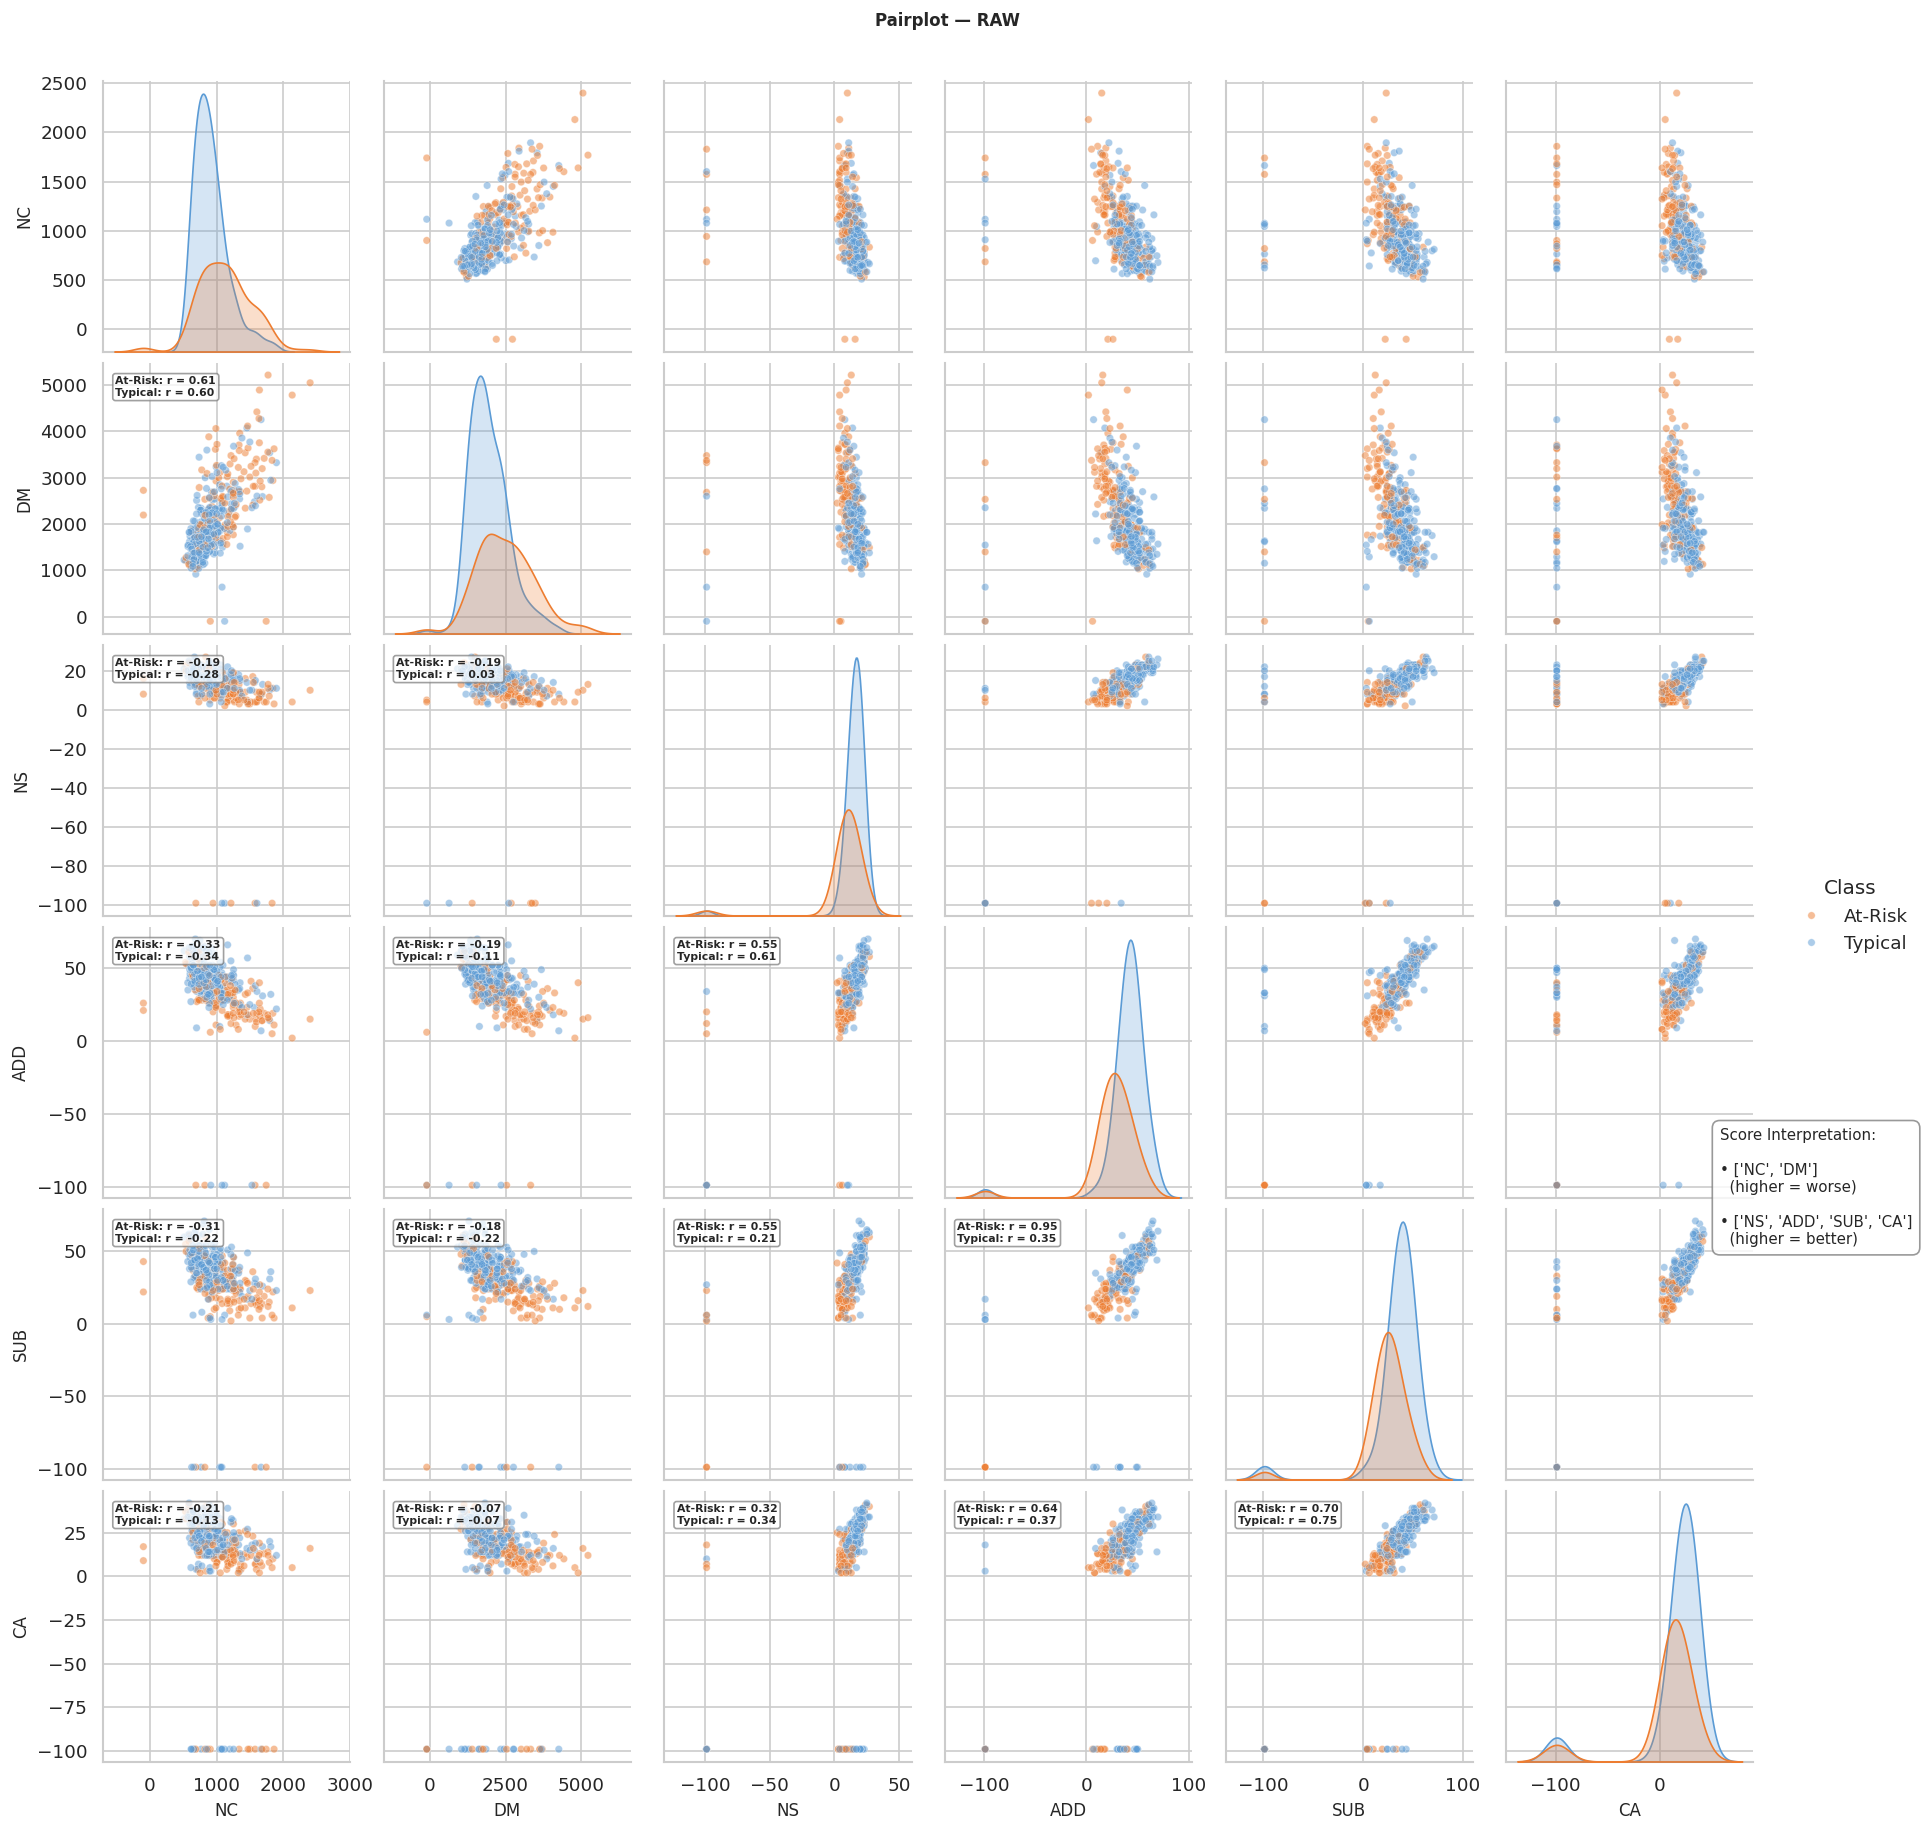

In [10]:
pair_df = df_raw.copy()
pair_df["Class"] = pair_df["Label"].map({
    0: "Typical",
    1: "At-Risk"
})

FEATURES = [*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]

g = sns.pairplot(
    pair_df,
    vars=FEATURES,
    hue="Class",
    palette={
        "Typical": TYPICAL_COLOR,
        "At-Risk": AT_RIST_COLOR
    },
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20}
)

# Add class-specific Pearson r values
add_class_specific_corr(
    g=g,
    df=pair_df,
    features=FEATURES,
    class_col="Class"
)

g.figure.suptitle(
    "Pairplot — RAW",
    y=1.02,
    fontweight="bold",
    fontsize=10
)

g.figure.text(
    0.9, 0.4,
    f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.8
    )
)

plt.show()

## 2. Cleanup Dataset

### 2.1 Replace known invalid sentinels

In [11]:
df = df_raw.copy()
df = df.replace(DEFAULT_MISSING_VALUES, np.nan)
print(f"Cells with values {DEFAULT_MISSING_VALUES} are replaced with nan")

Cells with values [-99] are replaced with nan


### 2.2 Ensure numeric safety
Since this dataset are score results, there should be no negative values.

In [12]:
for col in df.columns:
    if col == 'Label':
        continue
    df.loc[df[col] < 0, col] = np.nan

print('NaN counts after sentinel/negative removal:')
print(df[FEATURE_COLUMNS].isna().sum())

NaN counts after sentinel/negative removal:
NC      2
DM      3
NS      8
ADD     8
SUB    11
CA     27
dtype: int64


#### 2.2.1 Analyse Missingness by Class
Since missing values represent absent/incomplete students (not random), we first check whether missingness is disproportionate in the At-Risk class. If so, it is itself a diagnostic signal and must be preserved as indicator flags before imputing.

In [13]:
print("=== Missing counts per feature per class ===")
missing_by_class = df.groupby('Label')[FEATURE_COLUMNS].apply(lambda x: x.isna().sum())

# Display-friendly copy
missing_by_class_display = missing_by_class.copy()
missing_by_class_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_by_class_display)

print("\n=== Missing rate (%) per feature per class ===")
missing_rate = df.groupby('Label')[FEATURE_COLUMNS].apply(
    lambda x: (x.isna().sum() / len(x) * 100).round(1)
)

# Display-friendly copy
missing_rate_display = missing_rate.copy()
missing_rate_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_rate_display)

# ---- Keep ORIGINAL numeric index for conversion ----
missing_rate_decimal = (missing_rate / 100).round(3)


# Safe conversion to nested dict
MISSING_RATES = {
    int(label): {
        k: float(v) for k, v in row.items() if pd.notna(v)
    }
    for label, row in missing_rate_decimal.iterrows()
}

print("\nSaving missing rates...")
with open(OUTPUTS_DIR / "missing_rates.json", "w") as f:
    json.dump(MISSING_RATES, f, indent=4)

print("Done Saving.")

=== Missing counts per feature per class ===
             NC  DM  NS  ADD  SUB  CA
Typical (0)   0   1   3    4    7  15
At-Risk (1)   2   2   5    4    4  12

=== Missing rate (%) per feature per class ===
              NC   DM   NS  ADD  SUB   CA
Typical (0)  0.0  0.5  1.4  1.8  3.2  6.8
At-Risk (1)  1.4  1.4  3.6  2.9  2.9  8.7

Saving missing rates...
Done Saving.


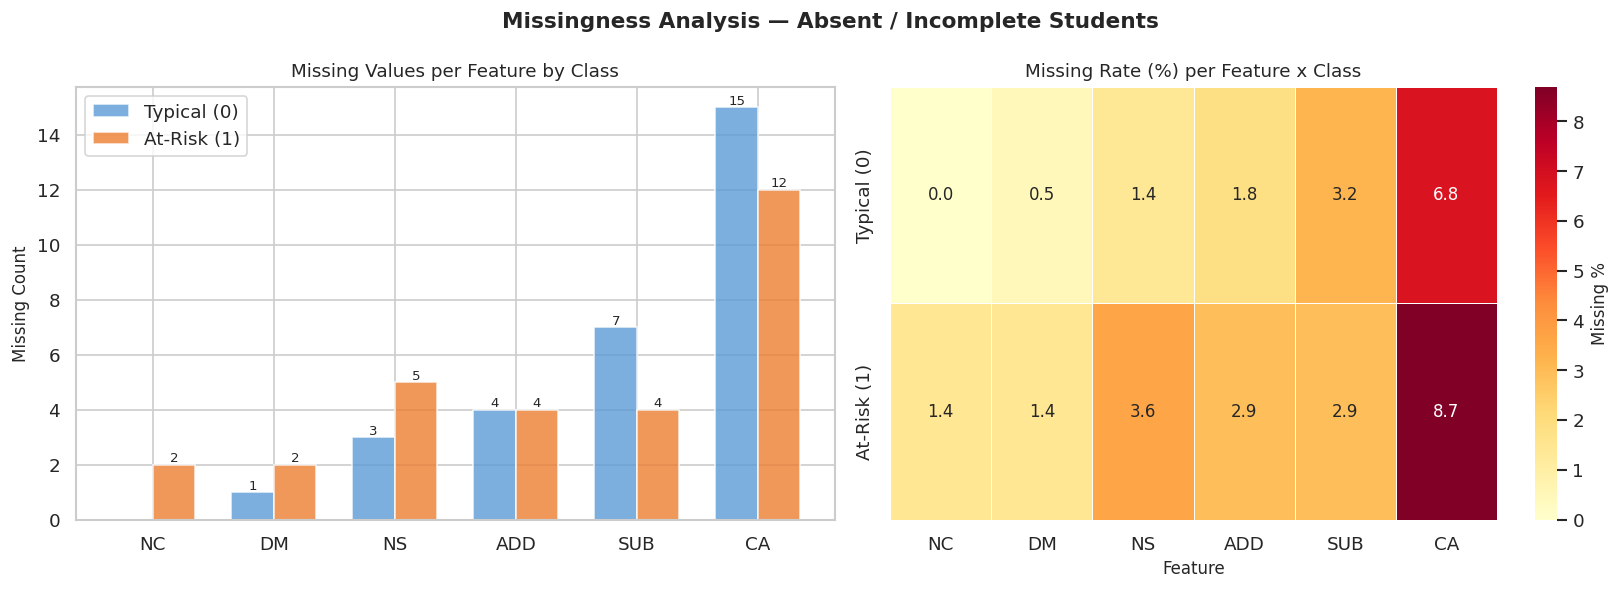


59 missing values found. Proceeding to create indicator flags.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missingness Analysis — Absent / Incomplete Students', fontweight='bold', fontsize=13)

# Chart 1: Missing count per feature, grouped by class
ax = axes[0]
miss_c0 = df[df['Label'] == 0][FEATURE_COLUMNS].isna().sum()
miss_c1 = df[df['Label'] == 1][FEATURE_COLUMNS].isna().sum()
x = np.arange(len(FEATURE_COLUMNS))
width = 0.35
ax.bar(x - width/2, miss_c0, width, label='Typical (0)', color=TYPICAL_COLOR, alpha=0.8)
ax.bar(x + width/2, miss_c1, width, label='At-Risk (1)',     color=AT_RIST_COLOR, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values per Feature by Class')
ax.legend()
for xi, (v0, v1) in enumerate(zip(miss_c0, miss_c1)):
    if v0 > 0: ax.text(xi - width/2, v0 + 0.1, str(v0), ha='center', fontsize=8)
    if v1 > 0: ax.text(xi + width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)

# Chart 2: Missing rate heatmap
ax2 = axes[1]
rate_data = pd.DataFrame({
    'Typical (0)': (df[df['Label']==0][FEATURE_COLUMNS].isna().sum() / (df['Label']==0).sum() * 100),
    'At-Risk (1)':     (df[df['Label']==1][FEATURE_COLUMNS].isna().sum() / (df['Label']==1).sum() * 100)
}).T
sns.heatmap(rate_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Missing %'}, annot_kws={'size': 10})
ax2.set_title('Missing Rate (%) per Feature x Class')
ax2.set_xlabel('Feature')

plt.tight_layout()
plt.show()

total_miss = df[FEATURE_COLUMNS].isna().sum().sum()
if total_miss == 0:
    print("\nNo missing values found — missingness flags will be all-zero.")
else:
    print(f"\n{total_miss} missing values found. Proceeding to create indicator flags.")

#### 2.2.2 Create Missingness Indicator Flags
For each feature with any missing values, we add a binary `{feature}_incomplete` flag (1 = absent/did not finish, 0 = completed). These flags preserve the absence signal before it is overwritten by imputation.

In [15]:
if total_miss > 0:
    flag_cols = []
    for col in FEATURE_COLUMNS:
        missing_mask = df[col].isna()
        if missing_mask.sum() > 0:
            flag_name = f'{col}_incomplete'
            df[flag_name] = missing_mask.astype(int)
            flag_cols.append(flag_name)
            print(f'  Created: {flag_name}  ({missing_mask.sum()} students flagged)')

    # Calculate students with any missing features dynamically
    any_missing_mask = df[FEATURE_COLUMNS].isna().any(axis=1)

    print(f'\nStudents with any incompleteness: {any_missing_mask.sum()}')
    print(f'  Typical: {any_missing_mask[df["Label"]==0].sum()}')
    print(f'  At-Risk:     {any_missing_mask[df["Label"]==1].sum()}')
    print(f'\nFlag columns added: {flag_cols}')

  Created: NC_incomplete  (2 students flagged)
  Created: DM_incomplete  (3 students flagged)
  Created: NS_incomplete  (8 students flagged)
  Created: ADD_incomplete  (8 students flagged)
  Created: SUB_incomplete  (11 students flagged)
  Created: CA_incomplete  (27 students flagged)

Students with any incompleteness: 35
  Typical: 18
  At-Risk:     17

Flag columns added: ['NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete']


#### 2.2.3 Count the missingness indicator flags per label

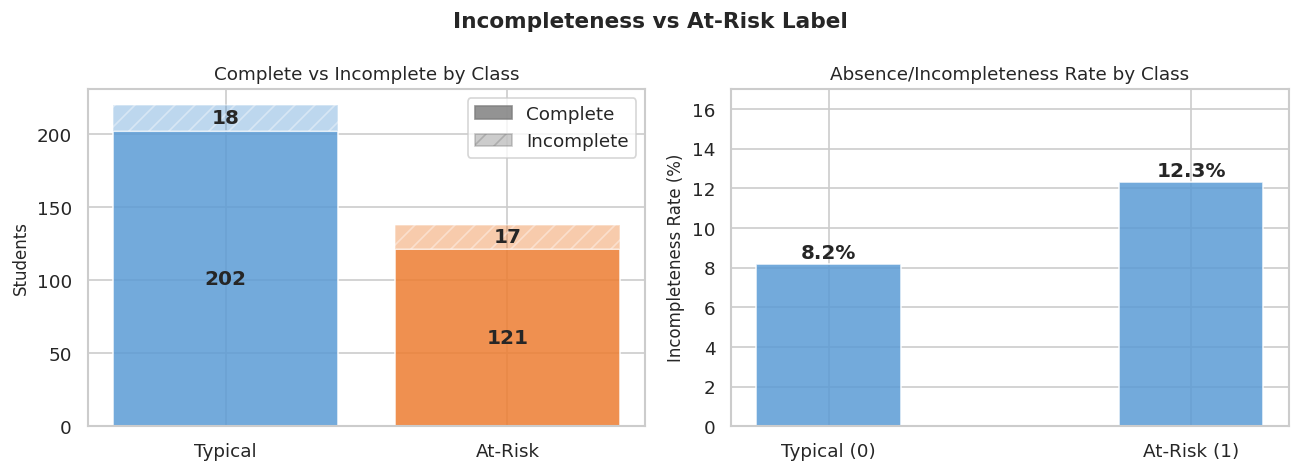

In [16]:
if any_missing_mask.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Incompleteness vs At-Risk Label', fontweight='bold', fontsize=13)

    # Stacked bar: incomplete vs complete per class
    ax = axes[0]
    for lbl, color, name in [(0,TYPICAL_COLOR,'Typical'),(1,AT_RIST_COLOR,'At-Risk')]:
        class_mask = df['Label'] == lbl
        
        # Use our dynamically created mask instead of df['any_incomplete']
        n_inc  = any_missing_mask[class_mask].sum()
        n_comp = class_mask.sum() - n_inc
        
        ax.bar(name, n_comp, color=color, alpha=0.85)
        ax.bar(name, n_inc,  bottom=n_comp, color=color, alpha=0.4, hatch='//')
        
        # Label the complete count (centered in the bottom bar)
        if n_comp > 0:
            ax.text(name, n_comp / 2, str(n_comp), ha='center', va='center', fontweight='bold')
            
        # Label the incomplete count (centered in the top hatched bar)
        if n_inc > 0:
            ax.text(name, n_comp + (n_inc / 2), str(n_inc), ha='center', va='center', fontweight='bold')
        
    ax.set_ylabel('Students')
    ax.set_title('Complete vs Incomplete by Class')
    handles = [
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.85, label='Complete'),
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.4, hatch='//', label='Incomplete')
    ]
    ax.legend(handles=handles)

    # Incompleteness rate per class
    ax2 = axes[1]
    rates = [
        any_missing_mask[df['Label']==0].mean() * 100,
        any_missing_mask[df['Label']==1].mean() * 100
    ]
    bars = ax2.bar(['Typical (0)', 'At-Risk (1)'], rates,
                   color=[TYPICAL_COLOR,TYPICAL_COLOR], alpha=0.85, width=0.4)
    ax2.set_ylabel('Incompleteness Rate (%)')
    ax2.set_title('Absence/Incompleteness Rate by Class')
    ax2.set_ylim(0, max(rates)*1.3 + 1)
    for bar, rate in zip(bars, rates):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('No missing values in dataset — incompleteness chart skipped.')

### 2.3 Impute NaNs with Per-Class Median 

With the informative absence signals successfully preserved as binary flags, the raw dataset must now be numerically complete before subsequent modeling stages can proceed. Imputation is performed using the median rather than the mean to ensure robustness against the severe outliers identified during the univariate analysis. Crucially, this imputation is executed dynamically on a **per-class basis** (group-aware). 

Since 'At-Risk' students intrinsically exhibit fundamentally different scoring distributions and central tendencies compared to their 'Typical' peers, applying a global dataset median would artifactually force missing 'At-Risk' data points toward the typical baseline, destroying the diagnostic signal. By stratifying the imputation by the target label, we ensure that the imputed values accurately reflect the localized statistical reality of the student's respective cohort. In-Group. If an entire feature column for a specific class happens to be missing (NaN), a global fallback median is applied to prevent execution errors.

In [17]:
df[FEATURE_COLUMNS] = df.groupby('Label')[FEATURE_COLUMNS].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: global median if an entire class column is NaN
df = df.fillna(df.median(numeric_only=True))

### 2.4 Per-Class IQR Clipping
Clipping is done within each class separately. At-Risk students may have genuinely different score ranges — clipping globally would corrupt that signal.

In [18]:
clip_bounds = {}
for col in FEATURE_COLUMNS:
    clip_bounds[col] = {}
    for label in df['Label'].unique():
        mask = df['Label'] == label
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clip_bounds[col][label] = (lower, upper)
        df.loc[mask, col] = df.loc[mask, col].clip(lower, upper)

df = df.reset_index(drop=True)      # Sanity Check

print('Per-class clipping bounds applied:')
for col, bounds in clip_bounds.items():
    for label, (lo, hi) in bounds.items():
        name = 'Typical' if label == 0 else 'At-Risk'
        print(f'  {col} [{name}]: [{lo:.2f}, {hi:.2f}]')

Per-class clipping bounds applied:
  NC [At-Risk]: [162.37, 2050.36]
  NC [Typical]: [271.50, 1503.74]
  DM [At-Risk]: [68.71, 4902.44]
  DM [Typical]: [271.80, 3541.94]
  NS [At-Risk]: [-3.50, 24.50]
  NS [Typical]: [2.50, 30.50]
  ADD [At-Risk]: [-10.00, 68.00]
  ADD [Typical]: [16.50, 68.50]
  SUB [At-Risk]: [-11.50, 64.50]
  SUB [Typical]: [8.50, 68.50]
  CA [At-Risk]: [-5.88, 37.12]
  CA [Typical]: [1.88, 46.88]


## 3. Exploratory Data Analysis — After Cleaning

### 3.1 Cleaned Dataset View

In [19]:
df_clean = df.copy()

print("=== Dataset Info ===")
print(df_clean.info())

print("\n=== Dataset Head ===")
print(df_clean.head())

print("\n=== Summary Statistics (raw) ===")
print(df_clean.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
sentinel_mask = df_clean.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_clean['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NC              358 non-null    float64
 1   DM              358 non-null    float64
 2   NS              358 non-null    float64
 3   ADD             358 non-null    float64
 4   SUB             358 non-null    float64
 5   CA              358 non-null    float64
 6   Label           358 non-null    int64  
 7   NC_incomplete   358 non-null    int64  
 8   DM_incomplete   358 non-null    int64  
 9   NS_incomplete   358 non-null    int64  
 10  ADD_incomplete  358 non-null    int64  
 11  SUB_incomplete  358 non-null    int64  
 12  CA_incomplete   358 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 36.5 KB
None

=== Dataset Head ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \
0  1248.000000  2903.384615   5.0  23.0  17.

### 3.2 Feature Distribution

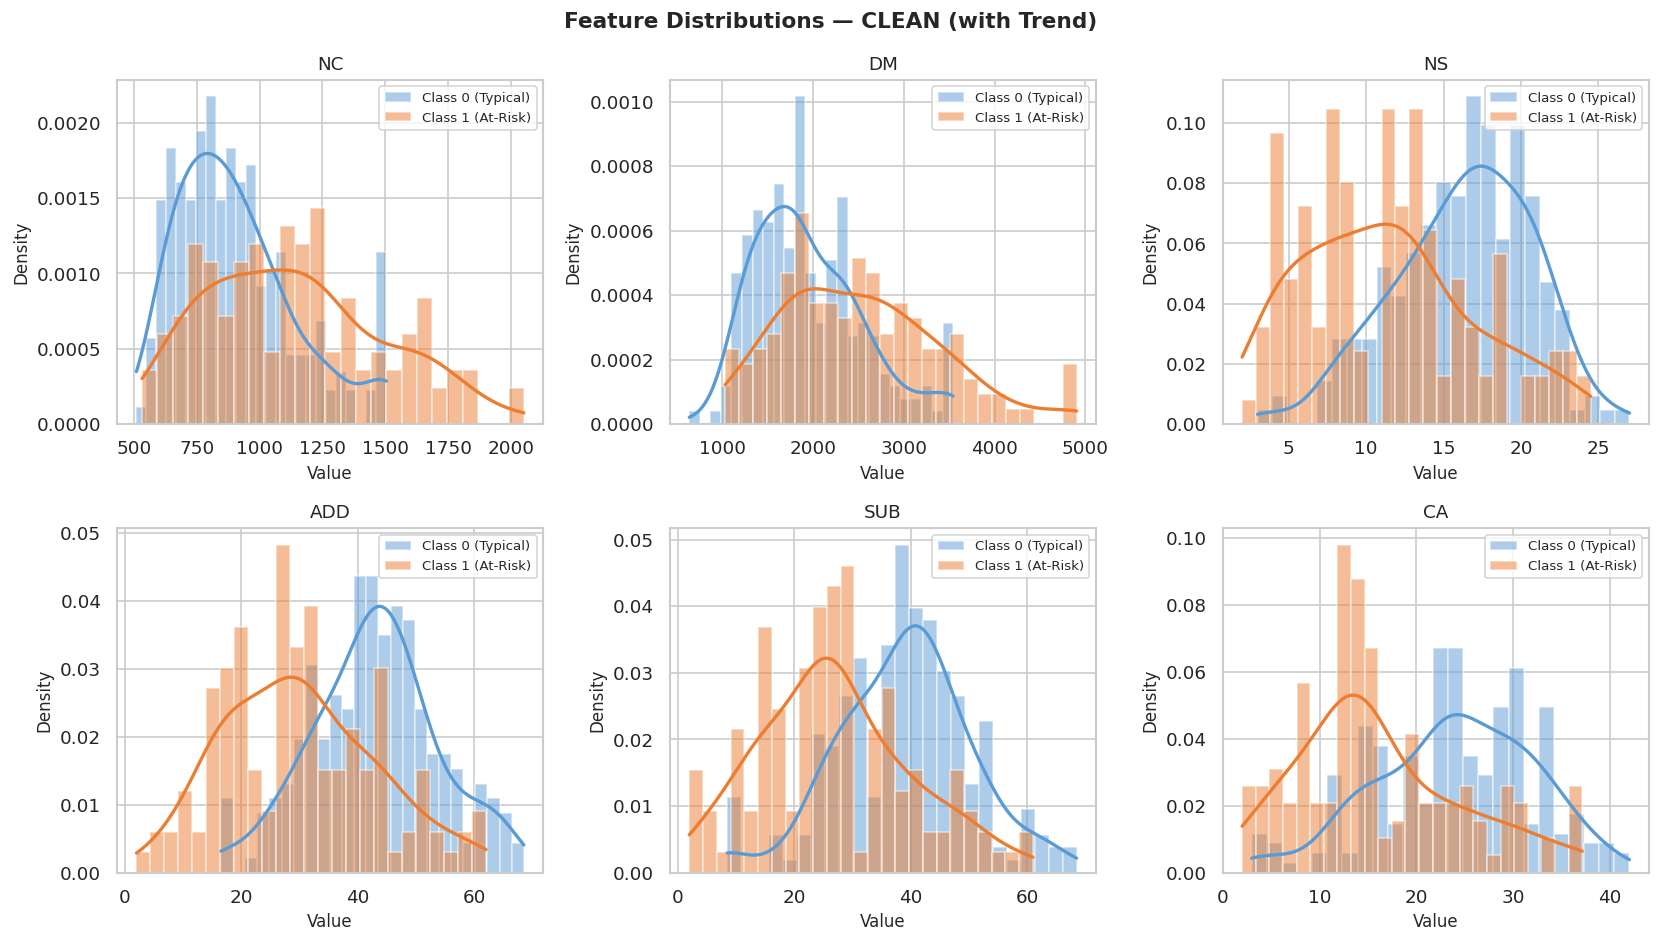

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — CLEAN (with Trend)', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]

    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_clean[df_clean['Label'] == label][col].dropna()

        ax.hist(
            data, bins=25, alpha=0.5, color=color,
            label=f'Class {label} ({["Typical","At-Risk"][label]})',
            edgecolor='white', density=True  # <-- important for overlay
        )

        if len(data) > 1:
            from scipy.stats import gaussian_kde

            kde = gaussian_kde(data)
            x_vals = np.linspace(data.min(), data.max(), 200)
            y_vals = kde(x_vals)

            ax.plot(x_vals, y_vals, color=color, linewidth=2)

    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')  # changed from Frequency
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Feature x Class Outliers

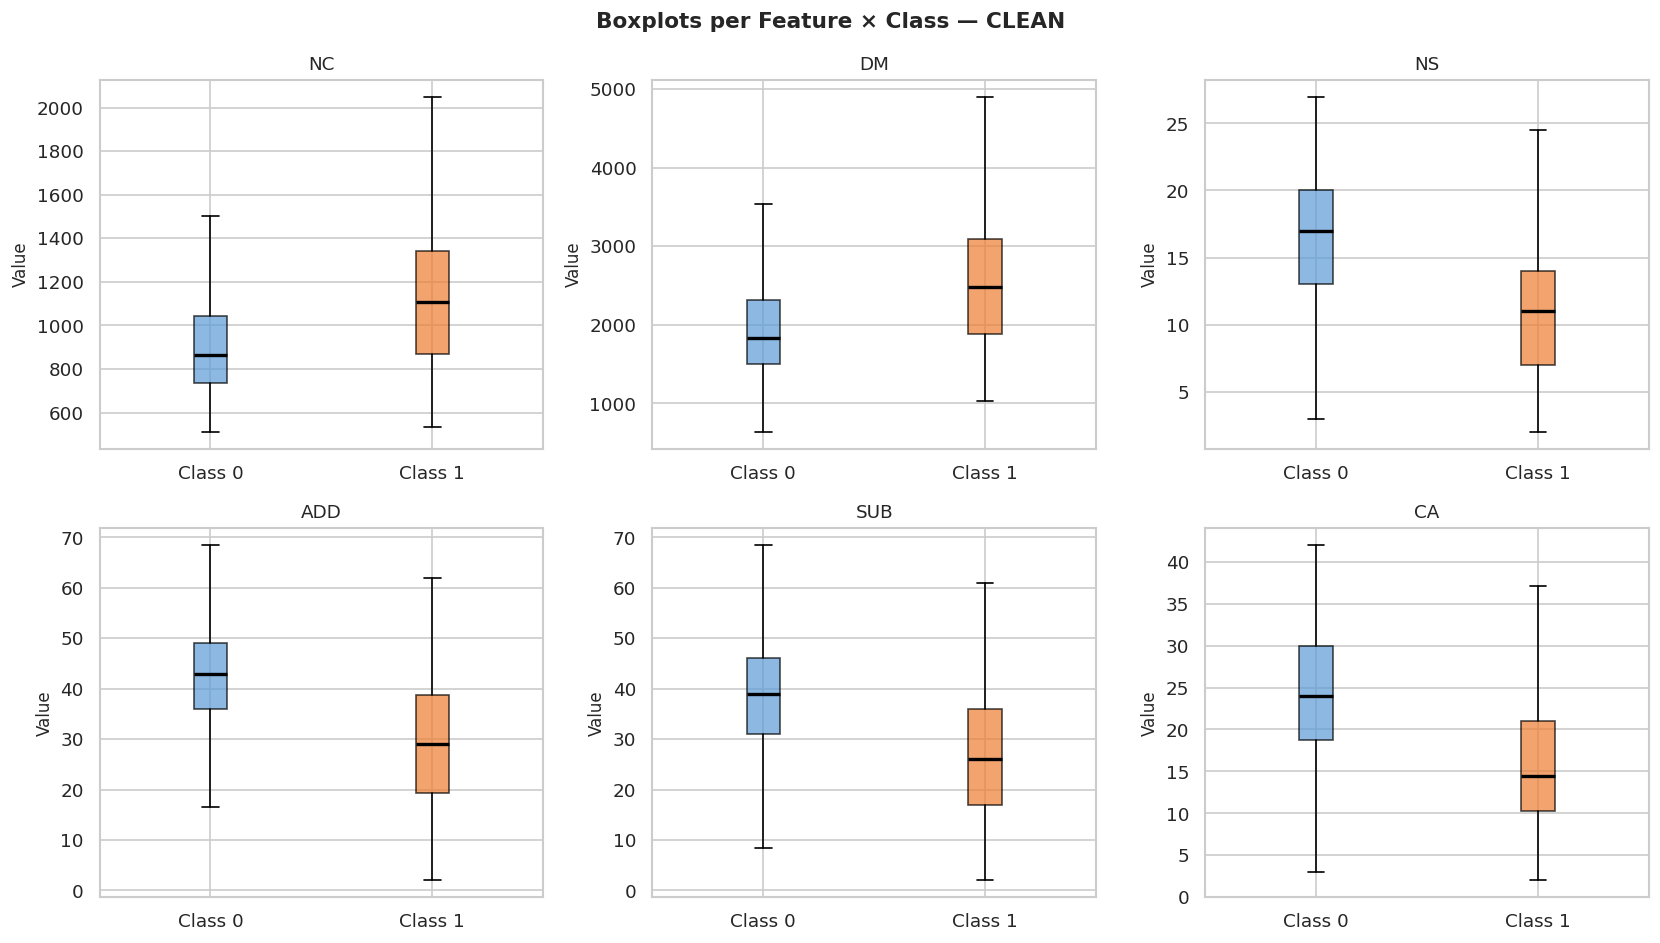

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — CLEAN', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    data_to_plot = [df_clean[df_clean['Label'] == lbl][col] for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

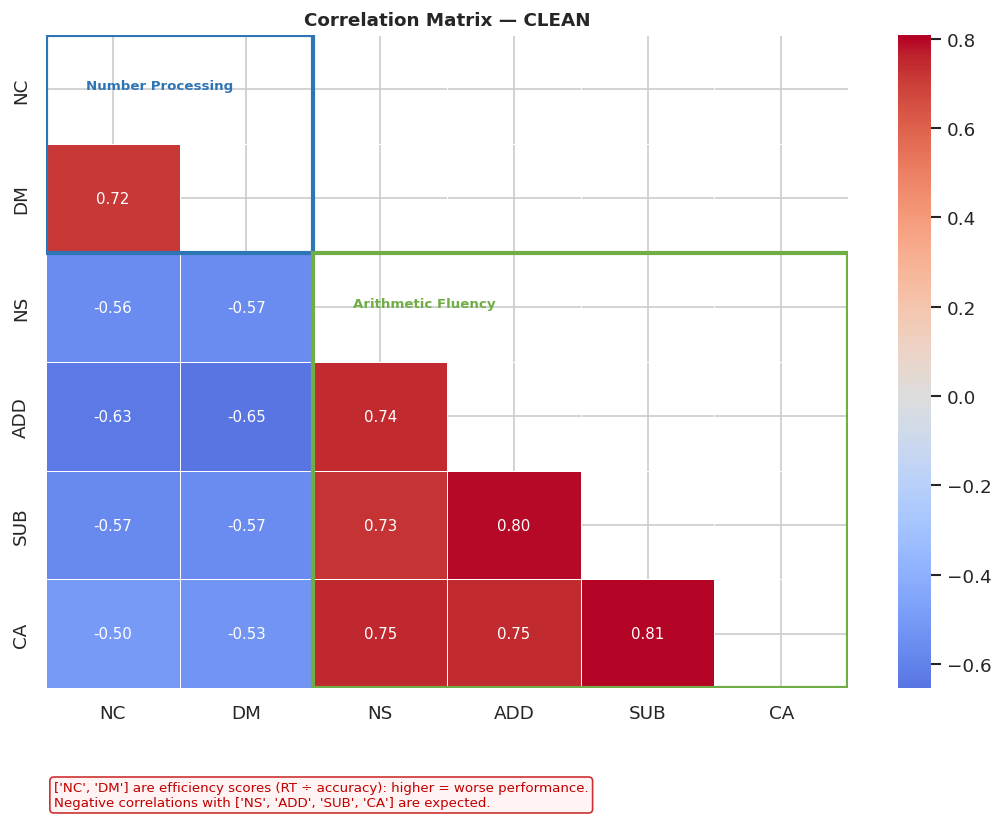

In [22]:
# Correlation
corr_clean = df_clean[[*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_clean, dtype=bool))

sns.heatmap(corr_clean, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — CLEAN', fontweight='bold')

# --- Dynamic mapping ---
col_index = {col: i for i, col in enumerate(corr_clean.columns)}

# Number Processing
np_idx = [col_index[c] for c in NUMBER_PROCESSING if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in ARITHMETIC_FLUENCY if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation ---
ax.text(
    0.01, -0.18,
    f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    f'Negative correlations with {ARITHMETIC_FLUENCY} are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 3.4 Pairplot 

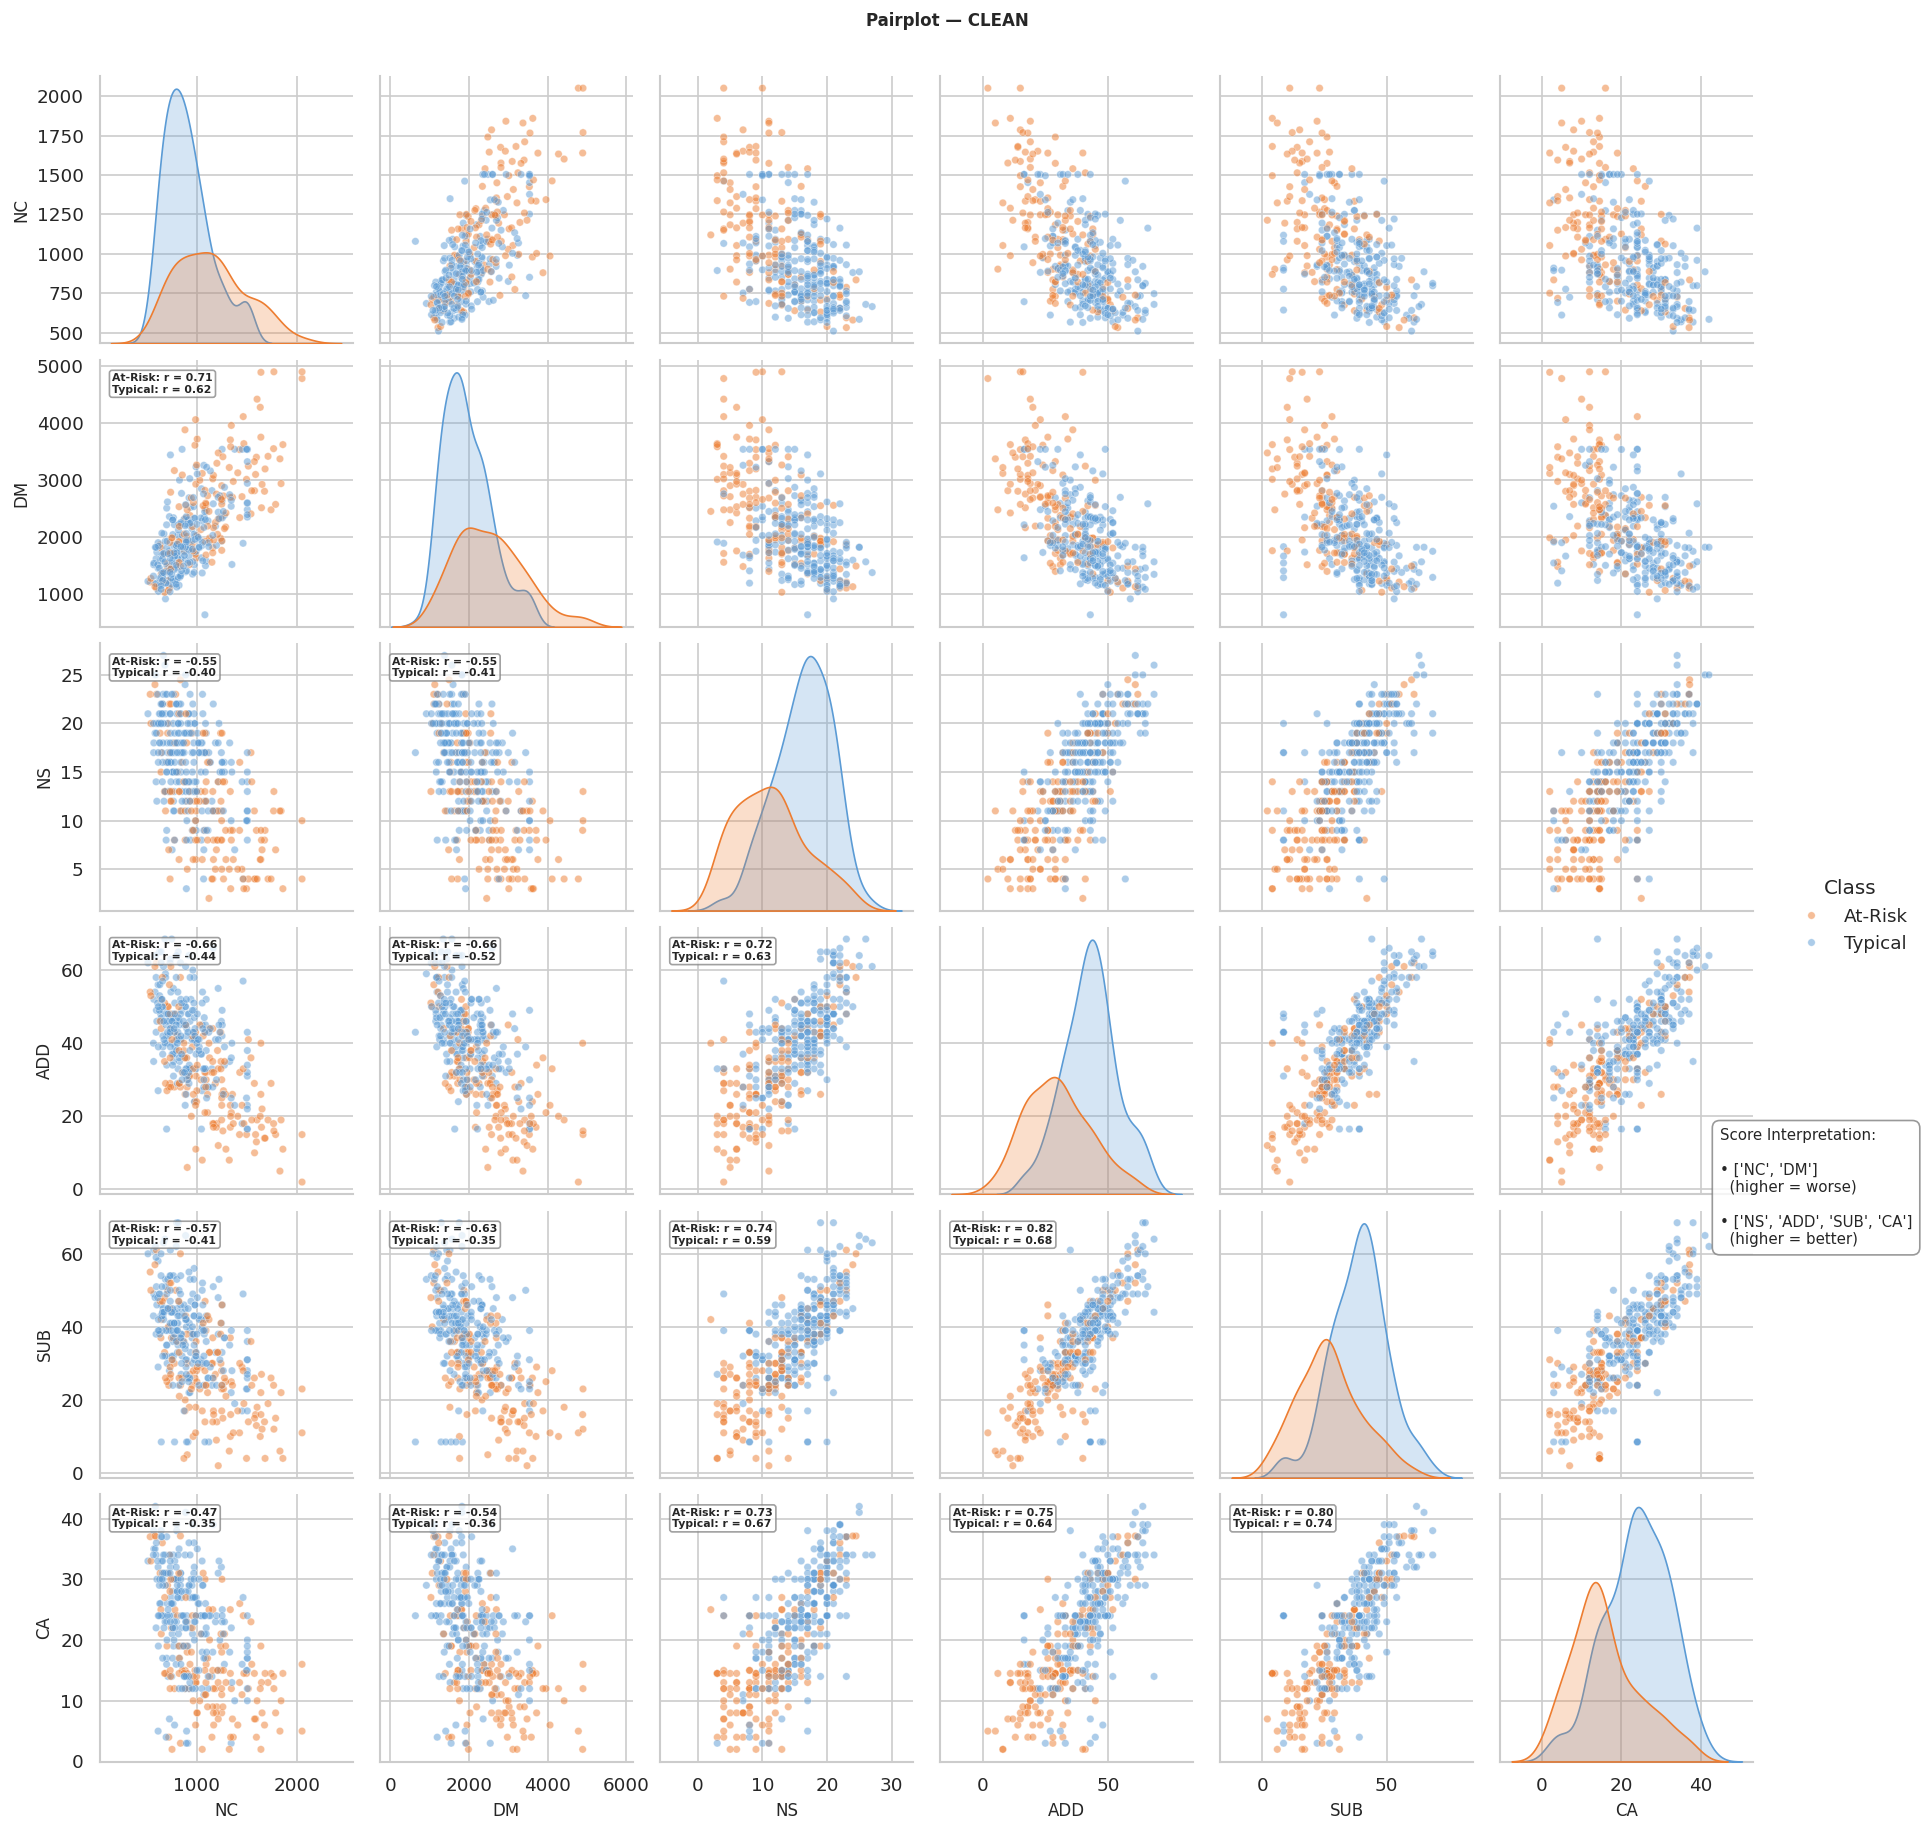

In [23]:
pair_df_c = df_clean.copy()
pair_df_c["Class"] = pair_df_c["Label"].map({
    0: "Typical",
    1: "At-Risk"
})

FEATURES = [*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]

g = sns.pairplot(
    pair_df_c,
    vars=FEATURES,
    hue="Class",
    palette={
        "Typical": TYPICAL_COLOR,
        "At-Risk": AT_RIST_COLOR
    },
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20}
)

# Add class-specific Pearson r values
add_class_specific_corr(
    g=g,
    df=pair_df_c,
    features=FEATURES,
    class_col="Class"
)

g.figure.suptitle(
    "Pairplot — CLEAN",
    y=1.02,
    fontweight="bold",
    fontsize=10
)

g.figure.text(
    0.9, 0.4,
    f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.8
    )
)

plt.show()

## 4. Before vs After Comparison

### 4.1 Numeric Comparison

In [24]:
# Numeric comparison table: mean, std, min, max for each feature
rows = []
for col in FEATURE_COLUMNS:
    for label, dataset in [('RAW', df_raw), ('CLEAN', df_clean)]:
        s = dataset[col]
        rows.append({
            'Feature': col, 'Dataset': label,
            'Mean': s.mean(), 'Std': s.std(),
            'Min': s.min(), 'Max': s.max(),
            'NaN': s.isna().sum()
        })

comparison = pd.DataFrame(rows).set_index(['Feature', 'Dataset']).round(2)
print(comparison.to_string())

                    Mean     Std     Min      Max  NaN
Feature Dataset                                       
NC      RAW       993.86  329.90  -99.00  2399.14    0
        CLEAN     994.96  305.99  510.82  2050.36    0
DM      RAW      2158.84  813.41  -99.00  5217.22    0
        CLEAN    2171.81  770.70  637.50  4902.44    0
NS      RAW        11.88   17.64  -99.00    27.00    0
        CLEAN      14.38    5.44    2.00    27.00    0
ADD     RAW        34.87   24.30  -99.00    70.00    0
        CLEAN      37.96   13.30    2.00    68.50    0
SUB     RAW        30.18   26.66  -99.00    71.00    0
        CLEAN      34.32   13.34    2.00    68.50    0
CA      RAW        12.00   33.01  -99.00    42.00    0
        CLEAN      20.94    9.12    2.00    42.00    0


## 5. Save Cleaned Dataset

In [25]:
df_clean.to_csv(DATASETS_DIR / 'cleaned_dataset.csv', index=False)

# D & E. GAN-Based Synthetic Data Generation and Statistical Validation
These sections cover the use of CopulaGAN and CTGAN to synthetically augment the minority 'At-Risk' class within the strict confines of the training split, and the statistical validation of the resulting samples.


# Synthetic Minority Oversampling — CopulaGAN + CTGAN


**Strategy:** GANs are trained strictly on the training minority class to prevent data leakage. Synthetic samples are injected **exclusively into the training split** — validation and test remain 100% real.

**Post-processing pipeline:**
1. Train CopulaGAN + CTGAN on raw features + BC (derived) so the model learns the ADD/SUB/CA joint structure.
2. Quantile-match each feature marginal on the full candidate pool.
3. KNN filter — retain the top 90th-percentile candidates closest to the real minority set.
4. Uniform sample to the required count (avoids centroid bias).
5. Hard assert: selected set must pass all distribution checks before proceeding.
6. Recompute all derived features deterministically from raw features.


## 1. Imports & Configuration

This section establishes the computational environment by importing requisite libraries for data manipulation (`pandas`, `numpy`), statistical analysis (`scipy`), plotting (`matplotlib`, `seaborn`), and synthetic data generation (`sdv`). Global constants, including feature sets (raw, GAN, and derived) and directory paths, are defined to maintain consistency across the generation pipeline.

In [ ]:
import pandas as pd
import numpy as np
import random, os, warnings
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import json
from scipy.stats import gaussian_kde
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sdv.single_table import CopulaGANSynthesizer, CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from pathlib import Path

warnings.filterwarnings('ignore')

# Set Seed for reproducability
SEED = 42

EPSILON = 1e-9
RAW_FEATURES = ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
GAN_FEATURES = RAW_FEATURES + ['BC']   # BC included so GAN learns ADD/SUB/CA joint
DERIVED_FEATURES = ['NP', 'SN', 'AF', 'BC', 'AS', 'PF']
ROOT_DIR = Path('..')
DATASETS_DIR = ROOT_DIR / 'datasets' / 'processed'
OUTPUTS_DIR = ROOT_DIR / 'outputs' / 'logs_and_metrics'

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'
REAL_COLOR = '#54A24B'
SYNTHETIC_COLOR = '#E45756'

# Real Train Data only (both labels 0 and 1)
print('Configuration loaded.')
print(f'  RAW_FEATURES : {RAW_FEATURES}')
print(f'  GAN_FEATURES : {GAN_FEATURES}')


Configuration loaded.
  RAW_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA']
  GAN_FEATURES : ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'BC']


### 1.1 Missing Rates Import from EDA

To preserve the structural integrity of the "absent student" signals identified during the exploratory data analysis, empirical missing rates must be explicitly imported from our output artifacts. Generating synthetic records that strictly reflect the same missing data distributions as the real 'At-Risk' cohort is an essential methodological requirement for maintaining diagnostic validity in the subsequent model.

In [27]:
# Load empirical missing rates from file (per label, per feature).
MISSING_RATES = {}
try:
    with open(OUTPUTS_DIR / 'missing_rates.json', encoding='utf-8') as file:
        loaded_rates = json.load(file)

    # Normalize label keys to strings so downstream lookup is consistent.
    MISSING_RATES = {str(k): v for k, v in loaded_rates.items()}

    # Validate expected schema: labels -> RAW_FEATURES -> numeric rates in [0, 1].
    for lbl in ['0', '1']:
        if lbl not in MISSING_RATES:
            raise ValueError(f"Missing label key '{lbl}' in {OUTPUTS_DIR / 'missing_rates.json'}")
        for f in RAW_FEATURES:
            if f not in MISSING_RATES[lbl]:
                raise ValueError(f"Missing feature '{f}' under label '{lbl}' in missing_rates.json")
            MISSING_RATES[lbl][f] = float(np.clip(MISSING_RATES[lbl][f], 0.0, 1.0))

    print(f"{MISSING_RATES=}")
except FileNotFoundError:
    print(f"File not found: {OUTPUTS_DIR / 'missing_rates.json'}")
except json.JSONDecodeError:
    print(f"Invalid JSON format: {OUTPUTS_DIR / 'missing_rates.json'}")
except ValueError as err:
    print(f"Invalid missing-rate schema: {err}")

MISSING_RATES={'0': {'NC': 0.0, 'DM': 0.005, 'NS': 0.014, 'ADD': 0.018, 'SUB': 0.032, 'CA': 0.068}, '1': {'NC': 0.014, 'DM': 0.014, 'NS': 0.036, 'ADD': 0.029, 'SUB': 0.029, 'CA': 0.087}}


## 2. Helper Functions

A suite of deterministic utility functions is defined to enforce reproducibility, perform exact feature derivations, inject empirical missingness rates, and rigorously validate the statistical distributions of the synthesized data against the real minority cohort.

### 2.1 Set Seed Function

To guarantee exact reproducibility of stochastic processes—including GAN initialization, sampling, and KNN filtering—this function uniformly fixes the random seeds across the OS, Python, NumPy, and PyTorch environments.

In [28]:
def set_seed(seed):
    """Global seed for full reproducibility."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

print("set_seed helper function loaded.")

set_seed helper function loaded.


### 2.2 Compute Derived Features

This function deterministically computes derived diagnostic metrics (e.g., Number Processing, Spatial Number, Arithmetic Facts) from the base clinical features according to the established equations. This ensures the foundational covariance structures are perfectly maintained.

In [29]:
def compute_derived(df: pd.DataFrame) -> pd.DataFrame:
    """Recompute all derived features from raw features deterministically."""
    df_der = df.copy()
    df_der['NP'] = (df_der['NC'] + df_der['DM']) / 2                           # Eq. 3.3
    df_der['SN'] = df_der['NC'] - df_der['DM']                                  # Eq. 3.4
    df_der['AF'] = (df_der['NS'] + df_der['ADD'] + df_der['SUB'] + df_der['CA']) / 4   # Eq. 3.5
    df_der['BC'] = (df_der['ADD'] + df_der['SUB']) / 2 - df_der['CA']              # Eq. 3.6
    df_der['AS'] = df_der['ADD'] - df_der['SUB']                                # Eq. 3.7
    df_der['PF'] = df_der['AF'] / (df_der['NP'] + EPSILON)                     # Eq. 3.8
    return df_der

print("compute_derived helper function loaded.")

compute_derived helper function loaded.


### 2.3 Inject Missing Flags and Median Imputation

To preserve the critical "absent-student" diagnostic signal, this function simulates data sparsity in the synthetic records. It precisely mirrors the empirical missing-data distributions of the real 'At-Risk' cohort via pseudo-random binomial masking, subsequently applying median imputation to align with the preprocessing pipeline.

In [30]:
def inject_synthetic_missing(df: pd.DataFrame, missing_rates: dict,
                               features: list, df_min_ref: pd.DataFrame,
                               label_val: int = 1,
                               random_state: int = SEED) -> pd.DataFrame:
    """
    Simulate missing data in SYNTHETIC rows:
      1. Mark rows as missing per empirical rates.
      2. Impute with real minority-class median.
      3. Set <feature>_incomplete = 1.
    """
    print("\nGenerating synthetic incomplete flags...")
    rng = np.random.default_rng(random_state)
    df_der = df.copy()

    # Support both integer and string label keys (e.g., 1 and '1').
    rates = missing_rates.get(str(label_val), missing_rates.get(label_val, {}))

    feature_medians = {f: df_min_ref[f].median() for f in features}
    inc_cols = []
    for f in features:
        col = f + '_incomplete'
        inc_cols.append(col)
        df_der[col] = 0
        rate = float(np.clip(rates.get(f, 0.0), 0.0, 1.0))
        if rate <= 0.0:
            continue
        mask = rng.binomial(1, rate, size=len(df)).astype(bool)
        if mask.sum() == 0:
            continue
        df_der.loc[mask, f] = feature_medians[f]
        df_der.loc[mask, col] = 1
    print("Finished generating synthetic flags.")
    return df_der


print("inject_synthetic_missing helper function loaded.")

inject_synthetic_missing helper function loaded.


### 2.4 Synthetic Data Distribution Checker

This module executes a rigorous statistical validation suite to ensure synthetic fidelity. It mandates that candidate synthetic features sequentially pass the Two-Sample Kolmogorov-Smirnov (KS) test, maintain a Jensen-Shannon Divergence (JSD) below threshold, and strictly bound deviations in mean, standard deviation, median, skewness, and kurtosis.

In [31]:
def distribution_check(
    df_syn_min: pd.DataFrame,
    df_train_min_full: pd.DataFrame,
    features: list,
    ks_pval: float = 0.05,
    T_mu: float = 0.10,
    T_sigma: float = 0.15,
    T_med: float = 0.1,
    T_skew: float = 0.75,
    T_kurt: float = 1.5,
    JSD_THRESHOLD: float = 0.10,
) -> tuple:
    """
    Statistical similarity check between real and synthetic minority-class data.
    Returns (all_pass: bool, results: pd.DataFrame).

    Checks per feature (Eq. 3.14 - 3.25):
      KS test       — H0: same distribution; reject at α=0.05
      JSD           — Jensen-Shannon divergence over 20 bins < JSD_THRESHOLD
      Δμ, Δσ, Δmed  — normalised mean / std / median differences
      Δskew, Δkurt  — absolute skewness / excess-kurtosis differences
    """
    all_pass_global = True
    results = []

    hdr = f"{'Feature':<10} {f'KS (p>{ks_pval})':>22} {'JSD':>18} {'Δμ':>18} {'Δσ':>18} {'Δmed':>18} {'Δskew':>18} {'Δkurt':>18} {'ALL':>6}"
    print(hdr)
    print('-' * len(hdr))

    for f in features:
        real_f = df_train_min_full[f].values
        syn_f  = df_syn_min[f].values

        # KS test (Eq. 3.14)
        ks_stat, p_value = stats.ks_2samp(real_f, syn_f)
        ks_pass = p_value > ks_pval
        ks_str  = f"D={ks_stat:.4f} p={p_value:.4f} {'✓' if ks_pass else '✗'}"

        # Summary statistics
        mean_r, mean_s = np.mean(real_f),              np.mean(syn_f)
        std_r,  std_s  = np.std(real_f, ddof=1),       np.std(syn_f, ddof=1)
        med_r,  med_s  = np.median(real_f),            np.median(syn_f)
        skew_r, skew_s = stats.skew(real_f, bias=True), stats.skew(syn_f, bias=True)
        kurt_r, kurt_s = stats.kurtosis(real_f, bias=True), stats.kurtosis(syn_f, bias=True)

        # Normalised differences (Eq. 3.20 – 3.24)
        delta_mu   = abs(mean_s - mean_r) / (abs(mean_r) + EPSILON)
        delta_std  = abs(std_s  - std_r)  / (std_r       + EPSILON)
        delta_med  = abs(med_s  - med_r)  / (abs(med_r)  + EPSILON)
        delta_skew = abs(skew_s - skew_r)
        delta_kurt = abs(kurt_s - kurt_r)

        mu_pass   = delta_mu   < T_mu
        std_pass  = delta_std  < T_sigma
        med_pass  = delta_med  < T_med
        skew_pass = delta_skew < T_skew
        kurt_pass = delta_kurt < T_kurt

        # JSD (Eq. 3.25)
        bins         = np.histogram_bin_edges(np.concatenate([real_f, syn_f]), bins=20)
        p_real, _    = np.histogram(real_f, bins=bins, density=True)
        p_syn,  _    = np.histogram(syn_f,  bins=bins, density=True)
        jsd_val      = jensenshannon(p_real + EPSILON, p_syn + EPSILON) ** 2
        jsd_pass     = jsd_val < JSD_THRESHOLD

        stats_pass   = mu_pass and std_pass and med_pass and skew_pass and kurt_pass
        feature_pass = ks_pass and jsd_pass and stats_pass
        all_pass_global = all_pass_global and feature_pass

        jsd_s = f"{jsd_val:.4f}<{JSD_THRESHOLD} {'✓' if jsd_pass else '✗'}"
        mu_s  = f"{delta_mu:.4f}<{T_mu} {'✓' if mu_pass else '✗'}"
        sig_s = f"{delta_std:.4f}<{T_sigma} {'✓' if std_pass else '✗'}"
        med_s = f"{delta_med:.4f}<{T_med} {'✓' if med_pass else '✗'}"
        skw_s = f"{delta_skew:.4f}<{T_skew} {'✓' if skew_pass else '✗'}"
        krt_s = f"{delta_kurt:.4f}<{T_kurt} {'✓' if kurt_pass else '✗'}"
        print(f"{f:<10} {ks_str:>22} {jsd_s:>18} {mu_s:>18} {sig_s:>18} {med_s:>18} {skw_s:>18} {krt_s:>18} {'✓' if feature_pass else '✗':>6}")

        results.append(dict(
            feature=f, KS_stat=ks_stat, KS_p=p_value,
            JSD=jsd_val, delta_mu=delta_mu, delta_std=delta_std,
            delta_med=delta_med, delta_skew=delta_skew, delta_kurt=delta_kurt,
            ALL_pass=feature_pass,
        ))

    print('-' * len(hdr))
    print('Overall:', 'ALL FEATURES PASS ✓' if all_pass_global else 'Some features FAILED ✗')
    return all_pass_global, pd.DataFrame(results)


print("distribution_check helper function loaded.")


distribution_check helper function loaded.


## 3. Data Loading & Splitting

The dataset is partitioned into a strictly isolated 70/15/15 split (Train/Validation/Test) stratified by the target label. Synthetic generation targets strictly the training set to prevent data leakage. The `df_min_all` DataFrame isolates the real minority records specifically to supervise the GAN training process.

In [32]:
df     = pd.read_csv(DATASETS_DIR / 'cleaned_dataset.csv')
df_raw = df[RAW_FEATURES + ['Label']].copy()

# Keep the source split with its existing incomplete flags intact.
df_train, df_temp = train_test_split(df, test_size=0.30, stratify=df['Label'], random_state=SEED)
df_val,   df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['Label'], random_state=SEED)

df_train_raw = df_train[RAW_FEATURES + ['Label']].copy()
df_train_maj = df_train_raw[df_train_raw['Label'] == 0]
df_train_min = df_train_raw[df_train_raw['Label'] == 1]
n_synthetic_needed = len(df_train_maj) - len(df_train_min)

print('Data split (70 / 15 / 15):')
print(f'  Train      : {len(df_train):>4}  (maj={len(df_train_maj)}, min={len(df_train_min)})')
print(f'  Validation : {len(df_val):>4}')
print(f'  Test       : {len(df_test):>4}')
print(f'  Synthetic samples needed to balance train: {n_synthetic_needed}')

# Training minority set — STRICTLY isolated for GAN training
df_min_all = df_train_min[RAW_FEATURES].copy()
df_min_all['BC'] = (df_min_all['ADD'] + df_min_all['SUB']) / 2 - df_min_all['CA']
df_min_ref = df_min_all.copy()   # reference used for all checks

print(f'\nMinority rows available for GAN training: {len(df_min_all)}')

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_min_all)


Data split (70 / 15 / 15):
  Train      :  250  (maj=154, min=96)
  Validation :   54
  Test       :   54
  Synthetic samples needed to balance train: 58

Minority rows available for GAN training: 96


## 4. GAN Training & Candidate Selection

Two distinct architectures, `CopulaGANSynthesizer` and `CTGANSynthesizer`, are trained concurrently on the real minority data to capture the multi-dimensional joint distributions of the diagnostic metrics. An iterative hyperparameter search mechanism generates candidate pools from which the most statistically representative samples (via a KNN filter) are selected to perfectly balance the training classes.

In [33]:
# Hyperparameter search grid.
# Each entry: (MULTIPLIER, epochs, batch_size, gen_lr, disc_lr)
GAN_SEARCH_GRID = [
    ( 7, 2000, 500, 2e-4, 2e-4),   # baseline
    (10, 2000, 500, 2e-4, 2e-4),   # bigger pool
    (10, 3000, 500, 2e-4, 2e-4),   # more epochs
    (10, 3000, 100, 2e-4, 2e-4),   # smaller batch
    (15, 3000, 100, 1e-4, 1e-4),   # lower LR
    (15, 5000, 100, 1e-4, 1e-4),   # high epochs
    (20, 5000, 100, 1e-4, 1e-4),   # max effort
    (30, 5000, 100, 1e-4, 1e-4),   # very high effort
    (50, 5000, 100, 1e-4, 1e-4),   # extreme effort
]

# Default thresholds for the statistical measurements
DIST_THRESHOLDS = dict(
    ks_pval = 0.05, T_mu=0.10, T_sigma=0.175, T_med=0.125,
    T_skew=0.75, T_kurt=1.5, JSD_THRESHOLD=0.13
)

# Fit scaler once on real minority data
scaler_global = StandardScaler().fit(df_min_all[GAN_FEATURES])

def run_gan_pipeline(config, seed=SEED, thresholds=None):
    """Train GANs, post-process, filter, and check distribution for one config."""
    if thresholds is None:
        thresholds = DIST_THRESHOLDS
    set_seed(seed)
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config

    n_generate = n_synthetic_needed * MULTIPLIER
    n_copula   = n_generate // 2
    n_ctgan    = n_generate - n_copula

    # Scale training data
    df_scaled = df_min_all.copy()
    df_scaled[GAN_FEATURES] = scaler_global.transform(df_scaled[GAN_FEATURES])

    common_kwargs = dict(
        metadata          = metadata,
        enforce_rounding  = False,
        embedding_dim     = 32,
        generator_dim     = (128, 128),
        discriminator_dim = (128, 128),
        epochs            = epochs,
        batch_size        = min(batch_size, 64),
        generator_lr      = gen_lr / 2,
        discriminator_lr  = disc_lr / 2,
        discriminator_steps = 2,
        pac               = 2,
        verbose           = True,
        enable_gpu        = False,
    )

    copula_synth = CopulaGANSynthesizer(**common_kwargs)
    copula_synth.fit(df_scaled)
    df_copula = copula_synth.sample(num_rows=n_copula)
    df_copula['source'] = 'copula'

    ctgan_synth = CTGANSynthesizer(**common_kwargs)
    ctgan_synth.fit(df_scaled)
    df_ctgan = ctgan_synth.sample(num_rows=n_ctgan)
    df_ctgan['source'] = 'ctgan'

    df_syn_raw = pd.concat([df_copula, df_ctgan], ignore_index=True)
    # ── Inverse scale back ──
    df_syn_raw[GAN_FEATURES] = scaler_global.inverse_transform(df_syn_raw[GAN_FEATURES])

    # ── Clip to observed real range (no redistribution) ──
    df_syn_pp = df_syn_raw[GAN_FEATURES + ['source']].copy()
    for f in GAN_FEATURES:
        lo = df_min_all[f].min()
        hi = df_min_all[f].max()
        df_syn_pp[f] = df_syn_pp[f].clip(lo, hi)

    # ── Round and cast integer features back to int64 ──
    # Must happen before distribution check so checks run on the same
    # dtype that will actually be saved — KS/JSD on floats vs integers
    # of the same values can produce different results.
    INT_FEATURES = ['NS', 'ADD', 'SUB', 'CA']
    for f in INT_FEATURES:
        if f in df_syn_pp.columns:
            df_syn_pp[f] = df_syn_pp[f].round().astype('int64')

    # KNN filter — keep top-90th-percentile candidates
    sc      = StandardScaler().fit(df_min_ref[GAN_FEATURES])
    real_sc = sc.transform(df_min_ref[GAN_FEATURES])
    syn_sc  = sc.transform(df_syn_pp[GAN_FEATURES])
    dists, _ = NearestNeighbors(n_neighbors=5).fit(real_sc).kneighbors(syn_sc)
    df_syn_pp['_knn'] = dists.mean(axis=1)
    thr = np.percentile(df_syn_pp['_knn'], 90)
    df_eligible = df_syn_pp[df_syn_pp['_knn'] <= thr].copy()

    df_selected = (
        df_eligible
        .sample(n=min(n_synthetic_needed, len(df_eligible)), random_state=seed)
        .drop(columns=['_knn', 'source', 'BC'])
        .reset_index(drop=True)
    )

    passed, df_stats = distribution_check(
        df_syn_min        = df_selected,
        df_train_min_full = df_min_ref,
        features          = RAW_FEATURES,
        **thresholds,
    )
    return passed, df_selected, df_syn_pp, df_stats

print('GAN pipeline function defined.')


GAN pipeline function defined.


### 4.1 Hyperparameter Search
Auto-selects the best passing config
For every config that passes, a similarity score is computed as the sum of all normalised metric values (lower = closer to real data). The passing config with the lowest score is kept as df_selected.

In [34]:
search_results  = []
best_score      = np.inf
df_selected     = None
df_syn_pp       = None
df_dist_results = None
best_config     = None

for attempt, config in enumerate(GAN_SEARCH_GRID, 1):
    MULTIPLIER, epochs, batch_size, gen_lr, disc_lr = config
    print(f'\n[{attempt}/{len(GAN_SEARCH_GRID)}] MULTIPLIER={MULTIPLIER}, epochs={epochs}, '
          f'batch={batch_size}, lr=({gen_lr:.0e},{disc_lr:.0e})')
    print('-' * 70)

    passed, df_sel_tmp, df_pp_tmp, df_stats_tmp = run_gan_pipeline(
        config, seed=SEED, thresholds=DIST_THRESHOLDS
    )

    if passed:
        # Score = sum of all normalised metric values (lower is better)
        score = df_stats_tmp[
            ['delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt', 'JSD']
        ].sum().sum()

        search_results.append((config, True, score))
        print(f'\n  → ✓ PASS  (score={score:.4f})')

        if score < best_score:
            best_score      = score
            df_selected     = df_sel_tmp
            df_syn_pp       = df_pp_tmp
            df_dist_results = df_stats_tmp
            best_config     = config
    else:
        search_results.append((config, False, np.inf))
        print(f'\n  → ✗ FAIL')

print('\n' + '=' * 70)
print('Search complete. Summary:')
print('=' * 70)
for cfg, ok, sc in search_results:
    mult, ep, bs, glr, dlr = cfg
    score_str = f'score={sc:.4f}' if ok else '       —      '
    marker    = ' ← best' if cfg == best_config else ''
    print(f'  MULT={mult:>2} ep={ep:>4} bs={bs:>3} lr=({glr:.0e},{dlr:.0e})  →  '
          f'{"✓ PASS" if ok else "✗ FAIL"}  {score_str}{marker}')

assert df_selected is not None, (
    'All configs failed — do not patch the data. Extend the grid or investigate GAN quality.'
)

df_selected['Label'] = 1
print(f'\n✓ Best config  : {best_config}')
print(f'  Best score   : {best_score:.4f}')
print(f'  Selected rows: {df_selected.shape[0]}')


[1/9] MULTIPLIER=7, epochs=2000, batch=500, lr=(2e-04,2e-04)
----------------------------------------------------------------------


Gen. (-00.96) | Discrim. (+00.08): 100%|██████████| 2000/2000 [00:40<00:00, 49.77it/s]
Gen. (-00.04) | Discrim. (+00.00): 100%|██████████| 2000/2000 [00:46<00:00, 43.17it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1149 p=0.6741 ✓      0.0718<0.13 ✓       0.0401<0.1 ✓     0.0828<0.175 ✓     0.0098<0.125 ✓      0.0770<0.75 ✓       0.0011<1.5 ✓      ✓
DM            D=0.0826 p=0.9425 ✓      0.0549<0.13 ✓       0.0103<0.1 ✓     0.0986<0.175 ✓     0.0400<0.125 ✓      0.4374<0.75 ✓       1.0074<1.5 ✓      ✓
NS            D=0.1731 p=0.1985 ✓      0.0873<0.13 ✓       0.0606<0.1 ✓     0.2678<0.175 ✗     0.1364<0.125 ✗      0.1560<0.75 ✓       0.3751<1.5 ✓      ✗
ADD           D=0.1024 p=0.7957 ✓      0.0987<0.13 ✓       0.0175<0.1 ✓     0.0912<0.175 ✓     0.0508<0.125 ✓      0.1082<0.75 ✓       0.2641<1.5 ✓      ✓
SUB           D=0.1476 p=0.3642 ✓      0.0817<0.13 ✓       0.0888<0.1 

Gen. (-00.96) | Discrim. (+00.08): 100%|██████████| 2000/2000 [00:41<00:00, 48.43it/s]
Gen. (-00.04) | Discrim. (+00.00): 100%|██████████| 2000/2000 [00:39<00:00, 50.13it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1020 p=0.7997 ✓      0.0373<0.13 ✓       0.0141<0.1 ✓     0.0822<0.175 ✓     0.0081<0.125 ✓      0.0005<0.75 ✓       0.1212<1.5 ✓      ✓
DM            D=0.1437 p=0.3976 ✓      0.0939<0.13 ✓       0.0458<0.1 ✓     0.0859<0.175 ✓     0.0120<0.125 ✓      0.2878<0.75 ✓       0.5971<1.5 ✓      ✓
NS            D=0.1807 p=0.1629 ✓      0.1096<0.13 ✓       0.0417<0.1 ✓     0.2522<0.175 ✗     0.1364<0.125 ✗      0.1108<0.75 ✓       0.4928<1.5 ✓      ✗
ADD           D=0.0873 p=0.9171 ✓      0.0806<0.13 ✓       0.0197<0.1 ✓     0.1322<0.175 ✓     0.0508<0.125 ✓      0.0286<0.75 ✓       0.4106<1.5 ✓      ✓
SUB           D=0.2152 p=0.0584 ✓      0.0876<0.13 ✓       0.1154<0.1 

...

Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.0927 p=0.8777 ✓      0.0546<0.13 ✓       0.0456<0.1 ✓     0.0035<0.175 ✓     0.0751<0.125 ✓      0.0494<0.75 ✓       0.0181<1.5 ✓      ✓
DM            D=0.1207 p=0.6119 ✓      0.0410<0.13 ✓       0.0050<0.1 ✓     0.1508<0.175 ✓     0.0810<0.125 ✓      0.0960<0.75 ✓       0.3972<1.5 ✓      ✓
NS            D=0.1124 p=0.6981 ✓      0.0808<0.13 ✓       0.0573<0.1 ✓     0.1496<0.175 ✓     0.0000<0.125 ✓      0.0524<0.75 ✓       0.3979<1.5 ✓      ✓
ADD           D=0.1185 p=0.6375 ✓      0.0413<0.13 ✓       0.0524<0.1 ✓     0.0712<0.175 ✓     0.1186<0.125 ✓      0.2977<0.75 ✓       0.3496<1.5 ✓      ✓
SUB           D=0.1354 p=0.4711 ✓      0.0455<0.13 ✓       0.0612<0.1 

Gen. (-01.00) | Discrim. (-00.15): 100%|██████████| 5000/5000 [01:41<00:00, 49.03it/s]
Gen. (+00.27) | Discrim. (-00.13): 100%|██████████| 5000/5000 [01:41<00:00, 49.28it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1261 p=0.5607 ✓      0.0438<0.13 ✓       0.0437<0.1 ✓     0.0042<0.175 ✓     0.0124<0.125 ✓      0.0788<0.75 ✓       0.1107<1.5 ✓      ✓
DM            D=0.0995 p=0.8209 ✓      0.0872<0.13 ✓       0.0211<0.1 ✓     0.0341<0.175 ✓     0.0226<0.125 ✓      0.2396<0.75 ✓       0.8929<1.5 ✓      ✓
NS            D=0.1731 p=0.1985 ✓      0.1116<0.13 ✓       0.0461<0.1 ✓     0.0029<0.175 ✓     0.0909<0.125 ✓      0.3834<0.75 ✓       0.2307<1.5 ✓      ✓
ADD           D=0.1300 p=0.5207 ✓      0.0745<0.13 ✓       0.0851<0.1 ✓     0.0662<0.175 ✓     0.0508<0.125 ✓      0.2756<0.75 ✓       0.4289<1.5 ✓      ✓
SUB           D=0.1009 p=0.8107 ✓      0.1144<0.13 ✓       0.0299<0.1 

Gen. (-01.00) | Discrim. (-00.15): 100%|██████████| 5000/5000 [01:45<00:00, 47.45it/s]
Gen. (+00.27) | Discrim. (-00.13): 100%|██████████| 5000/5000 [01:40<00:00, 49.80it/s]


Feature               KS (p>0.05)                JSD                 Δμ                 Δσ               Δmed              Δskew              Δkurt    ALL
----------------------------------------------------------------------------------------------------------------------------------------------------------
NC            D=0.1131 p=0.6892 ✓      0.0613<0.13 ✓       0.0312<0.1 ✓     0.0027<0.175 ✓     0.0396<0.125 ✓      0.2040<0.75 ✓       0.5519<1.5 ✓      ✓
DM            D=0.2227 p=0.0456 ✗      0.0930<0.13 ✓       0.0847<0.1 ✓     0.0823<0.175 ✓     0.1369<0.125 ✗      0.5910<0.75 ✓       1.2731<1.5 ✓      ✗
NS            D=0.1774 p=0.1778 ✓      0.0785<0.13 ✓       0.0937<0.1 ✓     0.0359<0.175 ✓     0.1364<0.125 ✗      0.4286<0.75 ✓       0.1904<1.5 ✓      ✗
ADD           D=0.0858 p=0.9244 ✓      0.0472<0.13 ✓       0.0474<0.1 ✓     0.0175<0.175 ✓     0.0000<0.125 ✓      0.1375<0.75 ✓       0.0823<1.5 ✓      ✓
SUB           D=0.0945 p=0.8656 ✓      0.0564<0.13 ✓       0.0049<0.1 

## 5. Derived Features & Missing Flags

Having obtained a statistically sound, raw synthetic dataset, this section reconstructs the expanded feature space. Derived features are computed deterministically, and missingness flags are strategically injected to match the empirical profile of real subjects with Dyscalculia.

In [35]:
# Recompute all derived features deterministically from raw features
df_selected_full = compute_derived(df_selected)

# Inject missing flags into synthetic rows
df_selected_full = inject_synthetic_missing(
    df            = df_selected_full,
    missing_rates = MISSING_RATES,
    features      = RAW_FEATURES,
    df_min_ref    = df_min_ref,
    label_val     = 1,
    random_state  = SEED,
)

df_selected_full['is_synthetic'] = 1

inc_cols = [f + '_incomplete' for f in RAW_FEATURES]
print('Derived features recomputed and missing flags injected.')
any_missing_mask = df_selected_full[inc_cols].sum(axis=1) > 0
print(f'  Rows with incomplete data : {any_missing_mask.sum()}')
print(f'  Final columns ({len(df_selected_full.columns)}): {list(df_selected_full.columns)}')
display(df_selected_full.head())



Generating synthetic incomplete flags...
Finished generating synthetic flags.
Derived features recomputed and missing flags injected.
  Rows with incomplete data : 9
  Final columns (20): ['NC', 'DM', 'NS', 'ADD', 'SUB', 'CA', 'Label', 'NP', 'SN', 'AF', 'BC', 'AS', 'PF', 'NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete', 'is_synthetic']


,NC,DM,NS,ADD,SUB,CA,Label,NP,SN,AF,BC,AS,PF,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,is_synthetic
0,625.968084,1618.752219,8,18.0,21,17.0,1,1122.360151,-992.784136,16.00,2.5,-3,0.014256,0,0,0,0,0,0,1
1,955.253615,2584.233508,7,23.0,45,14.0,1,1769.743561,-1628.979893,22.25,20.0,-22,0.012572,0,0,0,0,0,0,1
2,740.417418,4099.737425,11,44.0,12,14.5,1,2420.077421,-3359.320007,18.50,21.0,32,0.007644,0,0,0,0,0,1,1
3,898.646870,1224.079219,20,29.5,22,30.0,1,1061.363045,-325.432350,25.25,-4.5,7,0.023790,0,0,0,1,0,0,1
4,941.438497,2188.389806,7,21.0,26,12.0,1,1564.914152,-1246.951309,16.50,11.5,-5,0.010544,0,0,0,0,0,0,1


## 6. Assemble Balanced Training Set

The structurally validated and post-processed synthetic minority records are concatenated with the original, unadulterated training dataset. The outcome is a perfectly balanced, leakage-free training environment properly equipped for subsequent classification models.

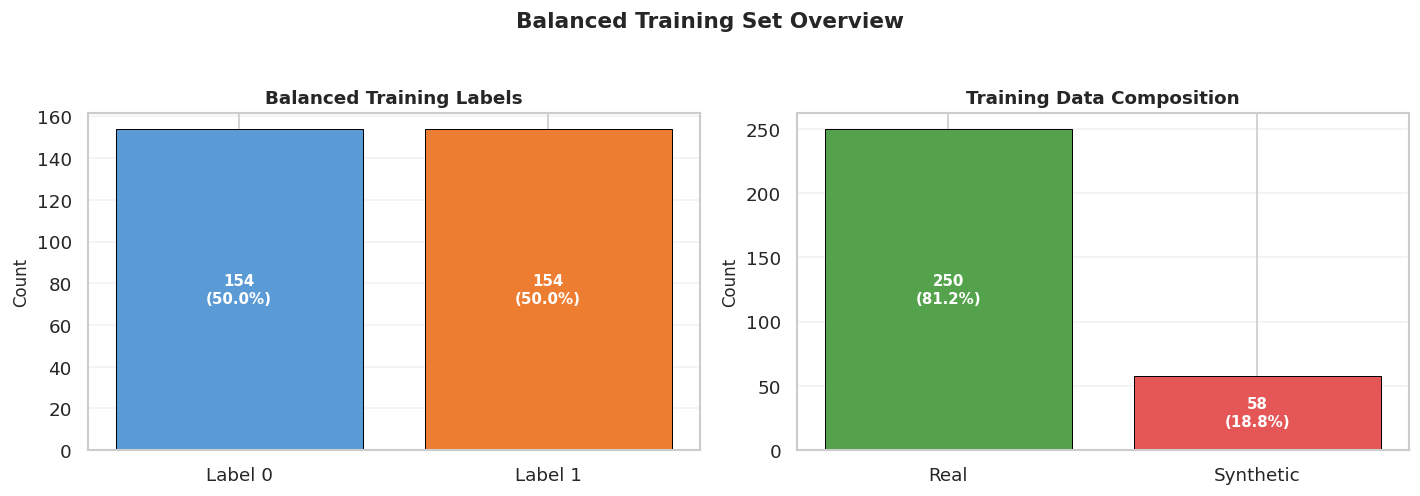

Balanced training set:
  Total      : 308
  Label = 0  : 154
  Label = 1  : 154
  Synthetic  : 58


,NC,DM,NS,ADD,SUB,CA,Label,NC_incomplete,DM_incomplete,NS_incomplete,ADD_incomplete,SUB_incomplete,CA_incomplete,NP,SN,AF,BC,AS,PF,is_synthetic
0,821.736842,2534.250000,6.0,29.0,26.0,14.5,1,0,0,0,1,1,1,1677.993421,-1712.513158,18.875,13.0,3.0,0.011249,0
1,1503.741422,2945.500000,11.0,32.0,36.0,17.0,0,0,0,0,0,0,0,2224.620711,-1441.758578,24.000,17.0,-4.0,0.010788,0
2,1195.480000,1855.170732,11.0,30.0,24.0,24.0,0,0,0,0,0,0,1,1525.325366,-659.690732,22.250,3.0,6.0,0.014587,0
3,859.591837,1832.775000,17.0,32.0,35.0,24.0,0,0,0,0,0,0,0,1346.183418,-973.183163,27.000,9.5,-3.0,0.020057,0
4,1229.583333,2728.342105,15.0,43.0,31.0,20.0,0,0,0,0,0,0,0,1978.962719,-1498.758772,27.250,17.0,12.0,0.013770,0


In [36]:
df_train_full = compute_derived(df_train)
df_train_full['is_synthetic'] = 0

# Concatenate real and synthetic training rows into one balanced training set.
df_train_balanced = pd.concat([df_train_full, df_selected_full], ignore_index=True)
counts = df_train_balanced['Label'].value_counts().sort_index()
source_counts = df_train_balanced['is_synthetic'].value_counts().sort_index()
total_rows = len(df_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Label balance (0 vs 1)
label_vals = [counts.get(0, 0), counts.get(1, 0)]
label_bars = axes[0].bar(['Label 0', 'Label 1'], label_vals,
                         color=[TYPICAL_COLOR, AT_RIST_COLOR], edgecolor='black', linewidth=0.6)
axes[0].set_title('Balanced Training Labels', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.25)

# Real vs Synthetic composition
source_vals = [source_counts.get(0, 0), source_counts.get(1, 0)]
source_bars = axes[1].bar(['Real', 'Synthetic'], source_vals,
                          color=[REAL_COLOR, SYNTHETIC_COLOR], edgecolor='black', linewidth=0.6)
axes[1].set_title('Training Data Composition', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.25)

# Annotate bars with count + percentage in the middle
for ax, values, bars in [
    (axes[0], label_vals, label_bars),
    (axes[1], source_vals, source_bars),
]:
    for value, bar in zip(values, bars):
        pct = (value / total_rows * 100) if total_rows else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'{value}\n({pct:.1f}%)',
            ha='center',
            va='center',
            fontsize=9,
            fontweight='bold',
            color='white',
        )

plt.suptitle('Balanced Training Set Overview', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Balanced training set:')
print(f'  Total      : {len(df_train_balanced)}')
print(f'  Label = 0  : {counts.get(0, 0)}')
print(f'  Label = 1  : {counts.get(1, 0)}')
print(f'  Synthetic  : {source_counts.get(1, 0)}')

display(df_train_balanced.head())

## 7. Visualisations

To empirically verify the quality and structural integrity of the synthetic minority class against the real minority distribution, a suite of four diagnostic visual analyses are performed: 
1. **Overlaid histograms** — marginal distribution match per raw feature
2. **Q-Q plots** — quantile-level alignment per raw feature
3. **Correlation heatmaps** — feature relationship preservation
4. **Distribution check summary heatmap** — all metrics at a glance

### 7.1 Overlaid Histograms

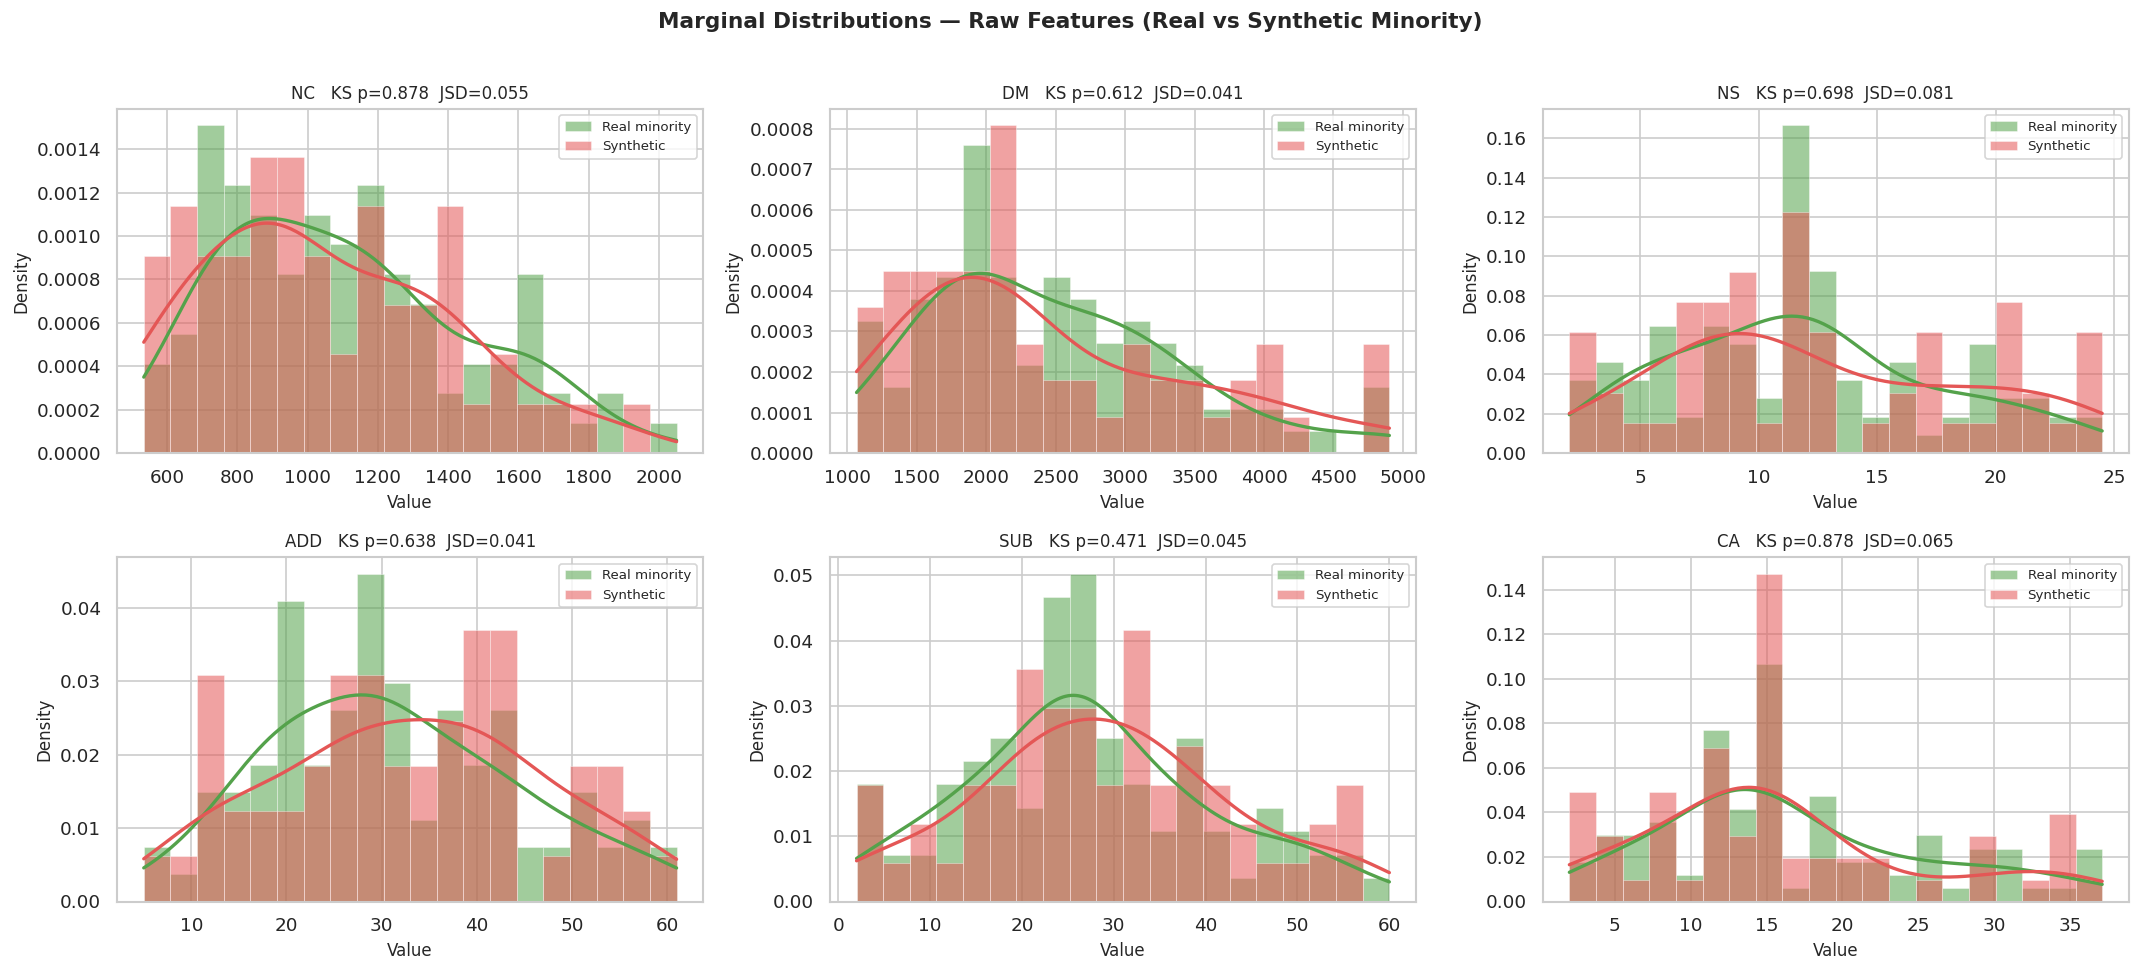

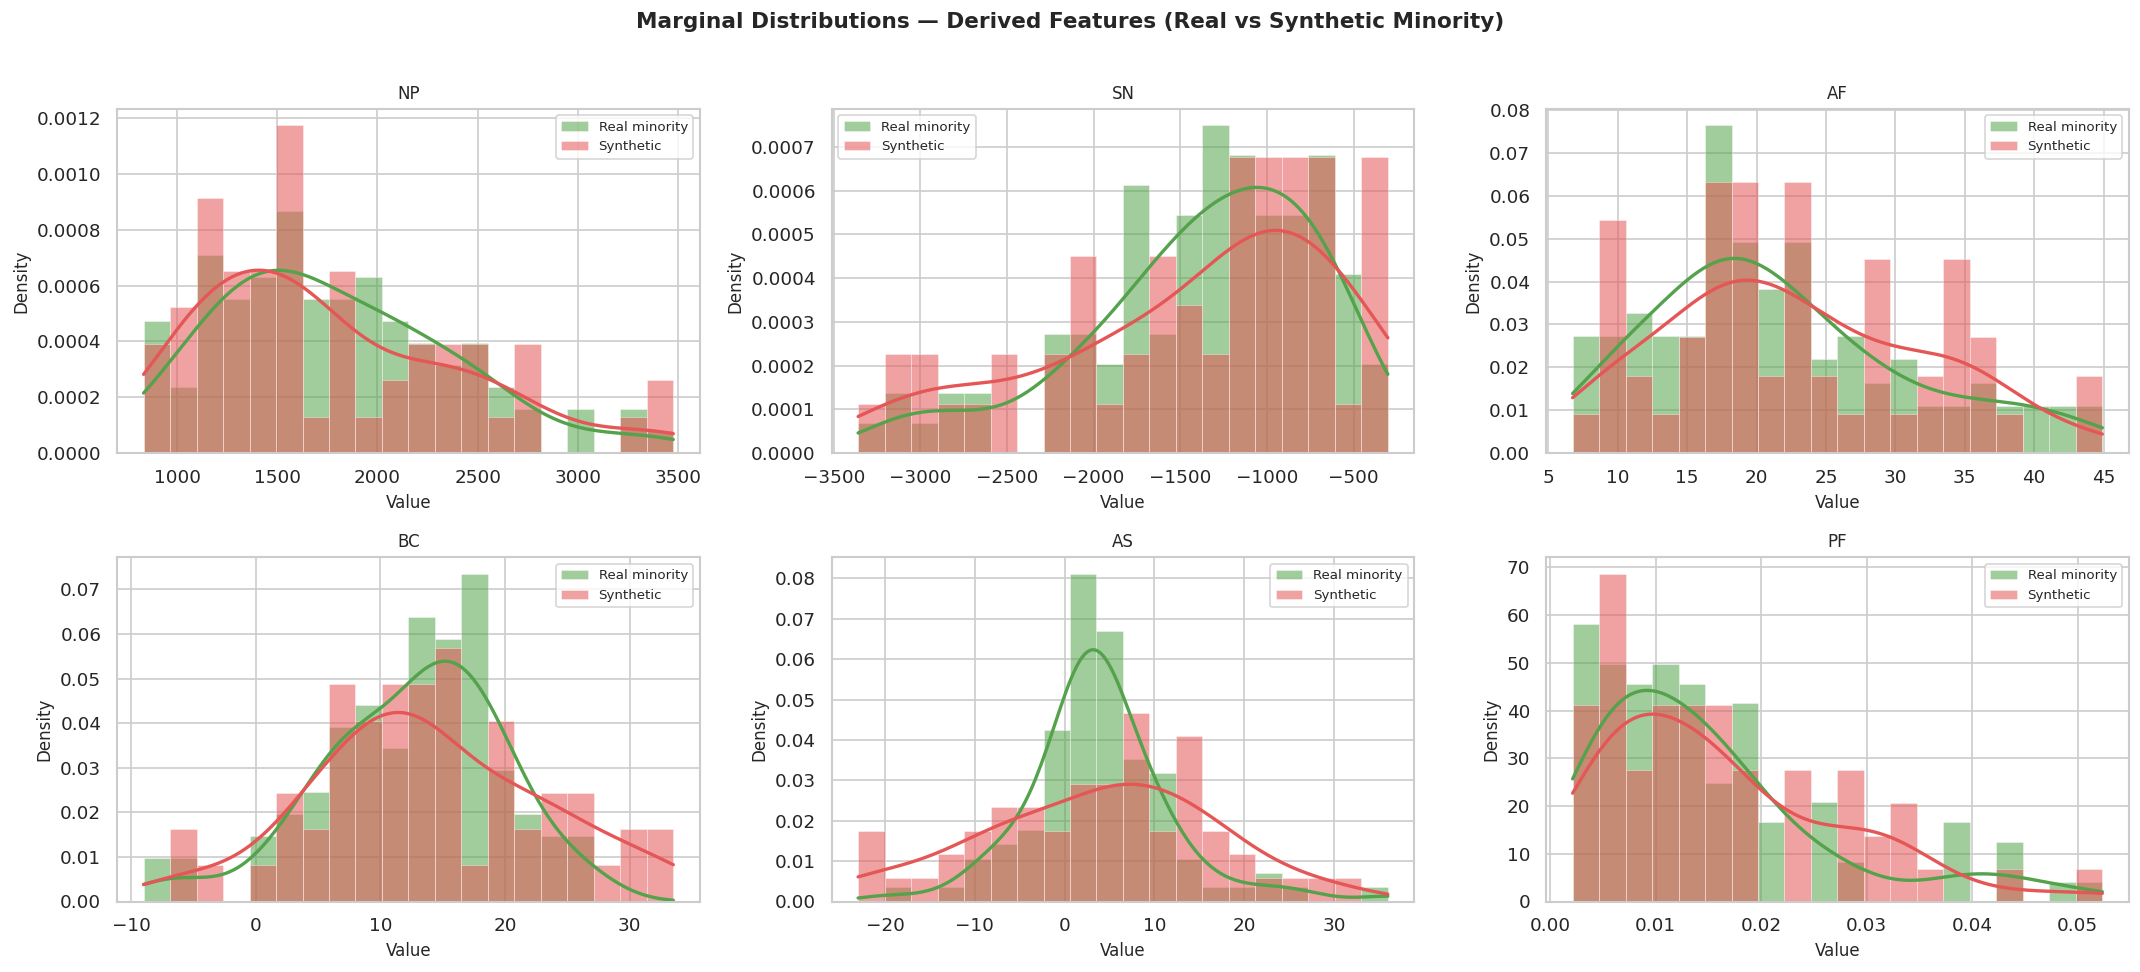

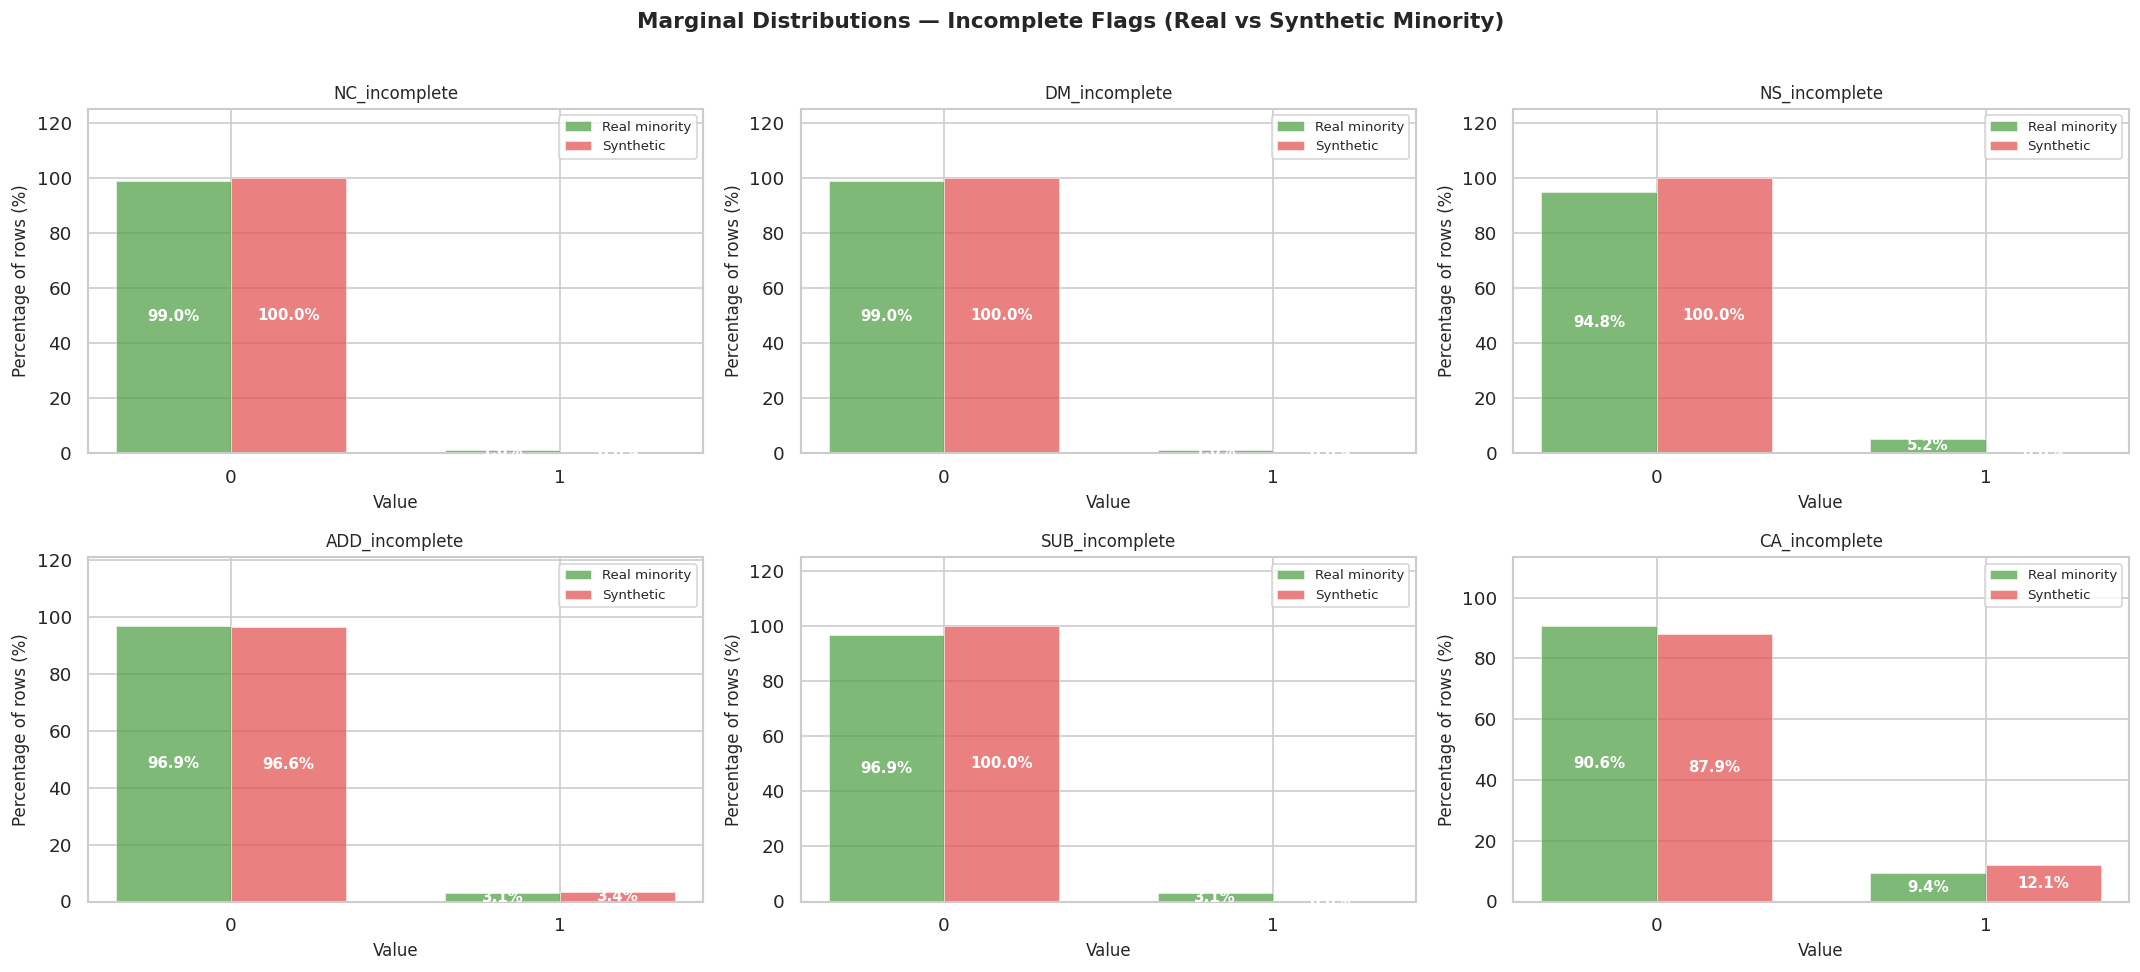

In [37]:
FEATURE_GROUPS = {
    'Raw Features': RAW_FEATURES,
    'Derived Features': ['NP', 'SN', 'AF', 'BC', 'AS', 'PF'],
    'Incomplete Flags': [f + '_incomplete' for f in RAW_FEATURES],
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_vals = df_train_vis[f]
        syn_vals  = df_selected_full[f]

        if f.endswith('_incomplete'):
            categories = np.array([0, 1])
            real_pct = [((real_vals == value).mean() * 100) for value in categories]
            syn_pct  = [((syn_vals == value).mean() * 100) for value in categories]
            x = np.arange(len(categories))
            width = 0.35

            real_bars = ax.bar(x - width / 2, real_pct, width,
                               color=REAL_COLOR, alpha=0.75,
                               label='Real minority', edgecolor='white', linewidth=0.4)
            syn_bars = ax.bar(x + width / 2, syn_pct, width,
                              color=SYNTHETIC_COLOR, alpha=0.75,
                              label='Synthetic', edgecolor='white', linewidth=0.4)

            ax.set_xticks(x)
            ax.set_xticklabels(['0', '1'])
            ax.set_ylabel('Percentage of rows (%)')
            ax.set_ylim(0, max(real_pct + syn_pct) * 1.25 if (real_pct + syn_pct) else 1)

            for bars in (real_bars, syn_bars):
                for bar in bars:
                    h = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width() / 2, h / 2,
                            f'{h:.1f}%', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
        else:
            bins = np.histogram_bin_edges(np.concatenate([real_vals, syn_vals]), bins=20)

            ax.hist(real_vals, bins=bins, alpha=0.55, color=REAL_COLOR,
                    label='Real minority', density=True, edgecolor='white', linewidth=0.4)
            ax.hist(syn_vals,  bins=bins, alpha=0.55, color=SYNTHETIC_COLOR,
                    label='Synthetic',    density=True, edgecolor='white', linewidth=0.4)

            # KDE curves for non-degenerate distributions
            if len(np.unique(real_vals)) > 1 and len(np.unique(syn_vals)) > 1:
                xgrid = np.linspace(bins[0], bins[-1], 200)
                ax.plot(xgrid, gaussian_kde(real_vals)(xgrid), color=REAL_COLOR, lw=2)
                ax.plot(xgrid, gaussian_kde(syn_vals)(xgrid),  color=SYNTHETIC_COLOR,    lw=2)

            ax.set_ylabel('Density')

        # Keep KS/JSD annotation only for raw features
        if df_dist_results is not None and f in RAW_FEATURES:
            row = df_dist_results[df_dist_results['feature'] == f].iloc[0]
            ax.set_title(f"{f}   KS p={row['KS_p']:.3f}  JSD={row['JSD']:.3f}", fontsize=10)
        else:
            ax.set_title(f, fontsize=10)

        ax.set_xlabel('Value')
        ax.legend(fontsize=8)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Marginal Distributions — {group_name} (Real vs Synthetic Minority)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 7.2 Q-Q Plots

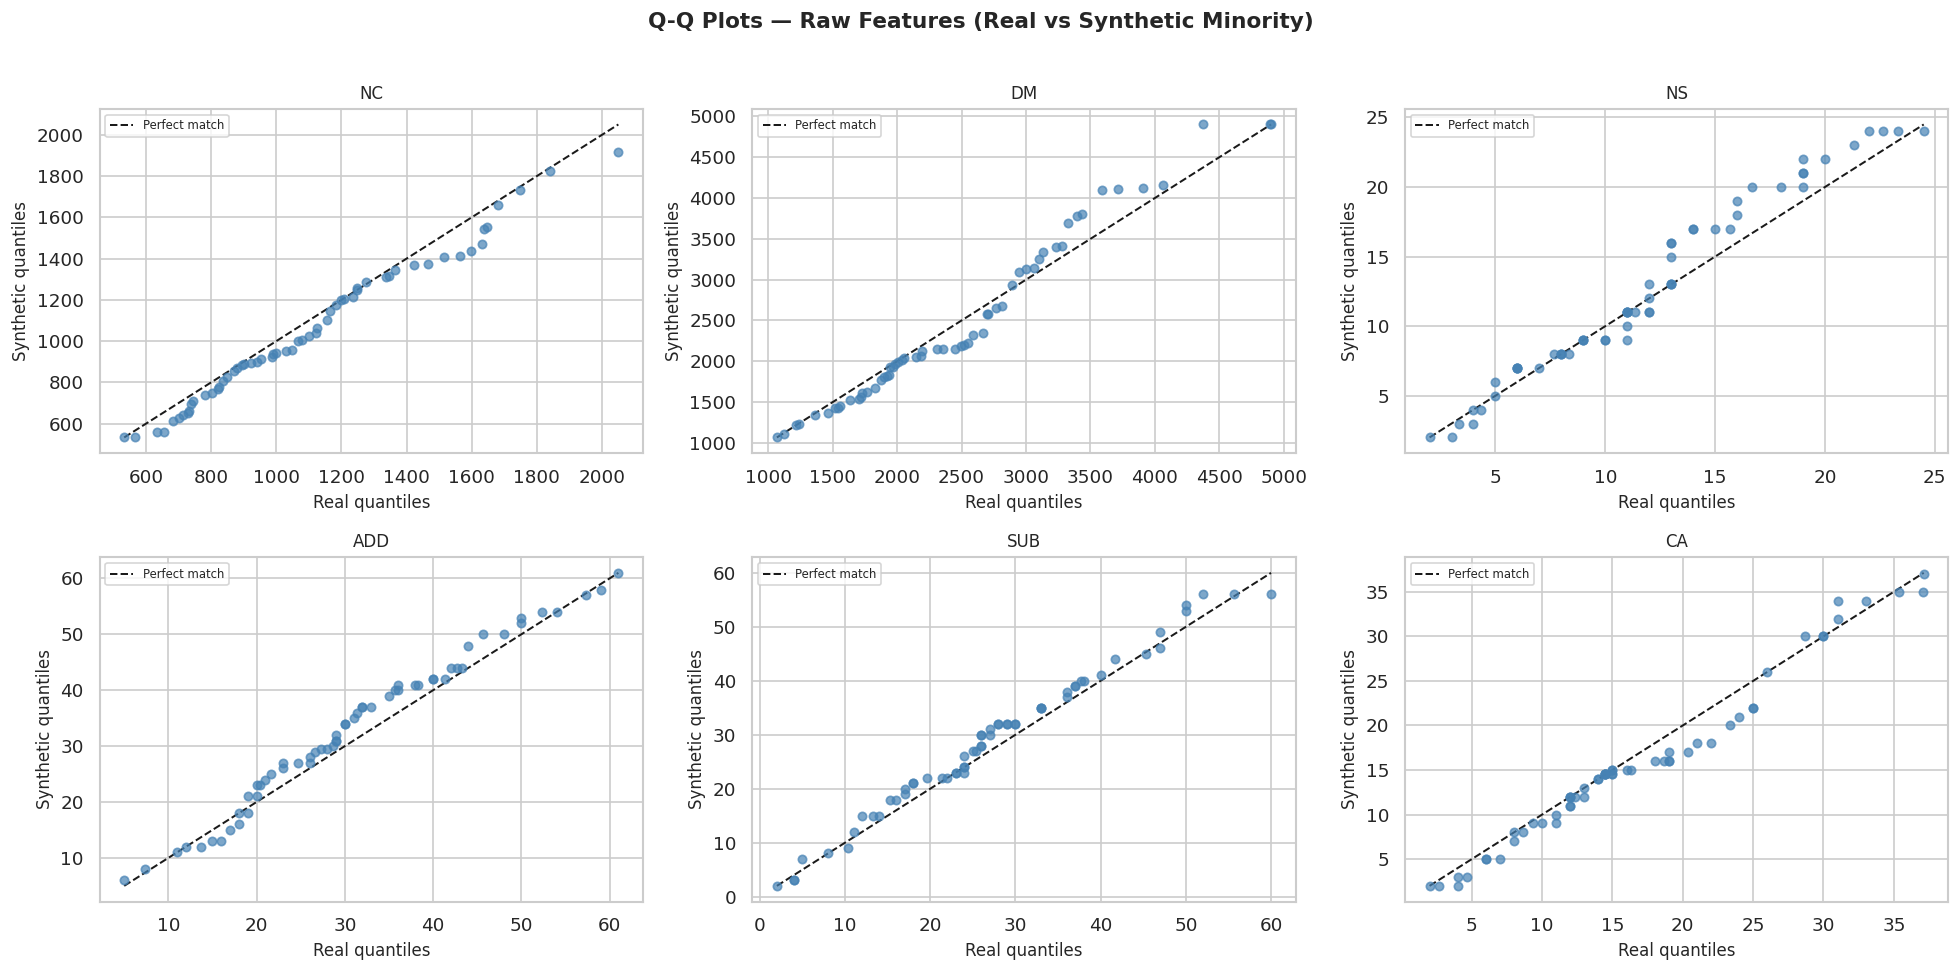

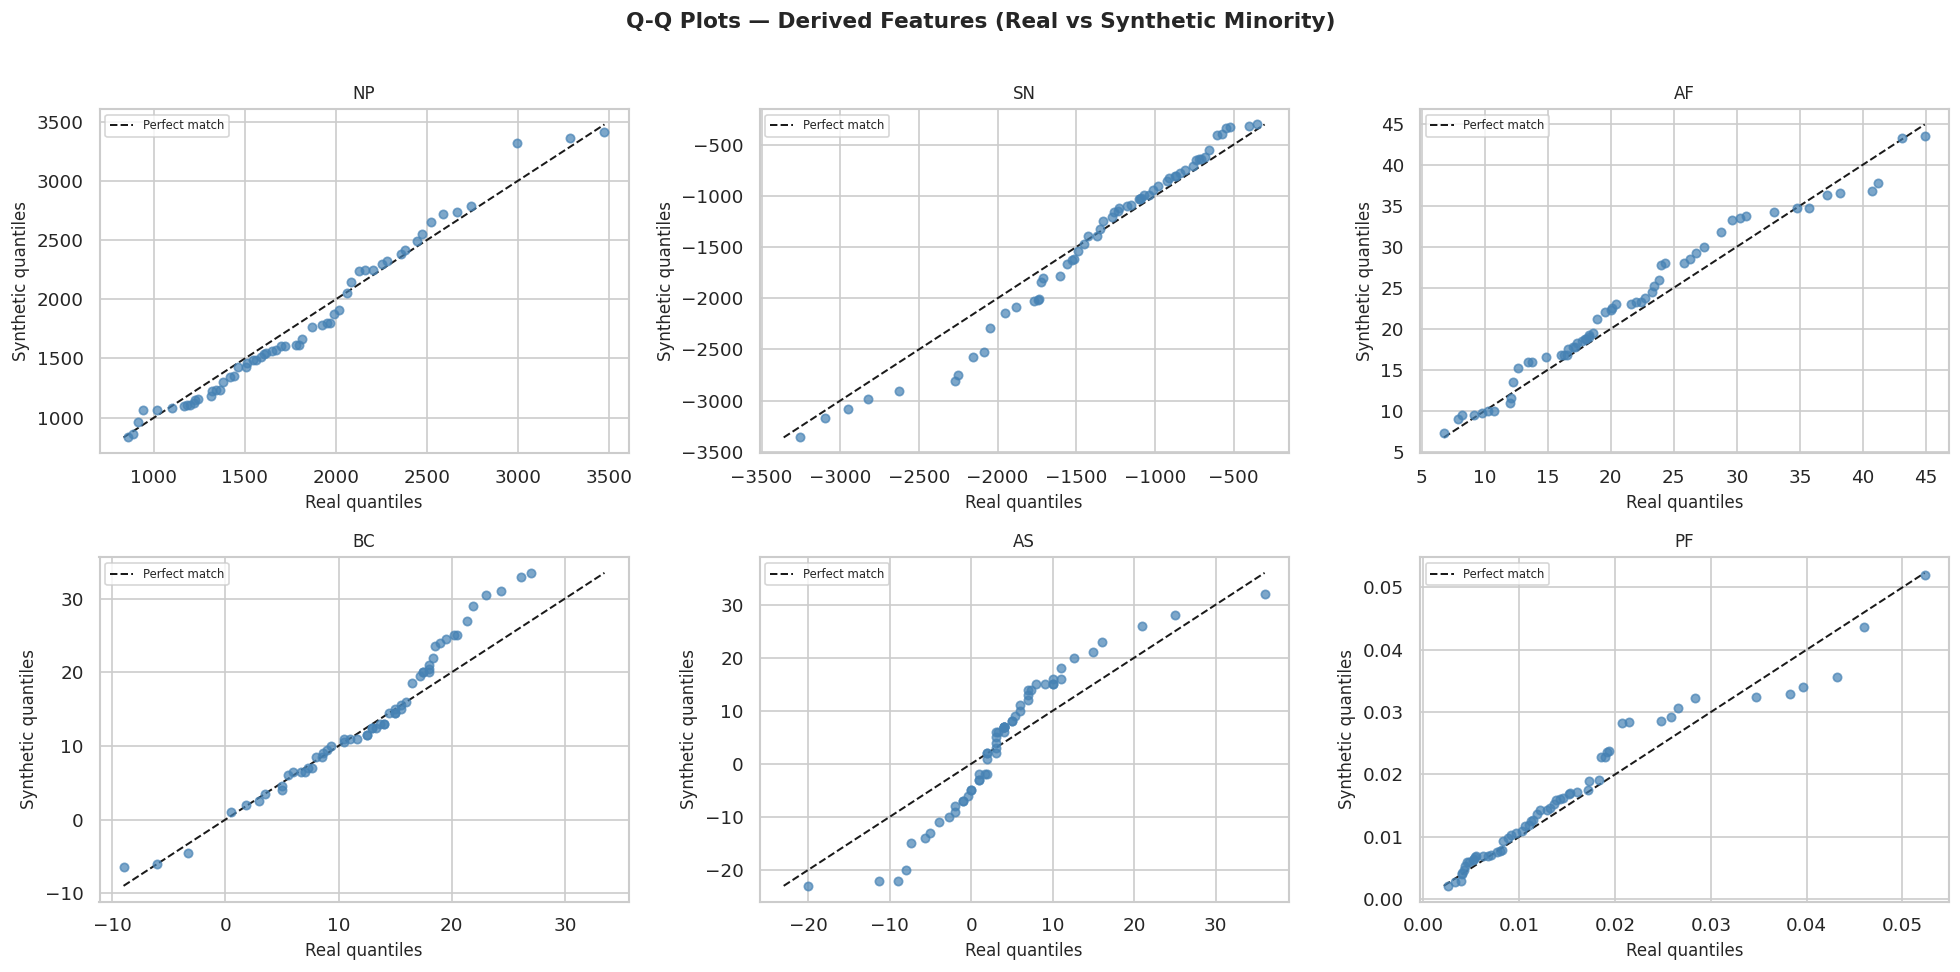

In [38]:
FEATURE_GROUPS = {
    'Raw Features': RAW_FEATURES,
    'Derived Features': DERIVED_FEATURES
}
df_train_vis = df_train_full[df_train_full['Label'] == 1]

for group_name, feature_list in FEATURE_GROUPS.items():
    ncols = 3
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows))
    axes = np.array(axes).ravel()

    for i, f in enumerate(feature_list):
        ax = axes[i]
        real_sorted = np.sort(df_train_vis[f].values)
        syn_sorted  = np.sort(df_selected_full[f].values)

        # Interpolate to common quantile grid
        quantiles = np.linspace(0, 1, min(len(real_sorted), len(syn_sorted)))
        real_q = np.quantile(real_sorted, quantiles)
        syn_q  = np.quantile(syn_sorted,  quantiles)

        ax.scatter(real_q, syn_q, color='steelblue', alpha=0.7, s=25, zorder=3)

        # Perfect-match reference line
        lo = min(real_q.min(), syn_q.min())
        hi = max(real_q.max(), syn_q.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='Perfect match')

        ax.set_title(f, fontsize=10)
        ax.set_xlabel('Real quantiles')
        ax.set_ylabel('Synthetic quantiles')
        ax.legend(fontsize=7)

    for j in range(len(feature_list), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Q-Q Plots — {group_name} (Real vs Synthetic Minority)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


### 7.3 Correlation Matrix Heatmaps

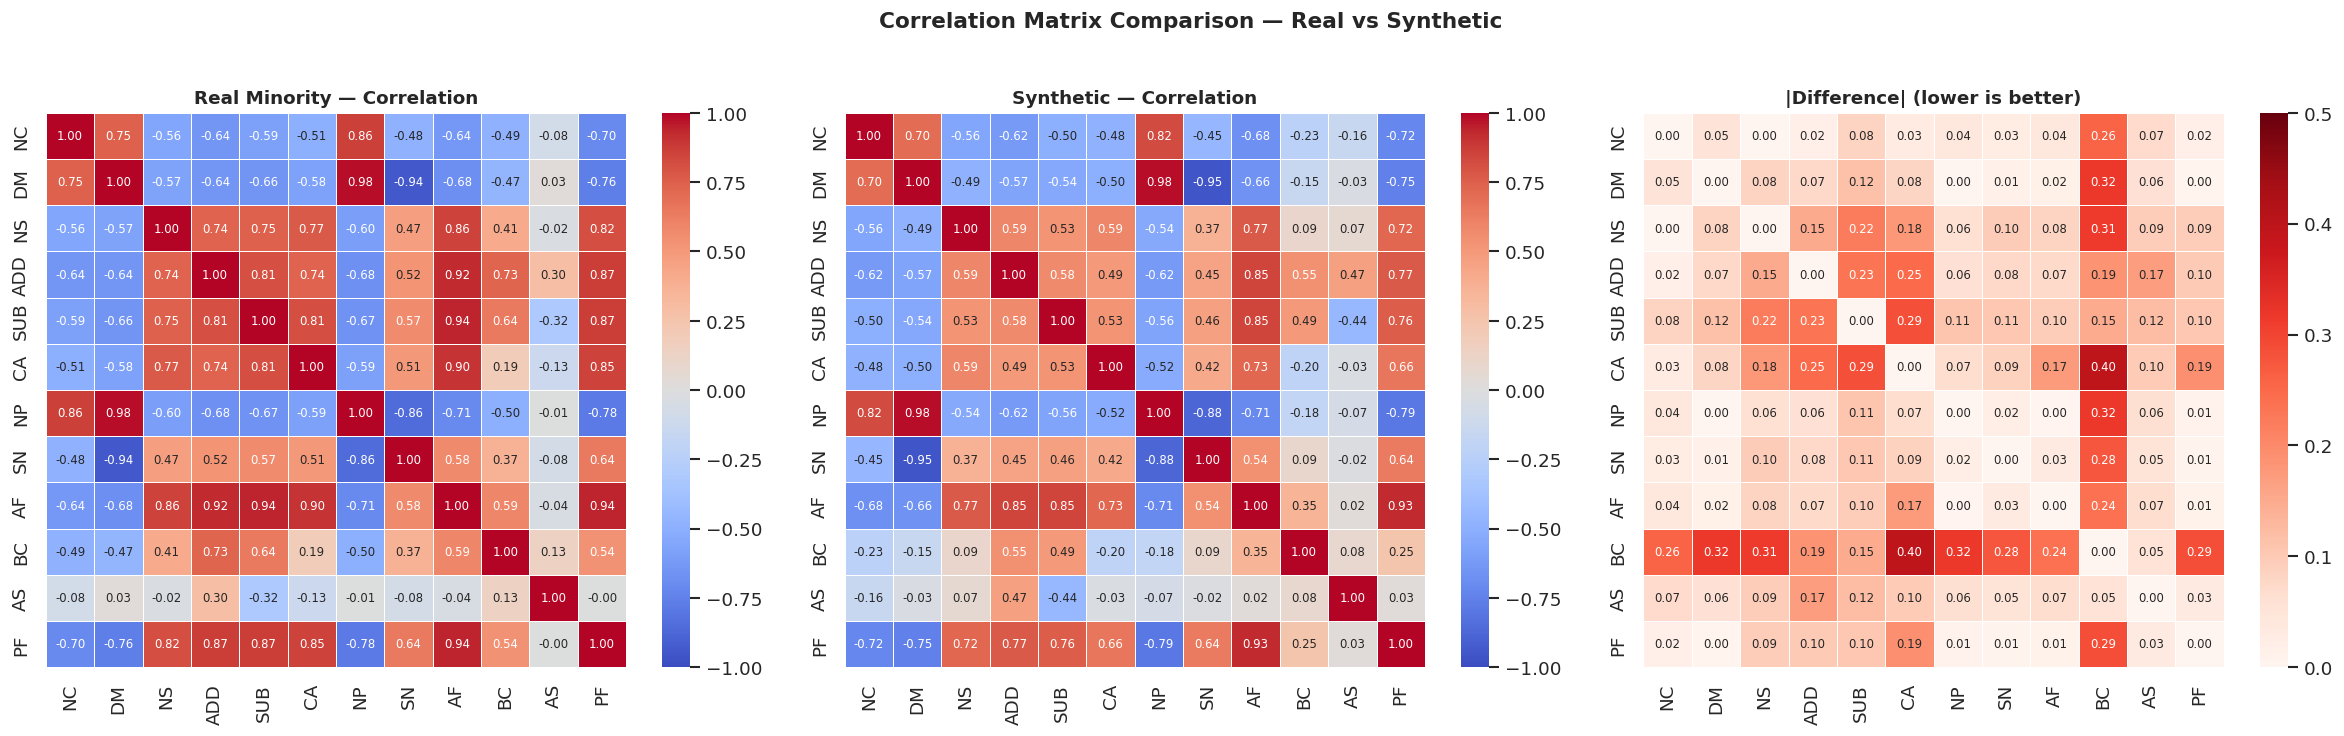

In [39]:
ALL_FEATURES = RAW_FEATURES + DERIVED_FEATURES

corr_real = df_train_full[df_train_full['Label'] == 1][ALL_FEATURES].corr()
corr_syn  = df_selected_full[ALL_FEATURES].corr()
corr_diff = (corr_syn - corr_real).abs()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

kw = dict(annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
           linewidths=0.3, annot_kws={'size': 7})

sns.heatmap(corr_real, ax=axes[0], **kw)
axes[0].set_title('Real Minority — Correlation', fontweight='bold')

sns.heatmap(corr_syn, ax=axes[1], **kw)
axes[1].set_title('Synthetic — Correlation', fontweight='bold')

sns.heatmap(corr_diff, ax=axes[2], annot=True, fmt='.2f',
            cmap='Reds', vmin=0, vmax=0.5,
            linewidths=0.3, annot_kws={'size': 7})
axes[2].set_title('|Difference| (lower is better)', fontweight='bold')

plt.suptitle('Correlation Matrix Comparison — Real vs Synthetic',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Distribution Check Summary

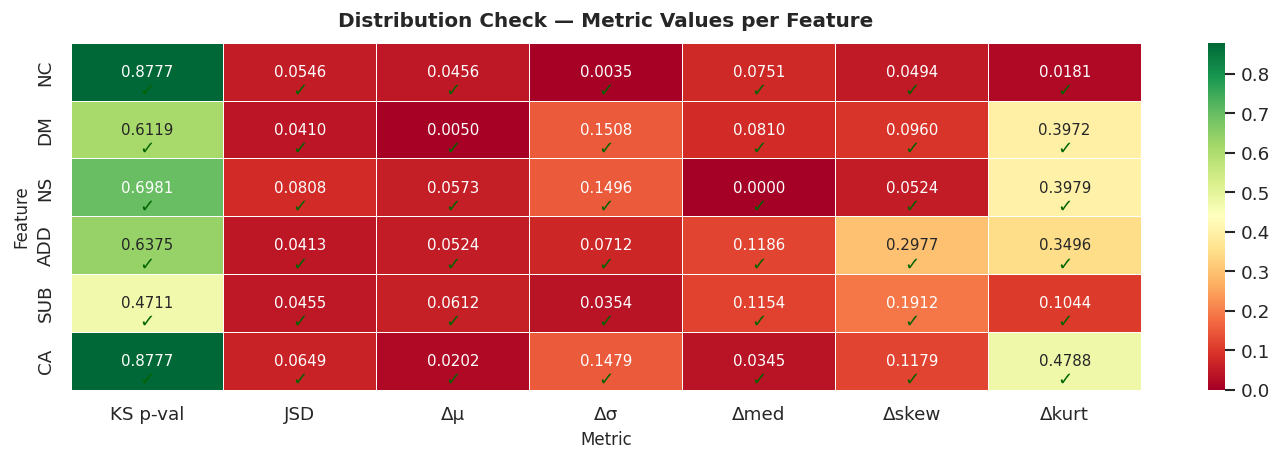

In [40]:
if df_dist_results is not None:
    metrics   = ['KS_p', 'JSD', 'delta_mu', 'delta_std', 'delta_med', 'delta_skew', 'delta_kurt']
    thresholds = {
        'KS_p'      : (DIST_THRESHOLDS['ks_pval'], True),
        'JSD'       : (DIST_THRESHOLDS['JSD_THRESHOLD'], False),
        'delta_mu'  : (DIST_THRESHOLDS['T_mu'],   False),
        'delta_std' : (DIST_THRESHOLDS['T_sigma'], False),
        'delta_med' : (DIST_THRESHOLDS['T_med'],   False),
        'delta_skew': (DIST_THRESHOLDS['T_skew'],  False),
        'delta_kurt': (DIST_THRESHOLDS['T_kurt'],  False),
    }
    labels = ['KS p-val', 'JSD', 'Δμ', 'Δσ', 'Δmed', 'Δskew', 'Δkurt']

    heat_val  = df_dist_results.set_index('feature')[metrics]

    # Build pass/fail mask
    pass_mask = pd.DataFrame(index=heat_val.index, columns=metrics)
    for m, (thr, higher) in thresholds.items():
        if higher:
            pass_mask[m] = heat_val[m] > thr
        else:
            pass_mask[m] = heat_val[m] < thr

    fig, ax = plt.subplots(figsize=(12, 4))
    heat_display = heat_val.copy()
    heat_display.columns = labels

    sns.heatmap(
        heat_display.astype(float),
        ax=ax, annot=True, fmt='.4f',
        cmap='RdYlGn', linewidths=0.5, linecolor='white',
        annot_kws={'size': 9},
    )

    # Overlay ✓/✗ on each cell
    for row_i, feat in enumerate(heat_val.index):
        for col_j, m in enumerate(metrics):
            ok = pass_mask.loc[feat, m]
            ax.text(col_j + 0.5, row_i + 0.82, '✓' if ok else '✗',
                    ha='center', va='center', fontsize=11,
                    color='darkgreen' if ok else 'darkred', fontweight='bold')

    ax.set_title('Distribution Check — Metric Values per Feature',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Metric')
    ax.set_ylabel('Feature')

    plt.tight_layout()
    plt.show()

## 8. Save Outputs

The finalised splits—now featuring a selectively balanced training set alongside untouched, purely real validation and test sets—are exported to persistent storage. This ensures a clean, auditable hand-off to the predictive modeling pipeline.

In [41]:
df_val_full  = compute_derived(df_val)
df_test_full = compute_derived(df_test)

DATASETS_FILENAMES = {
    'train': DATASETS_DIR / 'train.csv',
    's_train': DATASETS_DIR / 's_train.csv',
    'val': DATASETS_DIR / 'val.csv',
    'test': DATASETS_DIR / 'test.csv'
}

# Real Train Data only (both labels 0 and 1)
df_train_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['train'], index=False)

# Synthetic Train Data (label 1 only)
df_selected_full.drop(columns=["is_synthetic"]).to_csv(DATASETS_FILENAMES['s_train'], index=False)

# Validation and Test Data
df_val_full.to_csv(DATASETS_FILENAMES['val'],   index=False)
df_test_full.to_csv(DATASETS_FILENAMES['test'], index=False)

print(f'Files saved to {DATASETS_DIR}:')
print(f'  {DATASETS_FILENAMES['train']}    — {len(df_train_full)} rows (real only, labels 0 and 1)')
print(f'  {DATASETS_FILENAMES['s_train']}  — {len(df_selected_full[df_selected_full["Label"] == 1])} rows (synthetic only, label 1)')
print(f'  {DATASETS_FILENAMES['val']}      — {len(df_val_full)} rows (real only)')
print(f'  {DATASETS_FILENAMES['test']}     — {len(df_test_full)} rows (real only)')


Files saved to ../datasets/processed:
  ../datasets/processed/train.csv    — 250 rows (real only, labels 0 and 1)
  ../datasets/processed/s_train.csv  — 58 rows (synthetic only, label 1)
  ../datasets/processed/val.csv      — 54 rows (real only)
  ../datasets/processed/test.csv     — 54 rows (real only)


# F. Model Training and Evaluation Design
These sections compare the TRTR (Train-Real-Test-Real) and TSTR (Train-Synthetic-Test-Real) methodologies.


# TSTR vs TRTR Evaluation Pipeline

**Strategy:** This notebook compares a model trained on Real-only data (TRTR) versus Real + Synthetic data (TSTR).

**Pipeline:**
1. Hyperparameter tuning
2. Cross-validation comparisons
3. Outlier fold investigation
4. Final test set evaluation
5. Feature importance analysis
6. Deployment CSV export



## Imports & Configuration



In [42]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))

from itertools import product
from typing import Dict, List, Optional
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, mean_squared_error
from src.C45DecisionTree import C45DecisionTree
from pathlib import Path

## Feature + Domain Definitions



In [43]:
FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
}
FUNA_DB_RAW_FEATURES: List[str] = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete",
]
FUNA_DB_DIAGNOSTIC_FEATURES: List[str] = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
    "NP", "SN", "AF", "BC", "AS", "PF",
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete",
]

# Features that signal missing/incomplete data.
# The tree may still split on these (they carry real signal),
# but we exclude them from diagnostic z-score severity so that
# "timed out" is never conflated with "performed poorly".
INCOMPLETE_FLAGS = {
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete"
}




## Helpers



In [44]:

def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    X = df[FUNA_DB_DIAGNOSTIC_FEATURES]
    y = df[label_col]
    return X, y

def get_preds(tree, X: pd.DataFrame) -> List[int]:
    return [int(pred) for pred in tree.predict(X)]

def get_probs(tree, X: pd.DataFrame) -> np.ndarray:
    """Predict probability of the At-Risk class from reached leaf distributions."""
    return tree.predict_proba(X, positive_class=1)

def safe_roc_auc(y_true, probs) -> float:
    y_numeric = np.asarray(y_true).astype(int)
    if len(np.unique(y_numeric)) < 2:
        return np.nan
    return roc_auc_score(y_numeric, probs)

def compute_metrics(y_true, preds, probs=None) -> dict:
    y_numeric = np.asarray(y_true).astype(int)
    metrics = {
        'f1':        f1_score(y_numeric, preds, zero_division=0),
        'fbeta':     fbeta_score(y_numeric, preds, beta=2, zero_division=0),
        'recall':    recall_score(y_numeric, preds, zero_division=0),
        'precision': precision_score(y_numeric, preds, zero_division=0),
        'accuracy':  accuracy_score(y_numeric, preds),
    }
    if probs is not None:
        metrics['auc'] = safe_roc_auc(y_numeric, probs)
        metrics['rmse'] = np.sqrt(mean_squared_error(y_numeric, probs))
    return metrics

def run_cv(X_train: pd.DataFrame, y_train: pd.Series, label: str,
           best_params: dict,
           n_real: Optional[int] = None) -> tuple[dict, list[dict]]:

    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_f1, cv_fbeta, cv_recall, cv_precision, cv_accuracy = [], [], [], [], []
    cv_auc, cv_rmse = [], []
    fold_records = []

    if n_real is not None:
        X_real  = X_train.iloc[:n_real].reset_index(drop=True)
        y_real  = y_train.iloc[:n_real].reset_index(drop=True)
        X_synth = X_train.iloc[n_real:].reset_index(drop=True)
        y_synth = y_train.iloc[n_real:].reset_index(drop=True)
    else:
        X_real, y_real = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
        X_synth, y_synth = X_train.iloc[:0], y_train.iloc[:0]

    print(f'\nStarting 5-Fold Cross-Validation [{label}]...')
    if n_real is not None:
        print(f'  (folding over {len(X_real)} real samples; '
              f'{len(X_synth)} synthetic rows pinned to every train fold)')

    for fold, (train_index, val_index) in enumerate(skf.split(X_real, y_real), 1):

        X_val_fold = X_real.iloc[val_index]
        y_val_fold = y_real.iloc[val_index]

        X_trn_fold = pd.concat([X_real.iloc[train_index], X_synth], ignore_index=True)
        y_trn_fold = pd.concat([y_real.iloc[train_index], y_synth], ignore_index=True)

        tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_trn_fold, y_trn_fold,
                 raw_features=FUNA_DB_RAW_FEATURES)

        preds = get_preds(tree, X_val_fold)
        probs = get_probs(tree, X_val_fold)
        m     = compute_metrics(y_val_fold, preds, probs)

        cv_f1.append(m['f1'])
        cv_fbeta.append(m['fbeta'])
        cv_recall.append(m['recall'])
        cv_precision.append(m['precision'])
        cv_accuracy.append(m['accuracy'])
        cv_auc.append(m['auc'])
        cv_rmse.append(m['rmse'])

        fold_records.append({
            'fold': fold,
            'recall': m['recall'],
            'fbeta': m['fbeta'],
            'auc': m['auc'],
            'rmse': m['rmse'],
            'tree_depth': tree.get_depth(),
            'tree_leaves': tree.get_leaves_num(),
            'n_train':       len(X_trn_fold),
            'class_0_train': int((y_trn_fold == 0).sum()),
            'class_1_train': int((y_trn_fold == 1).sum()),
            'n_val':         len(X_val_fold),
            'class_0_val':   int((y_val_fold == 0).sum()),
            'class_1_val':   int((y_val_fold == 1).sum()),
        })

        print(f'  Fold {fold}: F1={m["f1"]:.4f}, F2={m["fbeta"]:.4f}, Recall={m["recall"]:.4f}, AUC={m["auc"]:.4f}, RMSE={m["rmse"]:.4f}')

    aggregated = {
        'mean_f1': np.mean(cv_f1), 'std_f1': np.std(cv_f1),
        'mean_fbeta': np.mean(cv_fbeta), 'std_fbeta': np.std(cv_fbeta),
        'mean_recall': np.mean(cv_recall), 'std_recall': np.std(cv_recall),
        'mean_precision': np.mean(cv_precision), 'std_precision': np.std(cv_precision),
        'mean_accuracy': np.mean(cv_accuracy), 'std_accuracy': np.std(cv_accuracy),
        'mean_auc': np.nanmean(cv_auc), 'std_auc': np.nanstd(cv_auc),
        'mean_rmse': np.mean(cv_rmse), 'std_rmse': np.std(cv_rmse),
    }

    return aggregated, fold_records

def print_cv_results(label: str, metrics: dict):
    print(f'\n=== Cross-Validation Performance [{label}] (5-Fold) ===')
    print(f'  Recall:    {metrics["mean_recall"]:.4f} +/- {metrics["std_recall"]:.4f}')
    print(f'  Precision: {metrics["mean_precision"]:.4f} +/- {metrics["std_precision"]:.4f}')
    print(f'  F1-Score:  {metrics["mean_f1"]:.4f} +/- {metrics["std_f1"]:.4f}')
    print(f'  F2-Score:  {metrics["mean_fbeta"]:.4f} +/- {metrics["std_fbeta"]:.4f}')
    print(f'  Accuracy:  {metrics["mean_accuracy"]:.4f} +/- {metrics["std_accuracy"]:.4f}')
    print(f'  AUC-ROC:   {metrics["mean_auc"]:.4f} +/- {metrics["std_auc"]:.4f}')
    print(f'  RMSE:      {metrics["mean_rmse"]:.4f} +/- {metrics["std_rmse"]:.4f}')

def print_variance_inspection(label: str, fold_records: list[dict]):
    df = pd.DataFrame(fold_records)
    mean_recall = df['recall'].mean()
    std_recall  = df['recall'].std()

    print(f'\n--- Fold Variance Inspection [{label}] ---')
    print(f'{"Fold":>5} {"N_train":>8} {"C0_tr":>6} {"C1_tr":>6} '
          f'{"N_val":>6} {"C0_val":>7} {"C1_val":>7} '
          f'{"Depth":>6} {"Leaves":>7} {"Recall":>8} {"F2":>8} {"Flag"}')
    print('-' * 95)

    for _, row in df.iterrows():
        flag = (
            ' HIGH' if row['recall'] > mean_recall + std_recall else
            ' LOW' if row['recall'] < mean_recall - std_recall else
            ''
        )
        print(f'{int(row["fold"]):>5} {int(row["n_train"]):>8} {int(row["class_0_train"]):>6} '
              f'{int(row["class_1_train"]):>6} {int(row["n_val"]):>6} '
              f'{int(row["class_0_val"]):>7} {int(row["class_1_val"]):>7} '
              f'{int(row["tree_depth"]):>6} {int(row["tree_leaves"]):>7} '
              f'{row["recall"]:>8.4f} {row["fbeta"]:>8.4f}{flag}')

    print(f'\n  Recall range : {df["recall"].min():.4f} - {df["recall"].max():.4f}')
    print(f'  Recall mean  : {mean_recall:.4f} +/- {std_recall:.4f}')

    corr_c1    = df['class_1_train'].corr(df['recall'])
    corr_depth = df['tree_depth'].corr(df['recall'])
    print(f'\n  Correlation: class_1_train vs recall = {corr_c1:+.3f}')
    print(f'  Correlation: tree_depth     vs recall = {corr_depth:+.3f}')
    if abs(corr_c1) > 0.6:
        print('  Strong correlation with positive-class count in training fold.')
        print('    Synthetic data may not be uniformly covering all subgroups.')




## Load Data



In [45]:
print('Loading 70/15/15 Datasets...')
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR.parent / "datasets" / "processed"

r_train = pd.read_csv(DATASET_DIR / "train.csv")
s_train = pd.read_csv(DATASET_DIR / "s_train.csv")
val_df  = pd.read_csv(DATASET_DIR / "val.csv")
test_df = pd.read_csv(DATASET_DIR / "test.csv")




Loading 70/15/15 Datasets...


## Prepare Train Sets



In [46]:
train_trtr = r_train.copy()                                     # TRTR: real only
train_tstr = pd.concat([r_train, s_train], ignore_index=True)  # TSTR: real + synthetic

print(f'TRTR Train shape (Real 70%):         {train_trtr.shape}')
print(f'TSTR Train shape (Real + Synth):     {train_tstr.shape}')
print(f'Validation shape (Real 15%):         {val_df.shape}')
print(f'Test shape (Real 15%):               {test_df.shape}')

print(f'\nSynthetic data class distribution:')
print(s_train['Label'].value_counts().rename({0: 'Typical (0)', 1: 'At-Risk (1)'}).to_string())




TRTR Train shape (Real 70%):         (250, 19)
TSTR Train shape (Real + Synth):     (308, 19)
Validation shape (Real 15%):         (54, 19)
Test shape (Real 15%):               (54, 19)

Synthetic data class distribution:
Label
At-Risk (1)    58


## Split X / y



In [47]:
X_train_trtr, y_train_trtr = split_xy(train_trtr)
X_train_tstr, y_train_tstr = split_xy(train_tstr)
X_val,  y_val  = split_xy(val_df)
X_test, y_test = split_xy(test_df)




## Hyperparameter Search Space



In [48]:
PARAM_GRID = {
    # CF in [0.10, 0.50]; sampled because confidence factor is continuous.
    'conf_fact':        np.round(np.arange(0.10, 0.51, 0.05), 2).tolist(),
    # n_min in {x | x in N, 10 <= x <= 50}
    'min_samples_leaf': list(range(10, 51)),
    # d_max in {x | x in N, 5 <= x <= 15}
    'max_depth':        list(range(5, 16)),
}

def iter_param_grid(param_grid: dict):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))




## PHASE 1 — Hyperparameter Search

Train one tree per hyperparameter candidate and evaluate the tree's native class predictions. The selected setting is the best hyperparameter set by validation F2.



In [49]:
from joblib import Parallel, delayed

# Use process-based parallelism for the custom Python tree code.
N_JOBS = min(os.cpu_count() or 1, 12)
JOBLIB_BACKEND = 'loky'
GRID_SEARCH_OUTPUT_DIR = BASE_DIR.parent / 'outputs' / 'grid_search'
GRID_SEARCH_EXPORT_COLS = [
    'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]
VALIDATION_SELECTION_METRIC_COLS = ['fbeta', 'recall', 'precision', 'f1', 'accuracy']
BEST_SELECTION_SORT_COLS = [
    *VALIDATION_SELECTION_METRIC_COLS,
]
TIE_RESOLUTION_SORT_COLS = [
    'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
    *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]

print('\n' + '=' * 60)
print('PHASE 1: Hyperparameter Search')
print('=' * 60)

print('\nSearch grid:')
for param_name, values in PARAM_GRID.items():
    print(f'  {param_name}: {values}')
print(f'  parallel jobs: {N_JOBS} ({JOBLIB_BACKEND})')

def _evaluate_candidate(candidate_no, params, X_train, y_train, X_val, y_val):
    tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    tree.fit(X_train, y_train, raw_features=FUNA_DB_RAW_FEATURES)

    preds = get_preds(tree, X_val)
    probs = get_probs(tree, X_val)
    metrics = compute_metrics(y_val, preds, probs)

    return {
        **params,
        'candidate_no': candidate_no,
        'f1': metrics['f1'],
        'fbeta': metrics['fbeta'],
        'recall': metrics['recall'],
        'precision': metrics['precision'],
        'accuracy': metrics['accuracy'],
        'auc': metrics['auc'],
        'rmse': metrics['rmse'],
        'tree_depth': tree.get_depth(),
        'tree_leaves': tree.get_leaves_num(),
    }

def _as_python_scalar(value):
    return value.item() if hasattr(value, 'item') else value

def save_grid_search_results(search_df, label):
    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_no_threshold_grid_search_results.csv'
    search_df[GRID_SEARCH_EXPORT_COLS].to_csv(output_path, index=False)
    print(f'[{label}] Saved full grid search results ({len(search_df)} rows): {output_path}')
    return output_path

def _params_from_row(row):
    params = {k: _as_python_scalar(row[k]) for k in PARAM_GRID.keys()}
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])
    return params

def _validation_best_ties(search_df):
    top_row = search_df.iloc[0]
    tied_mask = np.logical_and.reduce([
        np.isclose(search_df[col], top_row[col])
        for col in VALIDATION_SELECTION_METRIC_COLS
    ])
    tied_cols = [*VALIDATION_SELECTION_METRIC_COLS, *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    return search_df.loc[tied_mask, tied_cols].drop_duplicates(
        subset=[*PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    ).reset_index(drop=True)

def _evaluate_tied_candidate(row, X_train, y_train, label, n_real=None):
    params = _params_from_row(row)

    cv_metrics, _ = run_cv(X_train, y_train, label, params, n_real=n_real)

    return {
        **{f'val_{col}': float(row[col]) for col in VALIDATION_SELECTION_METRIC_COLS},
        **{f'cv_{key}': float(value) for key, value in cv_metrics.items()},
        **params,
        'tree_depth': int(row['tree_depth']),
        'tree_leaves': int(row['tree_leaves']),
    }

def resolve_validation_ties_with_cv(search_df, X_train, y_train, label, n_real=None):
    tied_df = _validation_best_ties(search_df)
    print(f'\n[{label}] Validation-best tied candidates: {len(tied_df)}')

    tie_records = []
    for candidate_no, (_, row) in enumerate(tied_df.iterrows(), 1):
        print(f'\n[{label}] Tie candidate {candidate_no}/{len(tied_df)}: '
              f'params={_params_from_row(row)}')
        tie_records.append(_evaluate_tied_candidate(
            row, X_train, y_train, label, n_real=n_real
        ))

    tie_results_df = pd.DataFrame(tie_records).sort_values(
        by=TIE_RESOLUTION_SORT_COLS,
        ascending=False,
    )

    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_validation_tie_no_threshold_cv_results.csv'
    tie_results_df.to_csv(output_path, index=False)
    print(f'[{label}] Saved validation-tie CV results ({len(tie_results_df)} rows): {output_path}')

    best_row = tie_results_df.iloc[0]
    best_params = _params_from_row(best_row)

    print(f'\n[{label}] Selected after validation-tie CV resolution:')
    print(f'  Params: {best_params}')
    print(f'  CV F2={best_row["cv_mean_fbeta"]:.4f}, '
          f'CV Recall={best_row["cv_mean_recall"]:.4f}, '
          f'CV Precision={best_row["cv_mean_precision"]:.4f}')

    return best_params, tie_results_df

def tune_params(X_train, y_train, X_val, y_val, label):
    candidates = list(enumerate(iter_param_grid(PARAM_GRID), 1))
    n_candidates = len(candidates)

    print(f'\n[{label}] Parallel search: {n_candidates} param combos')

    search_records = Parallel(
        n_jobs=N_JOBS,
        backend=JOBLIB_BACKEND,
        prefer='processes',
        verbose=10,
        batch_size=1,
        pre_dispatch='2*n_jobs',
    )(
        delayed(_evaluate_candidate)(candidate_no, params, X_train, y_train, X_val, y_val)
        for candidate_no, params in candidates
    )

    if not search_records:
        raise RuntimeError(f'[{label}] No search records were generated.')

    search_df = pd.DataFrame(search_records).sort_values(
        by=BEST_SELECTION_SORT_COLS,
        ascending=False,
    )

    save_grid_search_results(search_df, label)

    best_row = search_df.iloc[0]
    best_params = {k: _as_python_scalar(best_row[k]) for k in PARAM_GRID.keys()}
    best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
    best_params['max_depth'] = int(best_params['max_depth'])

    best_metrics = {
        'f1': float(best_row['f1']),
        'fbeta': float(best_row['fbeta']),
        'recall': float(best_row['recall']),
        'precision': float(best_row['precision']),
        'accuracy': float(best_row['accuracy']),
    }

    print(f'\n[{label}] Top validation candidates:')
    print(search_df[GRID_SEARCH_EXPORT_COLS].head(10).to_string(index=False))

    print(f'\n[{label}] Selected validation setting:')
    print(f'  Params: {best_params}')
    print(f'  F2={best_metrics["fbeta"]:.4f}, '
          f'Recall={best_metrics["recall"]:.4f}, '
          f'Precision={best_metrics["precision"]:.4f}')

    return best_params, search_df

BEST_PARAMS_TRTR, SEARCH_RESULTS_TRTR = tune_params(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR'
)

BEST_PARAMS_TSTR, SEARCH_RESULTS_TSTR = tune_params(
    X_train_tstr, y_train_tstr, X_val, y_val, 'TSTR'
)

BEST_PARAMS_TRTR, TIE_RESULTS_TRTR = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR, X_train_trtr, y_train_trtr, 'TRTR'
)

BEST_PARAMS_TSTR, TIE_RESULTS_TSTR = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TSTR, X_train_tstr, y_train_tstr, 'TSTR',
    n_real=len(r_train)
)





PHASE 1: Hyperparameter Search

Search grid:
  conf_fact: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
  min_samples_leaf: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
  max_depth: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  parallel jobs: 12 (loky)

[TRTR] Parallel search: 4059 param combos


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    5.0s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    7.2s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:   11.3s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   15.0s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   17.0s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   21.4s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   25.9s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   30.9s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   35.6s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   40.5s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   46.7s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   50.8s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   56.9s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TRTR] Saved full grid search results (4059 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trtr_no_threshold_grid_search_results.csv

[TRTR] Top validation candidates:
   fbeta   recall  precision      f1  accuracy      auc     rmse  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.779817 0.809524       0.68 0.73913  0.777778 0.833333 0.388199       0.25                10          5           5            8
0.779817 0.809524       0.68 0.73913  0.777778 0.833333 0.388199       0.25                10          6           5            8
0.779817 0.809524       0.68 0.73913  0.777778 0.833333 0.388199       0.25                10          7           5            8
0.779817 0.809524       0.68 0.73913  0.777778 0.833333 0.388199       0.25                10          8           5            8
0.779817 0.809524       0.68 0.73913  0.777778 0.833333 0.388199       0.25                10          9           5            8
0.779817 0.80952

[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    3.7s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    6.8s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    9.7s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   14.0s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   18.7s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   23.4s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   28.7s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   34.1s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   39.0s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   45.3s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   51.4s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   56.8s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 218 tasks      | elapsed:  1.3min
[Paralle

[TSTR] Saved full grid search results (4059 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/tstr_no_threshold_grid_search_results.csv

[TSTR] Top validation candidates:
   fbeta   recall  precision       f1  accuracy      auc     rmse  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.803571 0.857143   0.642857 0.734694  0.759259 0.844877 0.393285        0.2                17          7           7            8
0.803571 0.857143   0.642857 0.734694  0.759259 0.844877 0.393285        0.2                17          8           7            8
0.803571 0.857143   0.642857 0.734694  0.759259 0.844877 0.393285        0.2                17          9           7            8
0.803571 0.857143   0.642857 0.734694  0.759259 0.844877 0.393285        0.2                17         10           7            8
0.803571 0.857143   0.642857 0.734694  0.759259 0.844877 0.393285        0.2                17         11           7            8
0.803571 0

## PHASE 2 — TRTR vs TSTR Cross-Validation

TSTR folds only over real samples; synthetic rows are pinned to every training fold (Option A — no val leakage).



In [50]:
print('\n' + '=' * 60)
print('PHASE 2: TRTR vs TSTR CV')
print('=' * 60)

cv_metrics_trtr, fold_records_trtr = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR', BEST_PARAMS_TRTR
)
cv_metrics_tstr, fold_records_tstr = run_cv(
    X_train_tstr, y_train_tstr, 'TSTR', BEST_PARAMS_TSTR,
    n_real=len(r_train)
)

print_cv_results('TRTR', cv_metrics_trtr)
print_cv_results('TSTR', cv_metrics_tstr)





PHASE 2: TRTR vs TSTR CV

Starting 5-Fold Cross-Validation [TRTR]...
  Fold 1: F1=0.6111, F2=0.5729, Recall=0.5500, AUC=0.6942, RMSE=0.4611
  Fold 2: F1=0.5714, F2=0.5435, Recall=0.5263, AUC=0.7284, RMSE=0.4589
  Fold 3: F1=0.6316, F2=0.6316, Recall=0.6316, AUC=0.8226, RMSE=0.4115
  Fold 4: F1=0.4848, F2=0.4444, Recall=0.4211, AUC=0.6121, RMSE=0.4862
  Fold 5: F1=0.7273, F2=0.7921, Recall=0.8421, AUC=0.8345, RMSE=0.3913

Starting 5-Fold Cross-Validation [TSTR]...
  (folding over 250 real samples; 58 synthetic rows pinned to every train fold)
  Fold 1: F1=0.6512, F2=0.6796, Recall=0.7000, AUC=0.7058, RMSE=0.4669
  Fold 2: F1=0.6512, F2=0.7000, Recall=0.7368, AUC=0.7250, RMSE=0.4675
  Fold 3: F1=0.7317, F2=0.7653, Recall=0.7895, AUC=0.8565, RMSE=0.3917
  Fold 4: F1=0.5143, F2=0.4891, Recall=0.4737, AUC=0.6239, RMSE=0.4799
  Fold 5: F1=0.6222, F2=0.6863, Recall=0.7368, AUC=0.7309, RMSE=0.4618

=== Cross-Validation Performance [TRTR] (5-Fold) ===
  Recall:    0.5942 +/- 0.1410
  Precision

## PHASE 3 — Side-by-side CV Summary



In [51]:
print('\n' + '=' * 60)
print('PHASE 3: CV Summary Comparison')
print('=' * 60)

metrics_labels = [
    ('Recall',    'mean_recall',    'std_recall'),
    ('Precision', 'mean_precision', 'std_precision'),
    ('F1-Score',  'mean_f1',        'std_f1'),
    ('F2-Score',  'mean_fbeta',     'std_fbeta'),
    ('Accuracy',  'mean_accuracy',  'std_accuracy'),
    ('AUC-ROC',   'mean_auc',       'std_auc'),
    ('RMSE',      'mean_rmse',      'std_rmse'),
]

print(f'\n{"Metric":>12}  {"TRTR (mean+/-std)":>26}  {"TSTR (mean+/-std)":>26}  {"D (TSTR-TRTR)":>15}')
print('-' * 85)
for name, mean_key, std_key in metrics_labels:
    trtr_val = cv_metrics_trtr[mean_key]
    tstr_val = cv_metrics_tstr[mean_key]
    delta    = tstr_val - trtr_val
    sign     = '+' if delta >= 0 else ''
    print(f'{name:>12}  '
          f'{trtr_val:.4f} +/- {cv_metrics_trtr[std_key]:.4f}         '
          f'{tstr_val:.4f} +/- {cv_metrics_tstr[std_key]:.4f}         '
          f'{sign}{delta:.4f}')





PHASE 3: CV Summary Comparison

      Metric           TRTR (mean+/-std)           TSTR (mean+/-std)    D (TSTR-TRTR)
-------------------------------------------------------------------------------------
      Recall  0.5942 +/- 0.1410         0.6874 +/- 0.1106         +0.0932
   Precision  0.6311 +/- 0.0370         0.5950 +/- 0.0492         -0.0361
    F1-Score  0.6052 +/- 0.0791         0.6341 +/- 0.0702         +0.0289
    F2-Score  0.5969 +/- 0.1149         0.6641 +/- 0.0926         +0.0672
    Accuracy  0.7120 +/- 0.0325         0.7000 +/- 0.0438         -0.0120
     AUC-ROC  0.7383 +/- 0.0829         0.7284 +/- 0.0746         -0.0099
        RMSE  0.4418 +/- 0.0349         0.4536 +/- 0.0315         +0.0118


## PHASE 4 — Fold Variance Inspection



In [52]:
print('\n' + '=' * 60)
print('PHASE 4: Fold Variance Inspection')
print('=' * 60)

print_variance_inspection('TRTR', fold_records_trtr)
print_variance_inspection('TSTR', fold_records_tstr)





PHASE 4: Fold Variance Inspection

--- Fold Variance Inspection [TRTR] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0_val  C1_val  Depth  Leaves   Recall       F2 Flag
-----------------------------------------------------------------------------------------------
    1      200    124     76     50      30      20      4       5   0.5500   0.5729
    2      200    123     77     50      31      19      6       8   0.5263   0.5435
    3      200    123     77     50      31      19      6       9   0.6316   0.6316
    4      200    123     77     50      31      19      4       5   0.4211   0.4444 LOW
    5      200    123     77     50      31      19      6       9   0.8421   0.7921 HIGH

  Recall range : 0.4211 - 0.8421
  Recall mean  : 0.5942 +/- 0.1576

  Correlation: class_1_train vs recall = +0.157
  Correlation: tree_depth     vs recall = +0.629

--- Fold Variance Inspection [TSTR] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0_val  C1_val  Depth  Leaves   Recall       F2 Flag
------

## PHASE 4b — TSTR Outlier Fold Investigation

Dynamically identifies the lowest-recall TSTR fold and inspects the real at-risk cases in its val split to surface subgroups the synthetic data may not be covering well.



In [53]:
# Detect outlier fold before printing header
tstr_fold_df     = pd.DataFrame(fold_records_tstr)
outlier_fold_no  = int(tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'fold'])
outlier_recall   = tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'recall']
mean_tstr_recall = tstr_fold_df['recall'].mean()

print('\n' + '=' * 60)
print(f'PHASE 4b: TSTR Fold {outlier_fold_no} Outlier Investigation')
print('=' * 60)

print(f'\n  Outlier fold: Fold {outlier_fold_no} '
      f'(recall={outlier_recall:.4f} vs mean={mean_tstr_recall:.4f})')

# Re-run the same split used in Phase 2 to recover val indices.
# CV in Phase 2 folded over real samples only — replicate that here.
X_real_inv = X_train_tstr.iloc[:len(r_train)].reset_index(drop=True)
y_real_inv = y_train_tstr.iloc[:len(r_train)].reset_index(drop=True)

skf_inv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (_, val_idx) in enumerate(skf_inv.split(X_real_inv, y_real_inv), 1):
    if fold_i == outlier_fold_no:
        outlier_val_idx = val_idx
        break

# Recover real val rows for the outlier fold
real_val_fold_df = r_train.iloc[outlier_val_idx].copy()
score_cols       = ["NC", "DM", "NS", "ADD", "SUB", "CA"]

print(f'\n  Val split composition for Fold {outlier_fold_no}:')
print(f'    Real samples: {len(real_val_fold_df)}  '
      f'(class 0: {int((real_val_fold_df["Label"]==0).sum())}  '
      f'class 1: {int((real_val_fold_df["Label"]==1).sum())})')
print(f'    Synthetic samples: 0  (all synthetic pinned to train — Option A)')

real_pos_val = real_val_fold_df[real_val_fold_df['Label'] == 1]

if len(real_pos_val) > 0:
    print(f'\n  Real at-risk cases in Fold {outlier_fold_no} val (n={len(real_pos_val)}):')
    print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
    print('  ' + '-' * 44)
    for col in score_cols:
        if col in real_pos_val.columns:
            vals = real_pos_val[col]
            print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                  f'{vals.min():>8.3f} {vals.max():>8.3f}')

    real_pos_train = r_train.iloc[
        [i for i in range(len(r_train)) if i not in outlier_val_idx]
    ]
    real_pos_train = real_pos_train[real_pos_train['Label'] == 1]

    if len(real_pos_train) > 0:
        print(f'\n  Real at-risk cases in Fold {outlier_fold_no} training (n={len(real_pos_train)}):')
        print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print('  ' + '-' * 44)
        for col in score_cols:
            if col in real_pos_train.columns:
                vals = real_pos_train[col]
                print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                      f'{vals.min():>8.3f} {vals.max():>8.3f}')

    print(f'\n  If the val group has systematically different feature ranges,')
    print(f'  those subgroups are underrepresented in your synthetic data.')
else:
    print(f'\n  No real at-risk cases in Fold {outlier_fold_no} val split.')
    print(f'  Recall = 0 is expected — no positive examples to predict.')





PHASE 4b: TSTR Fold 4 Outlier Investigation

  Outlier fold: Fold 4 (recall=0.4737 vs mean=0.6874)

  Val split composition for Fold 4:
    Real samples: 50  (class 0: 31  class 1: 19)
    Synthetic samples: 0  (all synthetic pinned to train — Option A)

  Real at-risk cases in Fold 4 val (n=19):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC  968.323  235.860  640.500 1428.000
      DM 2216.807  633.657 1398.600 3883.865
      NS   11.842    5.058    2.000   21.000
     ADD   32.895   10.440    8.000   52.000
     SUB   29.263    8.510   17.000   47.000
      CA   16.895    7.765    2.000   31.000

  Real at-risk cases in Fold 4 training (n=77):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC 1134.935  360.669  533.255 2050.356
      DM 2539.305  936.239 1065.750 4902.437
      NS   11.838    5.681    3.000   24.500
     ADD   30.649   13.678    5.000   61.000
     SUB   26.72

## PHASE 5 — Final Test Set Evaluation

Train on full TRTR / TSTR and evaluate the tree's native class predictions on the held-out test set.



In [54]:
print('\n' + '=' * 60)
print('PHASE 5: Test Set Evaluation')
print('=' * 60)

results = {}
params_map = {
    'TRTR': BEST_PARAMS_TRTR,
    'TSTR': BEST_PARAMS_TSTR
}
for label, X_tr, y_tr in [('TRTR', X_train_trtr, y_train_trtr),
                            ('TSTR', X_train_tstr, y_train_tstr)]:
    print(f'\n  [{label}] Locked params: {params_map[label]}')

    final_tree = C45DecisionTree(**params_map[label], feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    final_tree.fit(X_tr, y_tr, raw_features=FUNA_DB_RAW_FEATURES)

    test_preds      = get_preds(final_tree, X_test)
    test_probs      = get_probs(final_tree, X_test)
    m               = compute_metrics(y_test, test_preds, test_probs)
    results[label]  = m

    # Keep TSTR final tree for Phase 6
    if label == 'TSTR':
        tstr_final_tree = final_tree

    print(f'\n  [{label}] Test Set Results:')
    print(f'    Recall:    {m["recall"]:.4f}')
    print(f'    Precision: {m["precision"]:.4f}')
    print(f'    F1-Score:  {m["f1"]:.4f}')
    print(f'    F2-Score:  {m["fbeta"]:.4f}')
    print(f'    Accuracy:  {m["accuracy"]:.4f}')
    print(f'    AUC-ROC:   {m["auc"]:.4f}')
    print(f'    RMSE:      {m["rmse"]:.4f}')

# Side-by-side test comparison
test_metrics_labels = [
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('F1-Score',  'f1'),
    ('F2-Score',  'fbeta'),
    ('Accuracy',  'accuracy'),
    ('AUC-ROC',   'auc'),
    ('RMSE',      'rmse'),
]
print(f'\n{"Metric":>12} {"TRTR (test)":>14} {"TSTR (test)":>14} {"D (TSTR-TRTR)":>15}')
print('-' * 58)
for name, key in test_metrics_labels:
    trtr_val = results['TRTR'][key]
    tstr_val = results['TSTR'][key]
    delta    = tstr_val - trtr_val
    sign     = '+' if delta >= 0 else ''
    print(f'{name:>12}  {trtr_val:>12.4f}  {tstr_val:>12.4f}  {sign}{delta:.4f}')

# CV vs Test consistency check
print(f'\n--- CV vs Test Consistency Check ---')
for label, cv_m, test_m in [('TRTR', cv_metrics_trtr, results['TRTR']),
                              ('TSTR', cv_metrics_tstr, results['TSTR'])]:
    recall_drift = test_m['recall'] - cv_m['mean_recall']
    f2_drift     = test_m['fbeta']  - cv_m['mean_fbeta']
    sign_r = '+' if recall_drift >= 0 else ''
    sign_f = '+' if f2_drift     >= 0 else ''
    print(f'  [{label}]  Recall drift (test - CV mean): {sign_r}{recall_drift:.4f}  |  '
          f'F2 drift: {sign_f}{f2_drift:.4f}')
    if abs(recall_drift) > 0.10:
        print(f'    Recall drift > 0.10 -- possible overfitting or distribution mismatch.')





PHASE 5: Test Set Evaluation

  [TRTR] Locked params: {'conf_fact': 0.5, 'min_samples_leaf': 10, 'max_depth': 6}

  [TRTR] Test Set Results:
    Recall:    0.5238
    Precision: 0.6875
    F1-Score:  0.5946
    F2-Score:  0.5500
    Accuracy:  0.7222
    AUC-ROC:   0.7641
    RMSE:      0.4317

  [TSTR] Locked params: {'conf_fact': 0.25, 'min_samples_leaf': 19, 'max_depth': 15}

  [TSTR] Test Set Results:
    Recall:    0.8571
    Precision: 0.5806
    F1-Score:  0.6923
    F2-Score:  0.7826
    Accuracy:  0.7037
    AUC-ROC:   0.8016
    RMSE:      0.4271

      Metric    TRTR (test)    TSTR (test)   D (TSTR-TRTR)
----------------------------------------------------------
      Recall        0.5238        0.8571  +0.3333
   Precision        0.6875        0.5806  -0.1069
    F1-Score        0.5946        0.6923  +0.0977
    F2-Score        0.5500        0.7826  +0.2326
    Accuracy        0.7222        0.7037  -0.0185
     AUC-ROC        0.7641        0.8016  +0.0375
        RMSE     

## PHASE 6 — Global Feature Importance Analysis

Uses the TSTR final tree from Phase 5.
Split into (a) incomplete flags and (b) task features to
answer two questions:
1. Are incomplete flags genuinely used as split criteria?
2. Which task features drive the tree's decisions?



In [55]:
print('\n' + '=' * 60)
print('PHASE 6: Global Feature Importance (TSTR tree)')
print('=' * 60)

importance = tstr_final_tree.get_feature_importance()

flag_importance = {k: v for k, v in importance.items() if k in INCOMPLETE_FLAGS}
task_importance = {k: v for k, v in importance.items() if k not in INCOMPLETE_FLAGS}

flag_importance = dict(sorted(flag_importance.items(), key=lambda x: x[1], reverse=True))
task_importance = dict(sorted(task_importance.items(), key=lambda x: x[1], reverse=True))

print('\n  Incomplete flag importance (are they used as split nodes?):')
if flag_importance:
    for feat, score in flag_importance.items():
        bar = '#' * int(score * 40)
        print(f'    {feat:<20} {score:.4f}  {bar}')
    total_flag_share = sum(flag_importance.values())
    print(f'\n  -> Flags account for {total_flag_share:.2%} of total tree importance.')
    if total_flag_share > 0.05:
        print('  [OK] Incomplete flags carry meaningful split weight -- retain them as features.')
    else:
        print('  [i]  Flags have negligible split weight -- the tree largely ignores them.')
else:
    print('    (none -- the tree did not split on any incomplete flag)')
    print('  [i]  Incomplete flags were never chosen as split nodes.')

print('\n  Task feature importance (excluding incomplete flags):')
for feat, score in task_importance.items():
    bar = '#' * int(score * 40)
    print(f'    {feat:<20} {score:.4f}  {bar}')


FLAG_IMPORTANCE_CUTOFF = 0.01

used_flags   = [f for f, s in flag_importance.items() if s >= FLAG_IMPORTANCE_CUTOFF]
unused_flags = [f for f, s in flag_importance.items() if s <  FLAG_IMPORTANCE_CUTOFF]

print('\n' + '=' * 60)
print('PHASE 6b: Deployment CSV Export')
print('=' * 60)

if not flag_importance:
    # Tree never split on any flag — drop all of them
    unused_flags = list(INCOMPLETE_FLAGS)
    used_flags   = []
elif not unused_flags:
    print('\n  All incomplete flags carry meaningful split weight.')
    print('  No columns dropped — deployment CSVs not generated.')
else:
    print(f'\n  Unused incomplete flags (importance < {FLAG_IMPORTANCE_CUTOFF:.0%}):')
    for f in unused_flags:
        print(f'    - {f}  (importance={flag_importance.get(f, 0.0):.4f})')
    if used_flags:
        print(f'\n  Retained incomplete flags (importance >= {FLAG_IMPORTANCE_CUTOFF:.0%}):')
        for f in used_flags:
            print(f'    + {f}  (importance={flag_importance.get(f, 0.0):.4f})')

# ── Save deployment CSVs whenever there are flags to drop ──
if unused_flags:
    cols_to_drop = [f for f in unused_flags if f in r_train.columns]
    dataset_map  = {
        "train":   r_train,
        "s_train": s_train,
        "val":     val_df,
        "test":    test_df,
    }
    print(f'\n  Dropping {len(cols_to_drop)} unused flag column(s): {cols_to_drop}')
    print(f'  Saving deployment CSVs...')
    for name, df in dataset_map.items():
        drop_present = [c for c in cols_to_drop if c in df.columns]
        if not drop_present:
            print(f'    [{name}] No matching columns to drop — skipped.')
            continue
        deployment_df   = df.drop(columns=drop_present)
        deployment_path = DATASET_DIR / f"{name}_deployment.csv"
        deployment_df.to_csv(deployment_path, index=False)
        print(f'    [{name}] Saved → {deployment_path.name}  '
              f'(shape: {df.shape} → {deployment_df.shape})')
    print('\n  ✔ Deployment CSVs written to:', DATASET_DIR)





PHASE 6: Global Feature Importance (TSTR tree)

  Incomplete flag importance (are they used as split nodes?):
    (none -- the tree did not split on any incomplete flag)
  [i]  Incomplete flags were never chosen as split nodes.

  Task feature importance (excluding incomplete flags):
    NC                   0.4193  ################
    NS                   0.2475  #########
    CA                   0.1795  #######
    ADD                  0.0596  ##
    DM                   0.0596  ##
    SUB                  0.0345  #

PHASE 6b: Deployment CSV Export

  Dropping 6 unused flag column(s): ['DM_incomplete', 'NS_incomplete', 'SUB_incomplete', 'NC_incomplete', 'ADD_incomplete', 'CA_incomplete']
  Saving deployment CSVs...
    [train] Saved → train_deployment.csv  (shape: (250, 19) → (250, 13))
    [s_train] Saved → s_train_deployment.csv  (shape: (58, 19) → (58, 13))
    [val] Saved → val_deployment.csv  (shape: (54, 19) → (54, 13))
    [test] Saved → test_deployment.csv  (shape: (54, 19

# G. Performance Metrics and Results Interpretation
This section analyzes the evaluation metrics (Recall, F2-score, Precision, Accuracy) specifically under custom probability thresholding to prioritize false-negative minimization.


# TSTR vs TRTR Evaluation Pipeline

**Strategy:** This notebook compares a model trained on Real-only data (TRTR) versus Real + Synthetic data (TSTR).

**Pipeline:**
1. Hyperparameter and threshold tuning
2. Cross-validation comparisons
3. Outlier fold investigation
4. Final test set evaluation
5. Feature importance analysis
6. Deployment CSV export


## Imports & Configuration


In [56]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))

from itertools import product
from typing import Dict, List, Optional
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score, f1_score, recall_score, precision_score, accuracy_score, roc_auc_score, mean_squared_error
from src.C45DecisionTree import C45DecisionTree
from pathlib import Path

## Feature + Domain Definitions


In [57]:
FUNA_DB_DOMAIN_MAPPING: Dict[str, str] = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
}
FUNA_DB_RAW_FEATURES: List[str] = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete",
]
FUNA_DB_DIAGNOSTIC_FEATURES: List[str] = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
    "NP", "SN", "AF", "BC", "AS", "PF",
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete",
]

# Features that signal missing/incomplete data.
# The tree may still split on these (they carry real signal),
# but we exclude them from diagnostic z-score severity so that
# "timed out" is never conflated with "performed poorly".
INCOMPLETE_FLAGS = {
    "NC_incomplete", "DM_incomplete", "NS_incomplete",
    "ADD_incomplete", "SUB_incomplete", "CA_incomplete"
}


## Helpers


In [58]:

def split_xy(df: pd.DataFrame, label_col: str = 'Label'):
    X = df[FUNA_DB_DIAGNOSTIC_FEATURES]
    y = df[label_col]
    return X, y

def get_probs(tree, X: pd.DataFrame) -> np.ndarray:
    """Predict probability of the At-Risk class from reached leaf distributions."""
    return tree.predict_proba(X, positive_class=1)
def probs_to_preds(probs: List[float], threshold: float) -> List[int]:
    return [1 if p >= threshold else 0 for p in probs]

def safe_roc_auc(y_true, probs) -> float:
    y_numeric = np.asarray(y_true).astype(int)
    if len(np.unique(y_numeric)) < 2:
        return np.nan
    return roc_auc_score(y_numeric, probs)

def compute_metrics(y_true, preds, probs=None) -> dict:
    y_numeric = np.asarray(y_true).astype(int)
    metrics = {
        'f1':        f1_score(y_numeric, preds, zero_division=0),
        'fbeta':     fbeta_score(y_numeric, preds, beta=2, zero_division=0),
        'recall':    recall_score(y_numeric, preds, zero_division=0),
        'precision': precision_score(y_numeric, preds, zero_division=0),
        'accuracy':  accuracy_score(y_numeric, preds),
    }
    if probs is not None:
        metrics['auc'] = safe_roc_auc(y_numeric, probs)
        metrics['rmse'] = np.sqrt(mean_squared_error(y_numeric, probs))
    return metrics

def run_cv(X_train: pd.DataFrame, y_train: pd.Series, label: str,
           best_params: dict, threshold: float,
           n_real: Optional[int] = None) -> tuple[dict, list[dict]]:

    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_f1, cv_fbeta, cv_recall, cv_precision, cv_accuracy = [], [], [], [], []
    cv_auc, cv_rmse = [], []
    fold_records = []

    if n_real is not None:
        X_real  = X_train.iloc[:n_real].reset_index(drop=True)
        y_real  = y_train.iloc[:n_real].reset_index(drop=True)
        X_synth = X_train.iloc[n_real:].reset_index(drop=True)
        y_synth = y_train.iloc[n_real:].reset_index(drop=True)
    else:
        X_real, y_real = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
        X_synth, y_synth = X_train.iloc[:0], y_train.iloc[:0]

    print(f'\nStarting 5-Fold Cross-Validation [{label}]...')
    if n_real is not None:
        print(f'  (folding over {len(X_real)} real samples; '
              f'{len(X_synth)} synthetic rows pinned to every train fold)')

    for fold, (train_index, val_index) in enumerate(skf.split(X_real, y_real), 1):

        X_val_fold = X_real.iloc[val_index]
        y_val_fold = y_real.iloc[val_index]

        X_trn_fold = pd.concat([X_real.iloc[train_index], X_synth], ignore_index=True)
        y_trn_fold = pd.concat([y_real.iloc[train_index], y_synth], ignore_index=True)

        tree = C45DecisionTree(**best_params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
        tree.fit(X_trn_fold, y_trn_fold,
                 raw_features=FUNA_DB_RAW_FEATURES)

        # Evaluate probabilities directly
        probs_val = get_probs(tree, X_val_fold)
        preds     = probs_to_preds(probs_val, threshold)
        m         = compute_metrics(y_val_fold, preds, probs_val)

        cv_f1.append(m['f1'])
        cv_fbeta.append(m['fbeta'])
        cv_recall.append(m['recall'])
        cv_precision.append(m['precision'])
        cv_accuracy.append(m['accuracy'])
        cv_auc.append(m['auc'])
        cv_rmse.append(m['rmse'])

        fold_records.append({
            'fold': fold,
            'recall': m['recall'],
            'fbeta': m['fbeta'],
            'auc': m['auc'],
            'rmse': m['rmse'],
            'tree_depth': tree.get_depth(),
            'tree_leaves': tree.get_leaves_num(),
            'n_train':       len(X_trn_fold),
            'class_0_train': int((y_trn_fold == 0).sum()),
            'class_1_train': int((y_trn_fold == 1).sum()),
            'n_val':         len(X_val_fold),
            'class_0_val':   int((y_val_fold == 0).sum()),
            'class_1_val':   int((y_val_fold == 1).sum()),
        })

        print(f'  Fold {fold}: F1={m["f1"]:.4f}, F2={m["fbeta"]:.4f}, Recall={m["recall"]:.4f}, AUC={m["auc"]:.4f}, RMSE={m["rmse"]:.4f}')

    aggregated = {
        'mean_f1': np.mean(cv_f1), 'std_f1': np.std(cv_f1),
        'mean_fbeta': np.mean(cv_fbeta), 'std_fbeta': np.std(cv_fbeta),
        'mean_recall': np.mean(cv_recall), 'std_recall': np.std(cv_recall),
        'mean_precision': np.mean(cv_precision), 'std_precision': np.std(cv_precision),
        'mean_accuracy': np.mean(cv_accuracy), 'std_accuracy': np.std(cv_accuracy),
        'mean_auc': np.nanmean(cv_auc), 'std_auc': np.nanstd(cv_auc),
        'mean_rmse': np.mean(cv_rmse), 'std_rmse': np.std(cv_rmse),
    }

    return aggregated, fold_records

def print_cv_results(label: str, metrics: dict, threshold: float):
    print(f'\n=== Cross-Validation Performance [{label}] (5-Fold) ===')
    print(f'  Recall:    {metrics["mean_recall"]:.4f} +/- {metrics["std_recall"]:.4f}')
    print(f'  Precision: {metrics["mean_precision"]:.4f} +/- {metrics["std_precision"]:.4f}')
    print(f'  F1-Score:  {metrics["mean_f1"]:.4f} +/- {metrics["std_f1"]:.4f}')
    print(f'  F2-Score:  {metrics["mean_fbeta"]:.4f} +/- {metrics["std_fbeta"]:.4f}')
    print(f'  Accuracy:  {metrics["mean_accuracy"]:.4f} +/- {metrics["std_accuracy"]:.4f}')
    print(f'  AUC-ROC:   {metrics["mean_auc"]:.4f} +/- {metrics["std_auc"]:.4f}')
    print(f'  RMSE:      {metrics["mean_rmse"]:.4f} +/- {metrics["std_rmse"]:.4f}')
    print(f'\n  Note: Metrics evaluated at threshold = {threshold}')

def print_variance_inspection(label: str, fold_records: list[dict]):
    """
    Print per-fold breakdown to diagnose what drives recall variance.
    Flags folds whose recall deviates more than 1 std from the mean.
    """
    df = pd.DataFrame(fold_records)
    mean_recall = df['recall'].mean()
    std_recall  = df['recall'].std()

    print(f'\n--- Fold Variance Inspection [{label}] ---')
    print(f'{"Fold":>5} {"N_train":>8} {"C0_tr":>6} {"C1_tr":>6} '
          f'{"N_val":>6} {"C0_val":>7} {"C1_val":>7} '
          f'{"Depth":>6} {"Leaves":>7} {"Recall":>8} {"F2":>8} {"Flag"}')
    print('-' * 95)

    for _, row in df.iterrows():
        flag = ' ⚠ HIGH' if row['recall'] > mean_recall + std_recall else \
               ' ⚠ LOW'  if row['recall'] < mean_recall - std_recall else ''
        print(f'{int(row["fold"]):>5} {int(row["n_train"]):>8} {int(row["class_0_train"]):>6} '
              f'{int(row["class_1_train"]):>6} {int(row["n_val"]):>6} '
              f'{int(row["class_0_val"]):>7} {int(row["class_1_val"]):>7} '
              f'{int(row["tree_depth"]):>6} {int(row["tree_leaves"]):>7} '
              f'{row["recall"]:>8.4f} {row["fbeta"]:>8.4f}{flag}')

    print(f'\n  Recall range : {df["recall"].min():.4f} - {df["recall"].max():.4f}')
    print(f'  Recall mean  : {mean_recall:.4f} +/- {std_recall:.4f}')

    corr_c1    = df['class_1_train'].corr(df['recall'])
    corr_depth = df['tree_depth'].corr(df['recall'])
    print(f'\n  Correlation: class_1_train vs recall = {corr_c1:+.3f}')
    print(f'  Correlation: tree_depth     vs recall = {corr_depth:+.3f}')
    if abs(corr_c1) > 0.6:
        print('  ⚠ Strong correlation with positive-class count in training fold.')
        print('    Synthetic data may not be uniformly covering all subgroups.')


## Load Data


In [59]:
print('Loading 70/15/15 Datasets...')
BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR.parent / "datasets" / "processed"

r_train = pd.read_csv(DATASET_DIR / "train.csv")
s_train = pd.read_csv(DATASET_DIR / "s_train.csv")
val_df  = pd.read_csv(DATASET_DIR / "val.csv")
test_df = pd.read_csv(DATASET_DIR / "test.csv")


Loading 70/15/15 Datasets...


## Prepare Train Sets


In [60]:
train_trtr = r_train.copy()                                     # TRTR: real only
train_tstr = pd.concat([r_train, s_train], ignore_index=True)  # TSTR: real + synthetic

print(f'TRTR Train shape (Real 70%):         {train_trtr.shape}')
print(f'TSTR Train shape (Real + Synth):     {train_tstr.shape}')
print(f'Validation shape (Real 15%):         {val_df.shape}')
print(f'Test shape (Real 15%):               {test_df.shape}')

print(f'\nSynthetic data class distribution:')
print(s_train['Label'].value_counts().rename({0: 'Typical (0)', 1: 'At-Risk (1)'}).to_string())


TRTR Train shape (Real 70%):         (250, 19)
TSTR Train shape (Real + Synth):     (308, 19)
Validation shape (Real 15%):         (54, 19)
Test shape (Real 15%):               (54, 19)

Synthetic data class distribution:
Label
At-Risk (1)    58


## Split X / y


In [61]:
X_train_trtr, y_train_trtr = split_xy(train_trtr)
X_train_tstr, y_train_tstr = split_xy(train_tstr)
X_val,  y_val  = split_xy(val_df)
X_test, y_test = split_xy(test_df)


## Hyperparameter + Threshold Search Space


In [62]:
PARAM_GRID = {
    # CF in [0.10, 0.50]; sampled because confidence factor is continuous.
    'conf_fact':        np.round(np.arange(0.10, 0.51, 0.05), 2).tolist(),
    # n_min in {x | x in N, 10 <= x <= 50}
    'min_samples_leaf': list(range(10, 51)),
    # d_max in {x | x in N, 5 <= x <= 15}
    'max_depth':        list(range(5, 16)),
}

THRESHOLDS = np.arange(0.35, 0.76, 0.05).round(2)

def iter_param_grid(param_grid: dict):
    keys = list(param_grid.keys())
    for values in product(*(param_grid[k] for k in keys)):
        yield dict(zip(keys, values))


## PHASE 1 — Joint Hyperparameter + Threshold Search

Train one tree per hyperparameter candidate, use raw tree probabilities,
then sweep thresholds for that candidate. The selected setting is the
best (hyperparameters, threshold) pair by validation F2.


In [63]:
from joblib import Parallel, delayed

# Use process-based parallelism for the custom Python tree code.
N_JOBS = min(os.cpu_count() or 1, 12)
JOBLIB_BACKEND = 'loky'
GRID_SEARCH_OUTPUT_DIR = BASE_DIR.parent / 'outputs' / 'grid_search'
GRID_SEARCH_EXPORT_COLS = [
    'fbeta', 'recall', 'precision', 'f1', 'accuracy', 'auc', 'rmse',
    'threshold', *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]
VALIDATION_SELECTION_METRIC_COLS = ['fbeta', 'recall', 'precision', 'f1', 'accuracy']
BEST_SELECTION_SORT_COLS = [
    *VALIDATION_SELECTION_METRIC_COLS,
]
TIE_RESOLUTION_SORT_COLS = [
    'cv_mean_fbeta', 'cv_mean_recall', 'cv_mean_precision', 'cv_mean_f1', 'cv_mean_accuracy',
    'threshold', *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves'
]

print('\n' + '=' * 60)
print('PHASE 1: Joint Hyperparameter + Threshold Search')
print('=' * 60)

print('\nSearch grid:')
for param_name, values in PARAM_GRID.items():
    print(f'  {param_name}: {values}')
print(f'  threshold: {THRESHOLDS.tolist()}')
print(f'  parallel jobs: {N_JOBS} ({JOBLIB_BACKEND})')

def _evaluate_candidate(candidate_no, params, X_train, y_train, X_val, y_val):
    tree = C45DecisionTree(**params, feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    tree.fit(X_train, y_train, raw_features=FUNA_DB_RAW_FEATURES)

    # Use raw tree probabilities directly
    val_probs = get_probs(tree, X_val)
    tree_depth = tree.get_depth()
    tree_leaves = tree.get_leaves_num()

    candidate_records = []
    for threshold in THRESHOLDS:
        preds = probs_to_preds(val_probs, threshold)
        metrics = compute_metrics(y_val, preds, val_probs)
        candidate_records.append({
            **params,
            'candidate_no': candidate_no,
            'threshold': threshold,
            'f1': metrics['f1'],
            'fbeta': metrics['fbeta'],
            'recall': metrics['recall'],
            'precision': metrics['precision'],
            'accuracy': metrics['accuracy'],
            'auc': metrics['auc'],
            'rmse': metrics['rmse'],
            'tree_depth': tree_depth,
            'tree_leaves': tree_leaves,
        })

    return candidate_records

def _as_python_scalar(value):
    return value.item() if hasattr(value, 'item') else value

def save_grid_search_results(search_df, label):
    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_grid_search_results.csv'
    search_df[GRID_SEARCH_EXPORT_COLS].to_csv(output_path, index=False)
    print(f'[{label}] Saved full grid search results ({len(search_df)} rows): {output_path}')
    return output_path

def _params_from_row(row):
    params = {k: _as_python_scalar(row[k]) for k in PARAM_GRID.keys()}
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])
    return params

def _validation_best_ties(search_df):
    top_row = search_df.iloc[0]
    tied_mask = np.logical_and.reduce([
        np.isclose(search_df[col], top_row[col])
        for col in VALIDATION_SELECTION_METRIC_COLS
    ])
    tied_cols = [*VALIDATION_SELECTION_METRIC_COLS, 'threshold', *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    return search_df.loc[tied_mask, tied_cols].drop_duplicates(
        subset=['threshold', *PARAM_GRID.keys(), 'tree_depth', 'tree_leaves']
    ).reset_index(drop=True)

def _evaluate_tied_candidate(row, X_train, y_train, label, n_real=None):
    params = _params_from_row(row)
    threshold = float(row['threshold'])

    cv_metrics, _ = run_cv(X_train, y_train, label, params, threshold, n_real=n_real)

    return {
        **{f'val_{col}': float(row[col]) for col in VALIDATION_SELECTION_METRIC_COLS},
        **{f'cv_{key}': float(value) for key, value in cv_metrics.items()},
        'threshold': threshold,
        **params,
        'tree_depth': int(row['tree_depth']),
        'tree_leaves': int(row['tree_leaves']),
    }

def resolve_validation_ties_with_cv(search_df, X_train, y_train, label, n_real=None):
    tied_df = _validation_best_ties(search_df)
    print(f'\n[{label}] Validation-best tied candidates: {len(tied_df)}')

    tie_records = []
    for candidate_no, (_, row) in enumerate(tied_df.iterrows(), 1):
        print(f'\n[{label}] Tie candidate {candidate_no}/{len(tied_df)}: '
              f'threshold={float(row["threshold"]):.2f}, '
              f'params={_params_from_row(row)}')
        tie_records.append(_evaluate_tied_candidate(
            row, X_train, y_train, label, n_real=n_real
        ))

    tie_results_df = pd.DataFrame(tie_records).sort_values(
        by=TIE_RESOLUTION_SORT_COLS,
        ascending=False,
    )

    GRID_SEARCH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = GRID_SEARCH_OUTPUT_DIR / f'{label.lower()}_validation_tie_cv_results.csv'
    tie_results_df.to_csv(output_path, index=False)
    print(f'[{label}] Saved validation-tie CV results ({len(tie_results_df)} rows): {output_path}')

    best_row = tie_results_df.iloc[0]
    best_params = _params_from_row(best_row)
    best_threshold = float(best_row['threshold'])

    print(f'\n[{label}] Selected after validation-tie CV resolution:')
    print(f'  Params: {best_params}')
    print(f'  Threshold: {best_threshold:.2f}')
    print(f'  CV F2={best_row["cv_mean_fbeta"]:.4f}, '
          f'CV Recall={best_row["cv_mean_recall"]:.4f}, '
          f'CV Precision={best_row["cv_mean_precision"]:.4f}')

    return best_params, best_threshold, tie_results_df

def tune_params_and_threshold(X_train, y_train, X_val, y_val, label):
    candidates = list(enumerate(iter_param_grid(PARAM_GRID), 1))
    n_candidates = len(candidates)
    total_evals = n_candidates * len(THRESHOLDS)

    print(f'\n[{label}] Parallel search: {n_candidates} param combos x '
          f'{len(THRESHOLDS)} thresholds = {total_evals} evaluations')

    results = Parallel(
        n_jobs=N_JOBS,
        backend=JOBLIB_BACKEND,
        prefer='processes',
        verbose=10,
        batch_size=1,
        pre_dispatch='2*n_jobs',
    )(
        delayed(_evaluate_candidate)(candidate_no, params, X_train, y_train, X_val, y_val)
        for candidate_no, params in candidates
    )

    search_records = [record for candidate_records in results for record in candidate_records]
    if not search_records:
        raise RuntimeError(f'[{label}] No search records were generated.')

    search_df = pd.DataFrame(search_records).sort_values(
        by=BEST_SELECTION_SORT_COLS,
        ascending=False,
    )

    save_grid_search_results(search_df, label)

    best_row = search_df.iloc[0]
    best_params = {k: _as_python_scalar(best_row[k]) for k in PARAM_GRID.keys()}
    best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])
    best_params['max_depth'] = int(best_params['max_depth'])

    best_threshold = float(best_row['threshold'])
    best_metrics = {
        'f1': float(best_row['f1']),
        'fbeta': float(best_row['fbeta']),
        'recall': float(best_row['recall']),
        'precision': float(best_row['precision']),
        'accuracy': float(best_row['accuracy']),
    }

    print(f'\n[{label}] Top validation candidates:')
    print(search_df[GRID_SEARCH_EXPORT_COLS].head(10).to_string(index=False))

    print(f'\n[{label}] Selected validation setting:')
    print(f'  Params: {best_params}')
    print(f'  Threshold: {best_threshold:.2f}')
    print(f'  F2={best_metrics["fbeta"]:.4f}, '
          f'Recall={best_metrics["recall"]:.4f}, '
          f'Precision={best_metrics["precision"]:.4f}')

    return best_params, best_threshold, search_df

BEST_PARAMS_TRTR, BEST_THRESHOLD_TRTR, SEARCH_RESULTS_TRTR = tune_params_and_threshold(
    X_train_trtr, y_train_trtr, X_val, y_val, 'TRTR'
)

BEST_PARAMS_TSTR, BEST_THRESHOLD_TSTR, SEARCH_RESULTS_TSTR = tune_params_and_threshold(
    X_train_tstr, y_train_tstr, X_val, y_val, 'TSTR'
)

BEST_PARAMS_TRTR, BEST_THRESHOLD_TRTR, TIE_RESULTS_TRTR = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TRTR, X_train_trtr, y_train_trtr, 'TRTR'
)

BEST_PARAMS_TSTR, BEST_THRESHOLD_TSTR, TIE_RESULTS_TSTR = resolve_validation_ties_with_cv(
    SEARCH_RESULTS_TSTR, X_train_tstr, y_train_tstr, 'TSTR',
    n_real=len(r_train)
)



PHASE 1: Joint Hyperparameter + Threshold Search

Search grid:
  conf_fact: [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
  min_samples_leaf: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
  max_depth: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  threshold: [0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
  parallel jobs: 12 (loky)

[TRTR] Parallel search: 4059 param combos x 9 thresholds = 36531 evaluations


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    3.8s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    6.2s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    8.7s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   10.9s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   14.5s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   17.7s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   21.4s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   24.4s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   28.2s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   32.1s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   36.0s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   40.1s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   44.4s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   47.9s
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TRTR] Saved full grid search results (36531 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/trtr_grid_search_results.csv

[TRTR] Top validation candidates:
   fbeta   recall  precision   f1  accuracy      auc     rmse  threshold  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.810811 0.857143   0.666667 0.75  0.777778 0.833333 0.388199       0.35       0.25                10          5           5            8
0.810811 0.857143   0.666667 0.75  0.777778 0.833333 0.388199       0.40       0.25                10          5           5            8
0.810811 0.857143   0.666667 0.75  0.777778 0.833333 0.388199       0.35       0.25                10          6           5            8
0.810811 0.857143   0.666667 0.75  0.777778 0.833333 0.388199       0.40       0.25                10          6           5            8
0.810811 0.857143   0.666667 0.75  0.777778 0.833333 0.388199       0.35       0.25                10          7      

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    2.9s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    5.4s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    8.9s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:   11.9s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   16.0s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   20.2s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   24.6s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   28.1s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   33.8s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   38.3s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   44.3s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   49.1s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   53.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   58.4s
[Parallel(n_jobs=12)]: Done 197 tasks      | elapsed:  

[TSTR] Saved full grid search results (36531 rows): /home/caineirb/Documents/DysCalc/DysCalc-ML-Development/outputs/grid_search/tstr_grid_search_results.csv

[TSTR] Top validation candidates:
   fbeta   recall  precision       f1  accuracy      auc     rmse  threshold  conf_fact  min_samples_leaf  max_depth  tree_depth  tree_leaves
0.805085 0.904762   0.558824 0.690909  0.685185 0.786436 0.427751       0.35       0.20                13         10          10           16
0.805085 0.904762   0.558824 0.690909  0.685185 0.786436 0.427751       0.35       0.20                13         11          10           16
0.805085 0.904762   0.558824 0.690909  0.685185 0.786436 0.427751       0.35       0.20                13         12          10           16
0.805085 0.904762   0.558824 0.690909  0.685185 0.786436 0.427751       0.35       0.20                13         13          10           16
0.805085 0.904762   0.558824 0.690909  0.685185 0.786436 0.427751       0.35       0.20           

## PHASE 2 — TRTR vs TSTR Cross-Validation

Both conditions evaluated at BEST_THRESHOLD.
TSTR folds only over real samples; synthetic rows are pinned
to every training fold (Option A — no val leakage).
Raw tree probabilities are thresholded directly.


In [64]:
print('\n' + '=' * 60)
print(f'PHASE 2: TRTR vs TSTR CV  (trtr_threshold = {BEST_THRESHOLD_TRTR:.2f} | tstr_threshold = {BEST_THRESHOLD_TSTR:.2f})')
print('=' * 60)

cv_metrics_trtr, fold_records_trtr = run_cv(
    X_train_trtr, y_train_trtr, 'TRTR', BEST_PARAMS_TRTR, BEST_THRESHOLD_TRTR
)
cv_metrics_tstr, fold_records_tstr = run_cv(
    X_train_tstr, y_train_tstr, 'TSTR', BEST_PARAMS_TSTR, BEST_THRESHOLD_TSTR,
    n_real=len(r_train)
)

print_cv_results('TRTR', cv_metrics_trtr, BEST_THRESHOLD_TRTR)
print_cv_results('TSTR', cv_metrics_tstr, BEST_THRESHOLD_TSTR)



PHASE 2: TRTR vs TSTR CV  (trtr_threshold = 0.35 | tstr_threshold = 0.35)

Starting 5-Fold Cross-Validation [TRTR]...
  Fold 1: F1=0.6486, F2=0.6186, Recall=0.6000, AUC=0.6942, RMSE=0.4611
  Fold 2: F1=0.6190, F2=0.6566, Recall=0.6842, AUC=0.7284, RMSE=0.4589
  Fold 3: F1=0.6829, F2=0.7143, Recall=0.7368, AUC=0.8226, RMSE=0.4115
  Fold 4: F1=0.4848, F2=0.4444, Recall=0.4211, AUC=0.6121, RMSE=0.4862
  Fold 5: F1=0.7273, F2=0.7921, Recall=0.8421, AUC=0.8345, RMSE=0.3913

Starting 5-Fold Cross-Validation [TSTR]...
  (folding over 250 real samples; 58 synthetic rows pinned to every train fold)
  Fold 1: F1=0.6512, F2=0.6796, Recall=0.7000, AUC=0.7300, RMSE=0.4603
  Fold 2: F1=0.6818, F2=0.7426, Recall=0.7895, AUC=0.7538, RMSE=0.4574
  Fold 3: F1=0.6122, F2=0.7075, Recall=0.7895, AUC=0.7275, RMSE=0.4441
  Fold 4: F1=0.5641, F2=0.5729, Recall=0.5789, AUC=0.6511, RMSE=0.4765
  Fold 5: F1=0.6667, F2=0.7071, Recall=0.7368, AUC=0.7462, RMSE=0.4523

=== Cross-Validation Performance [TRTR] (5-Fol

## PHASE 3 — Side-by-side CV Summary


In [65]:
print('\n' + '=' * 60)
print('PHASE 3: CV Summary Comparison')
print('=' * 60)

metrics_labels = [
    ('Recall',    'mean_recall',    'std_recall'),
    ('Precision', 'mean_precision', 'std_precision'),
    ('F1-Score',  'mean_f1',        'std_f1'),
    ('F2-Score',  'mean_fbeta',     'std_fbeta'),
    ('Accuracy',  'mean_accuracy',  'std_accuracy'),
    ('AUC-ROC',   'mean_auc',       'std_auc'),
    ('RMSE',      'mean_rmse',      'std_rmse'),
]

print(f'\n{"Metric":>12}  {"TRTR (mean+/-std)":>26}  {"TSTR (mean+/-std)":>26}  {"D (TSTR-TRTR)":>15}')
print('-' * 85)
for name, mean_key, std_key in metrics_labels:
    trtr_val = cv_metrics_trtr[mean_key]
    tstr_val = cv_metrics_tstr[mean_key]
    delta    = tstr_val - trtr_val
    sign     = '+' if delta >= 0 else ''
    print(f'{name:>12}  '
          f'{trtr_val:.4f} +/- {cv_metrics_trtr[std_key]:.4f}         '
          f'{tstr_val:.4f} +/- {cv_metrics_tstr[std_key]:.4f}         '
          f'{sign}{delta:.4f}')



PHASE 3: CV Summary Comparison

      Metric           TRTR (mean+/-std)           TSTR (mean+/-std)    D (TSTR-TRTR)
-------------------------------------------------------------------------------------
      Recall  0.6568 +/- 0.1416         0.7189 +/- 0.0778         +0.0621
   Precision  0.6238 +/- 0.0516         0.5735 +/- 0.0427         -0.0503
    F1-Score  0.6325 +/- 0.0822         0.6352 +/- 0.0424         +0.0027
    F2-Score  0.6452 +/- 0.1162         0.6819 +/- 0.0581         +0.0368
    Accuracy  0.7160 +/- 0.0388         0.6840 +/- 0.0388         -0.0320
     AUC-ROC  0.7383 +/- 0.0829         0.7217 +/- 0.0367         -0.0166
        RMSE  0.4418 +/- 0.0349         0.4581 +/- 0.0107         +0.0163


## PHASE 4 — Fold Variance Inspection


In [66]:
print('\n' + '=' * 60)
print('PHASE 4: Fold Variance Inspection')
print('=' * 60)

print_variance_inspection('TRTR', fold_records_trtr)
print_variance_inspection('TSTR', fold_records_tstr)



PHASE 4: Fold Variance Inspection

--- Fold Variance Inspection [TRTR] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0_val  C1_val  Depth  Leaves   Recall       F2 Flag
-----------------------------------------------------------------------------------------------
    1      200    124     76     50      30      20      4       5   0.6000   0.6186
    2      200    123     77     50      31      19      6       8   0.6842   0.6566
    3      200    123     77     50      31      19      6       9   0.7368   0.7143
    4      200    123     77     50      31      19      4       5   0.4211   0.4444 ⚠ LOW
    5      200    123     77     50      31      19      6       9   0.8421   0.7921 ⚠ HIGH

  Recall range : 0.4211 - 0.8421
  Recall mean  : 0.6568 +/- 0.1584

  Correlation: class_1_train vs recall = +0.201
  Correlation: tree_depth     vs recall = +0.843

--- Fold Variance Inspection [TSTR] ---
 Fold  N_train  C0_tr  C1_tr  N_val  C0_val  C1_val  Depth  Leaves   Recall       F2 Flag
--

## PHASE 4b — TSTR Outlier Fold Investigation

Dynamically identifies the lowest-recall TSTR fold and
inspects the real at-risk cases in its val split to surface
subgroups the synthetic data may not be covering well.


In [67]:
# Detect outlier fold before printing header
tstr_fold_df     = pd.DataFrame(fold_records_tstr)
outlier_fold_no  = int(tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'fold'])
outlier_recall   = tstr_fold_df.loc[tstr_fold_df['recall'].idxmin(), 'recall']
mean_tstr_recall = tstr_fold_df['recall'].mean()

print('\n' + '=' * 60)
print(f'PHASE 4b: TSTR Fold {outlier_fold_no} Outlier Investigation')
print('=' * 60)

print(f'\n  Outlier fold: Fold {outlier_fold_no} '
      f'(recall={outlier_recall:.4f} vs mean={mean_tstr_recall:.4f})')

# Re-run the same split used in Phase 2 to recover val indices.
# CV in Phase 2 folded over real samples only — replicate that here.
X_real_inv = X_train_tstr.iloc[:len(r_train)].reset_index(drop=True)
y_real_inv = y_train_tstr.iloc[:len(r_train)].reset_index(drop=True)

skf_inv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for fold_i, (_, val_idx) in enumerate(skf_inv.split(X_real_inv, y_real_inv), 1):
    if fold_i == outlier_fold_no:
        outlier_val_idx = val_idx
        break

# Recover real val rows for the outlier fold
real_val_fold_df = r_train.iloc[outlier_val_idx].copy()
score_cols       = ["NC", "DM", "NS", "ADD", "SUB", "CA"]

print(f'\n  Val split composition for Fold {outlier_fold_no}:')
print(f'    Real samples: {len(real_val_fold_df)}  '
      f'(class 0: {int((real_val_fold_df["Label"]==0).sum())}  '
      f'class 1: {int((real_val_fold_df["Label"]==1).sum())})')
print(f'    Synthetic samples: 0  (all synthetic pinned to train — Option A)')

real_pos_val = real_val_fold_df[real_val_fold_df['Label'] == 1]

if len(real_pos_val) > 0:
    print(f'\n  Real at-risk cases in Fold {outlier_fold_no} val (n={len(real_pos_val)}):')
    print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
    print('  ' + '-' * 44)
    for col in score_cols:
        if col in real_pos_val.columns:
            vals = real_pos_val[col]
            print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                  f'{vals.min():>8.3f} {vals.max():>8.3f}')

    real_pos_train = r_train.iloc[
        [i for i in range(len(r_train)) if i not in outlier_val_idx]
    ]
    real_pos_train = real_pos_train[real_pos_train['Label'] == 1]

    if len(real_pos_train) > 0:
        print(f'\n  Real at-risk cases in Fold {outlier_fold_no} training (n={len(real_pos_train)}):')
        print(f'  {"Feature":>6} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print('  ' + '-' * 44)
        for col in score_cols:
            if col in real_pos_train.columns:
                vals = real_pos_train[col]
                print(f'  {col:>6} {vals.mean():>8.3f} {vals.std():>8.3f} '
                      f'{vals.min():>8.3f} {vals.max():>8.3f}')

    print(f'\n  If the val group has systematically different feature ranges,')
    print(f'  those subgroups are underrepresented in your synthetic data.')
else:
    print(f'\n  No real at-risk cases in Fold {outlier_fold_no} val split.')
    print(f'  Recall = 0 is expected — no positive examples to predict.')



PHASE 4b: TSTR Fold 4 Outlier Investigation

  Outlier fold: Fold 4 (recall=0.5789 vs mean=0.7189)

  Val split composition for Fold 4:
    Real samples: 50  (class 0: 31  class 1: 19)
    Synthetic samples: 0  (all synthetic pinned to train — Option A)

  Real at-risk cases in Fold 4 val (n=19):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC  968.323  235.860  640.500 1428.000
      DM 2216.807  633.657 1398.600 3883.865
      NS   11.842    5.058    2.000   21.000
     ADD   32.895   10.440    8.000   52.000
     SUB   29.263    8.510   17.000   47.000
      CA   16.895    7.765    2.000   31.000

  Real at-risk cases in Fold 4 training (n=77):
  Feature     Mean      Std      Min      Max
  --------------------------------------------
      NC 1134.935  360.669  533.255 2050.356
      DM 2539.305  936.239 1065.750 4902.437
      NS   11.838    5.681    3.000   24.500
     ADD   30.649   13.678    5.000   61.000
     SUB   26.72

## PHASE 5 — Final Test Set Evaluation

Train on full TRTR / TSTR.
Evaluate raw tree probabilities on the held-out test set at BEST_THRESHOLD.


In [68]:
print('\n' + '=' * 60)
print(f'PHASE 5: Test Set Evaluation  (TRTR threshold = {BEST_THRESHOLD_TRTR:.2f} | TSTR threshold = {BEST_THRESHOLD_TSTR:.2f})')
print('=' * 60)

results = {}
threshold_map = {
    'TRTR': BEST_THRESHOLD_TRTR,
    'TSTR': BEST_THRESHOLD_TSTR
}
params_map = {
    'TRTR': BEST_PARAMS_TRTR,
    'TSTR': BEST_PARAMS_TSTR
}
for label, X_tr, y_tr in [('TRTR', X_train_trtr, y_train_trtr),
                            ('TSTR', X_train_tstr, y_train_tstr)]:
    print(f'\n  [{label}] Locked params: {params_map[label]}')
    print(f'  [{label}] Locked threshold: {threshold_map[label]:.2f}')

    final_tree = C45DecisionTree(**params_map[label], feature_domain_mapping=FUNA_DB_DOMAIN_MAPPING)
    final_tree.fit(X_tr, y_tr, raw_features=FUNA_DB_RAW_FEATURES)

    # Evaluate raw tree probabilities on test
    test_probs = get_probs(final_tree, X_test)
    test_preds      = probs_to_preds(test_probs, threshold_map[label])
    m               = compute_metrics(y_test, test_preds, test_probs)
    results[label]  = m

    # Keep TSTR final tree for Phase 6
    if label == 'TSTR':
        tstr_final_tree = final_tree

    print(f'\n  [{label}] Test Set Results:')
    print(f'    Recall:    {m["recall"]:.4f}')
    print(f'    Precision: {m["precision"]:.4f}')
    print(f'    F1-Score:  {m["f1"]:.4f}')
    print(f'    F2-Score:  {m["fbeta"]:.4f}')
    print(f'    Accuracy:  {m["accuracy"]:.4f}')
    print(f'    AUC-ROC:   {m["auc"]:.4f}')
    print(f'    RMSE:      {m["rmse"]:.4f}')

# Side-by-side test comparison
test_metrics_labels = [
    ('Recall',    'recall'),
    ('Precision', 'precision'),
    ('F1-Score',  'f1'),
    ('F2-Score',  'fbeta'),
    ('Accuracy',  'accuracy'),
    ('AUC-ROC',   'auc'),
    ('RMSE',      'rmse'),
]
print(f'\n{"Metric":>12} {"TRTR (test)":>14} {"TSTR (test)":>14} {"D (TSTR-TRTR)":>15}')
print('-' * 58)
for name, key in test_metrics_labels:
    trtr_val = results['TRTR'][key]
    tstr_val = results['TSTR'][key]
    delta    = tstr_val - trtr_val
    sign     = '+' if delta >= 0 else ''
    print(f'{name:>12}  {trtr_val:>12.4f}  {tstr_val:>12.4f}  {sign}{delta:.4f}')

# CV vs Test consistency check
print(f'\n--- CV vs Test Consistency Check ---')
for label, cv_m, test_m in [('TRTR', cv_metrics_trtr, results['TRTR']),
                              ('TSTR', cv_metrics_tstr, results['TSTR'])]:
    recall_drift = test_m['recall'] - cv_m['mean_recall']
    f2_drift     = test_m['fbeta']  - cv_m['mean_fbeta']
    sign_r = '+' if recall_drift >= 0 else ''
    sign_f = '+' if f2_drift     >= 0 else ''
    print(f'  [{label}]  Recall drift (test - CV mean): {sign_r}{recall_drift:.4f}  |  '
          f'F2 drift: {sign_f}{f2_drift:.4f}')
    if abs(recall_drift) > 0.10:
        print(f'    ⚠ Recall drift > 0.10 — possible overfitting or distribution mismatch.')



PHASE 5: Test Set Evaluation  (TRTR threshold = 0.35 | TSTR threshold = 0.35)

  [TRTR] Locked params: {'conf_fact': 0.5, 'min_samples_leaf': 10, 'max_depth': 6}
  [TRTR] Locked threshold: 0.35

  [TRTR] Test Set Results:
    Recall:    0.5714
    Precision: 0.7059
    F1-Score:  0.6316
    F2-Score:  0.5941
    Accuracy:  0.7407
    AUC-ROC:   0.7641
    RMSE:      0.4317

  [TSTR] Locked params: {'conf_fact': 0.35, 'min_samples_leaf': 13, 'max_depth': 15}
  [TSTR] Locked threshold: 0.35

  [TSTR] Test Set Results:
    Recall:    0.8571
    Precision: 0.5294
    F1-Score:  0.6545
    F2-Score:  0.7627
    Accuracy:  0.6481
    AUC-ROC:   0.7605
    RMSE:      0.4582

      Metric    TRTR (test)    TSTR (test)   D (TSTR-TRTR)
----------------------------------------------------------
      Recall        0.5714        0.8571  +0.2857
   Precision        0.7059        0.5294  -0.1765
    F1-Score        0.6316        0.6545  +0.0230
    F2-Score        0.5941        0.7627  +0.1687
    

## PHASE 6 — Global Feature Importance Analysis

Uses the TSTR final tree from Phase 5.
Split into (a) incomplete flags and (b) task features to
answer two questions:
1. Are incomplete flags genuinely used as split criteria?
2. Which task features drive the tree's decisions?


In [69]:
print('\n' + '=' * 60)
print('PHASE 6: Global Feature Importance (TSTR tree)')
print('=' * 60)

importance = tstr_final_tree.get_feature_importance()

flag_importance = {k: v for k, v in importance.items() if k in INCOMPLETE_FLAGS}
task_importance = {k: v for k, v in importance.items() if k not in INCOMPLETE_FLAGS}

flag_importance = dict(sorted(flag_importance.items(), key=lambda x: x[1], reverse=True))
task_importance = dict(sorted(task_importance.items(), key=lambda x: x[1], reverse=True))

print('\n  Incomplete flag importance (are they used as split nodes?):')
if flag_importance:
    for feat, score in flag_importance.items():
        bar = '#' * int(score * 40)
        print(f'    {feat:<20} {score:.4f}  {bar}')
    total_flag_share = sum(flag_importance.values())
    print(f'\n  -> Flags account for {total_flag_share:.2%} of total tree importance.')
    if total_flag_share > 0.05:
        print('  [OK] Incomplete flags carry meaningful split weight -- retain them as features.')
    else:
        print('  [i]  Flags have negligible split weight -- the tree largely ignores them.')
else:
    print('    (none -- the tree did not split on any incomplete flag)')
    print('  [i]  Incomplete flags were never chosen as split nodes.')

print('\n  Task feature importance (excluding incomplete flags):')
for feat, score in task_importance.items():
    bar = '#' * int(score * 40)
    print(f'    {feat:<20} {score:.4f}  {bar}')


FLAG_IMPORTANCE_THRESHOLD = 0.01

used_flags   = [f for f, s in flag_importance.items() if s >= FLAG_IMPORTANCE_THRESHOLD]
unused_flags = [f for f, s in flag_importance.items() if s <  FLAG_IMPORTANCE_THRESHOLD]

print('\n' + '=' * 60)
print('PHASE 6b: Deployment CSV Export')
print('=' * 60)

if not flag_importance:
    # Tree never split on any flag — drop all of them
    unused_flags = list(INCOMPLETE_FLAGS)
    used_flags   = []
elif not unused_flags:
    print('\n  All incomplete flags carry meaningful split weight.')
    print('  No columns dropped — deployment CSVs not generated.')
else:
    print(f'\n  Unused incomplete flags (importance < {FLAG_IMPORTANCE_THRESHOLD:.0%}):')
    for f in unused_flags:
        print(f'    - {f}  (importance={flag_importance.get(f, 0.0):.4f})')
    if used_flags:
        print(f'\n  Retained incomplete flags (importance >= {FLAG_IMPORTANCE_THRESHOLD:.0%}):')
        for f in used_flags:
            print(f'    + {f}  (importance={flag_importance.get(f, 0.0):.4f})')

# ── Save deployment CSVs whenever there are flags to drop ──
if unused_flags:
    cols_to_drop = [f for f in unused_flags if f in r_train.columns]
    dataset_map  = {
        "train":   r_train,
        "s_train": s_train,
        "val":     val_df,
        "test":    test_df,
    }
    print(f'\n  Dropping {len(cols_to_drop)} unused flag column(s): {cols_to_drop}')
    print(f'  Saving deployment CSVs...')
    for name, df in dataset_map.items():
        drop_present = [c for c in cols_to_drop if c in df.columns]
        if not drop_present:
            print(f'    [{name}] No matching columns to drop — skipped.')
            continue
        deployment_df   = df.drop(columns=drop_present)
        deployment_path = DATASET_DIR / f"{name}_deployment.csv"
        deployment_df.to_csv(deployment_path, index=False)
        print(f'    [{name}] Saved → {deployment_path.name}  '
              f'(shape: {df.shape} → {deployment_df.shape})')
    print('\n  ✔ Deployment CSVs written to:', DATASET_DIR)



PHASE 6: Global Feature Importance (TSTR tree)

  Incomplete flag importance (are they used as split nodes?):
    (none -- the tree did not split on any incomplete flag)
  [i]  Incomplete flags were never chosen as split nodes.

  Task feature importance (excluding incomplete flags):
    NC                   0.4108  ################
    NS                   0.2162  ########
    CA                   0.1703  ######
    DM                   0.1418  #####
    ADD                  0.0609  ##

PHASE 6b: Deployment CSV Export

  Dropping 6 unused flag column(s): ['DM_incomplete', 'NS_incomplete', 'SUB_incomplete', 'NC_incomplete', 'ADD_incomplete', 'CA_incomplete']
  Saving deployment CSVs...
    [train] Saved → train_deployment.csv  (shape: (250, 19) → (250, 13))
    [s_train] Saved → s_train_deployment.csv  (shape: (58, 19) → (58, 13))
    [val] Saved → val_deployment.csv  (shape: (54, 19) → (54, 13))
    [test] Saved → test_deployment.csv  (shape: (54, 19) → (54, 13))

  ✔ Deployment CSVs

# C & H. Algorithm Selection and Overall ML Pipeline Validity
This final section demonstrates the C4.5 Decision Tree architecture training on the balanced dataset and exporting the final production-ready screening model.


In [70]:
"""
train.py — Deployment Training Script
======================================
Trains the final C4.5 TSTR model on the full real + synthetic training set,
and saves the complete model package to disk.

Usage
-----
    python train.py                                    # TSTR mode with thresholding
    python train.py --out models/v1.pkl
    python train.py --no-synth                         # TRTR mode (real data only)
    python train.py --no-threshold                     # Native C4.5 prediction mode

Output
------
    <out>.pkl     — pickled model package via tree.save_model()
                    contains: model, optimal_threshold

Dependencies
------------
    pandas, numpy, scikit-learn, scipy
    C45DecisionTree.py, Dataclasses.py  (must be on PYTHONPATH or same directory)
"""

import argparse
import logging
import sys
import os
from pathlib import Path

sys.path.append(os.path.abspath(os.path.join(os.path.abspath(''), '..')))

import pandas as pd
from graphviz import Digraph
from sklearn.metrics import fbeta_score, precision_score, recall_score, f1_score, accuracy_score

from src.C45DecisionTree import C45DecisionTree

# ─────────────────────────────────────────────
# Logging
# ─────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(sys.stdout)]
)
log = logging.getLogger(__name__)

# ─────────────────────────────────────────────
# Feature definitions  (mirrors tstr_vs_trtr.py)
# ─────────────────────────────────────────────
DOMAIN_MAPPING = {
    "NC":  "Number Comparison",
    "DM":  "Digit-Dot Matching",
    "NP":  "Overall Processing Efficiency",
    "SN":  "Symbolic vs. Non-Symbolic Processing Difference",
    "NS":  "Number Series",
    "ADD": "Single-Digit Addition",
    "SUB": "Single-Digit Subtraction",
    "CA":  "Multi-Digit Addition and Subtraction",
    "AF":  "Overall Arithmetic Fluency",
    "BC":  "Basic vs. Complex Arithmetic Contrast",
    "AS":  "Addition vs. Subtraction Asymmetry",
    "PF":  "Processing-Fluency Integration",
}

RAW_FEATURES = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
]

# Derived features are retained in X for diagnostics, but are intentionally
# excluded from tree splits because they are deterministic transformations of
# raw task scores and would create redundant split candidates.
DIAGNOSTIC_FEATURES = [
    "NC", "DM", "NS", "ADD", "SUB", "CA",
    "NP", "SN", "AF", "BC", "AS", "PF",
]

LABEL_COL = "Label"

# ─────────────────────────────────────────────
# Hyperparameters  (fixed from evaluation)
# ─────────────────────────────────────────────
TRTR_THRESHOLDED_PARAMS = {
    "conf_fact":        0.50,
    "min_samples_leaf": 10,
    "max_depth":        6,
    "threshold":        0.35,
}

TSTR_THRESHOLDED_PARAMS = {
    "conf_fact":        0.4,
    "min_samples_leaf": 11,
    "max_depth":        7,
    "threshold":        0.40,
}

TRTR_NO_THRESHOLD_PARAMS = {
    "conf_fact":        0.50,
    "min_samples_leaf": 10,
    "max_depth":        6,
}

TSTR_NO_THRESHOLD_PARAMS = {
    "conf_fact":        0.25,
    "min_samples_leaf": 11,
    "max_depth":        7,
}

# ─────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────
def load_csv(path: str, label: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    log.info(f"Loaded {label}: {df.shape}  |  class dist: {df[LABEL_COL].value_counts().to_dict()}")
    return df


def split_xy(df: pd.DataFrame):
    return df[DIAGNOSTIC_FEATURES], df[LABEL_COL]


def get_probs(tree: C45DecisionTree, X: pd.DataFrame) -> list[float]:
    """
    Extract P(at-risk) from diagnostic outputs.
    Zeroes out incomplete flags from task_importance post-prediction
    (does not affect tree split decisions).
    """
    diagnostics = tree.predict_with_diagnostics(X)
    probs = []
    for d in diagnostics:
        total = sum(d.task_importance_scores.values())
        if total > 0:
            for f in d.task_importance_scores:
                d.task_importance_scores[f] /= total

        p = d.confidence if int(d.predicted_class) == 1 else 1 - d.confidence
        probs.append(p)
    return probs


def compute_metrics(y_true, preds) -> dict:
    return {
        "recall":    recall_score(y_true, preds, zero_division=0),
        "precision": precision_score(y_true, preds, zero_division=0),
        "f1":        f1_score(y_true, preds, zero_division=0),
        "f2":        fbeta_score(y_true, preds, beta=2, zero_division=0),
        "accuracy":  accuracy_score(y_true, preds),
    }


def predict_for_evaluation(tree: C45DecisionTree, X: pd.DataFrame, threshold: float | None):
    if threshold is None:
        preds = tree.predict(X).astype(int)
        probs = get_probs(tree, X)
        return preds, probs

    probs = get_probs(tree, X)
    preds = [1 if p >= threshold else 0 for p in probs]
    return preds, probs


def print_metrics(label: str, m: dict, threshold: float | None):
    log.info(f"── {label} ──────────────────────────────")
    if threshold is None:
        log.info("  Prediction: native C4.5 class output")
    else:
        log.info(f"  Threshold : {threshold:.2f}")
    log.info(f"  Recall    : {m['recall']:.4f}")
    log.info(f"  Precision : {m['precision']:.4f}")
    log.info(f"  F1        : {m['f1']:.4f}")
    log.info(f"  F2        : {m['f2']:.4f}")
    log.info(f"  Accuracy  : {m['accuracy']:.4f}")

def export_tree_svg(tree_model: C45DecisionTree, base_filename: str) -> None:
    """Exports the trained tree as an SVG visualization using Graphviz."""
    dot = Digraph(comment='C4.5 Decision Tree')
    dot.attr(dpi='300', nodesep='0.8', ranksep='1.2')
    dot.attr('node', shape='box', style='rounded,filled', fontname='helvetica', fontsize='14', fillcolor='#f8f9fa', margin='0.3,0.15')
    dot.attr('edge', fontname='helvetica', fontsize='12', penwidth='1.2')

    def add_nodes_edges(node, dot, parent_id=None, edge_label=""):
        if node is None:
            return
            
        node_id = str(id(node))
        
        if node.type == "leaf":
            class_label = "At-Risk" if str(node.label) == "1" else "Typical"
            fillcolor = '#ffcccb' if class_label == 'At-Risk' else '#d4edda'
            
            count_0 = node.distribution.get(0, node.distribution.get('0', 0))
            count_1 = node.distribution.get(1, node.distribution.get('1', 0))
            
            label = f"Class: {class_label}\\n"
            label += f"Samples: {node.samples}\\n"
            label += f"Dist: [0: {count_0}, 1: {count_1}]"
            dot.node(node_id, label, fillcolor=fillcolor, shape='ellipse')
        else:
            label = f"{node.feature} <= {node.threshold:.2f}\\n"
            label += f"Samples: {node.samples}\\n"
            label += f"Gain Ratio: {node.gain_ratio:.4f}"
            dot.node(node_id, label)

        if parent_id is not None:
            dot.edge(parent_id, node_id, label=edge_label)

        if node.type == "internal":
            add_nodes_edges(node.left, dot, node_id, "True")
            add_nodes_edges(node.right, dot, node_id, "False")

    if tree_model.tree is not None:
        add_nodes_edges(tree_model.tree, dot)
        dot.render(base_filename, format='svg', cleanup=True)


def demonstrate_model(model_path: str, use_thresholding: bool) -> None:
    """Loads the saved model structure from disk, evaluates on test data, and outputs 10 diagnostics."""
    log.info("\n" + "=" * 60)
    log.info("Demonstrating Loaded Model on Unseen Test Set")
    log.info("=" * 60)

    # 1. Load the model from disk
    loaded_tree, optimal_threshold, conf_fact, min_samples_leaf, max_depth, epsilon = C45DecisionTree.load_model(model_path)

    # 2. Load unseen test data
    test_df = load_csv("../datasets/processed/test_deployment.csv", "test (unseen)")
    X_test, y_test = split_xy(test_df)

    # 3. Generate predictions and raw tree probabilities
    diagnostics = loaded_tree.predict_with_diagnostics(X_test)
    final_probs = get_probs(loaded_tree, X_test)

    threshold = optimal_threshold if use_thresholding else None
    test_preds, final_probs = predict_for_evaluation(loaded_tree, X_test, threshold)
    test_metrics = compute_metrics(y_test, test_preds)

    if use_thresholding:
        print_metrics(f"Test metrics at locked threshold={optimal_threshold:.2f}", test_metrics, threshold)
    else:
        print_metrics("Test metrics with native C4.5 predictions", test_metrics, threshold)

    # 5. Output Sample Diagnostics
    log.info(f"\n[Sample Diagnostics for First 10 Tests]")
    for i, diag in enumerate(diagnostics[:10]):
        prob = final_probs[i]
        pred_class = test_preds[i]
        pred_label = "At-Risk (1)" if pred_class == 1 else "Typical (0)"

        # String formatting for the task importance dictionary
        task_imp = ", ".join([f"{k}: {v:.2f}" for k, v in diag.task_importance_scores.items() if v > 0])

        log.info(f"\n  Test Case #{i+1}:")
        log.info(f"    Raw Confidence   : {diag.confidence:.4f} (Class {diag.predicted_class})")
        log.info(f"    P(at-risk)       : {prob:.4f}")
        log.info(f"    Final Prediction : {pred_label}")
        log.info(f"    Decision Path    : {diag.decision_path_readable}")
        log.info(f"    Domain Severity  : {diag.domain_severity_scores}")
        log.info(f"    Task Importance  : {task_imp if task_imp else 'N/A'}")


# ─────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────
def train(out_path: str, use_synth: bool, use_thresholding: bool) -> None:
    log.info("=" * 60)
    log.info("FunaDB C4.5 Deployment Training")
    log.info("=" * 60)

    # ── 1. Load data ──────────────────────────────────────────
    log.info("\n[1/6] Loading datasets...")
    r_train = load_csv("../datasets/processed/train_deployment.csv", "real train")
    val_df  = load_csv("../datasets/processed/val_deployment.csv",   "validation")
    test_df = load_csv("../datasets/processed/test_deployment.csv",  "test")

    if use_synth:
        s_train  = load_csv("../datasets/processed/s_train_deployment.csv", "synthetic train")
        train_df = pd.concat([r_train, s_train], ignore_index=True)
        mode     = "Synthetic-Augmented (TSTR)"
        params   = (
            TSTR_THRESHOLDED_PARAMS.copy()
            if use_thresholding
            else TSTR_NO_THRESHOLD_PARAMS.copy()
        )
    else:
        train_df = r_train.copy()
        mode     = "Real-Only (TRTR)"
        params   = (
            TRTR_THRESHOLDED_PARAMS.copy()
            if use_thresholding
            else TRTR_NO_THRESHOLD_PARAMS.copy()
        )

    threshold = params.pop("threshold", None)
    prediction_rule = (
        f"Probability threshold at {threshold:.2f}"
        if use_thresholding
        else "Native C4.5 class prediction"
    )

    log.info(f"Mode         : {mode}")
    log.info(f"Prediction   : {prediction_rule}")
    log.info(f"Train shape  : {train_df.shape}")
    log.info(f"Val shape    : {val_df.shape}")
    log.info(f"Test shape   : {test_df.shape}")

    X_train, y_train = split_xy(train_df)
    X_val,   y_val   = split_xy(val_df)
    X_test,  y_test  = split_xy(test_df)

    # ── 2. Train tree ─────────────────────────────────────────
    log.info("\n[2/6] Training C4.5 decision tree...")
    tree = C45DecisionTree(**params, feature_domain_mapping=DOMAIN_MAPPING)
    tree.fit(X_train, y_train, raw_features=RAW_FEATURES)

    log.info(f"Tree depth  : {tree.get_depth()}")
    log.info(f"Tree leaves : {tree.get_leaves_num()}")

    # ── 3. Evaluate validation set ────────────────────────────
    log.info("\n[3/6] Evaluating validation set...")
    val_preds, _ = predict_for_evaluation(tree, X_val, threshold)
    val_metrics = compute_metrics(y_val, val_preds)
    print_metrics("Validation metrics", val_metrics, threshold)

    # ── 4. Evaluate test set ──────────────────────────────────
    log.info("\n[4/6] Evaluating held-out test set...")
    test_preds, _ = predict_for_evaluation(tree, X_test, threshold)
    test_metrics = compute_metrics(y_test, test_preds)
    print_metrics("Test metrics", test_metrics, threshold)

    # ── 5. Save model ─────────────────────────────────────────
    log.info("\n[5/6] Saving model...")
    out = Path(out_path)
    out.parent.mkdir(parents=True, exist_ok=True)

    saved_threshold = threshold if threshold is not None else 0.50
    tree.save_model(str(out), optimal_threshold=saved_threshold)
    if threshold is None:
        log.info("Saved threshold 0.50 for package compatibility; this run used native C4.5 predictions.")
    log.info(f"Model saved → {out.resolve()}")
    
    # ── 6. Save Tree Visualization ────────────────────────────
    log.info("\n[6/6] Saving tree visualization...")
    fig_dir = Path("../outputs/figures")
    fig_dir.mkdir(parents=True, exist_ok=True)
    svg_base = fig_dir / f"{out.stem}_full_tree"
    
    export_tree_svg(tree, str(svg_base))
    log.info(f"Tree visualization saved → {svg_base}.svg")
    
    log.info("\nDone.")


# ─────────────────────────────────────────────
# Entry point
# ─────────────────────────────────────────────
if __name__ == "__main__":
    try:
        out_path = "../models/funa_c45.pkl"
        use_synth = True
        use_thresholding = True
        train(out_path=out_path, use_synth=use_synth, use_thresholding=use_thresholding)
        demonstrate_model(model_path=out_path, use_thresholding=use_thresholding)
    except Exception as e:
        log.exception(f"Training failed: {e}")



20:36:48  INFO      ============================================================
20:36:48  INFO      FunaDB C4.5 Deployment Training
20:36:48  INFO      ============================================================
20:36:48  INFO      
[1/6] Loading datasets...
20:36:48  INFO      Loaded real train: (250, 13)  |  class dist: {0: 154, 1: 96}
20:36:48  INFO      Loaded validation: (54, 13)  |  class dist: {0: 33, 1: 21}
20:36:48  INFO      Loaded test: (54, 13)  |  class dist: {0: 33, 1: 21}
20:36:48  INFO      Loaded synthetic train: (58, 13)  |  class dist: {1: 58}
20:36:48  INFO      Mode         : Synthetic-Augmented (TSTR)
20:36:48  INFO      Prediction   : Probability threshold at 0.40
20:36:48  INFO      Train shape  : (308, 13)
20:36:48  INFO      Val shape    : (54, 13)
20:36:48  INFO      Test shape   : (54, 13)
20:36:48  INFO      
[2/6] Training C4.5 decision tree...
20:36:50  INFO      Tree depth  : 7
20:36:50  INFO      Tree leaves : 13
20:36:50  INFO      
[3/6] Evaluating 